In [ ]:
pip install wfdb


In [ ]:
# =====================================================================
# CELL 1: Install + Imports
# =====================================================================

# Install missing packages
!pip install -q wfdb onnxmltools skl2onnx

# Imports
import os
import numpy as np
import pandas as pd
import wfdb

from scipy.signal import resample_poly, welch

import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("✅ All libraries imported successfully!")
print("WFDB version:", wfdb.__version__)
print("XGBoost version:", xgb.__version__)

In [ ]:
# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360           # common sampling rate (mitdb's native rate)
WINDOW_SEC = 5             # window length per segment fed to the model
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5             # overlap step (50% overlap) for more training samples
STEP_SAMPLES = TARGET_FS * STEP_SEC
 
VFDB_DIR = "/kaggle/input/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/mitbih-database"   # adjust to your actual mitdb input slug
 
# VFDB/CUDB rhythm annotation labels marking shockable episodes.
# Check your dataset's ann.aux_note strings -- VFDB commonly uses
# "(VF" / "(VFL" / "(VT" as episode-start markers in aux_note.
SHOCKABLE_AUX_MARKERS = ["(VF", "(VFL", "(VT"]
 
 

In [ ]:
# =====================================================================
# CELL 3: VFDB loader -- extract only annotated VF/VT segments
# =====================================================================
def list_vfdb_records(vfdb_dir):
    """Find all record base names (e.g. '418') that have a .dat/.hea/.atr triplet."""
    records = sorted({
        f.split(".")[0] for f in os.listdir(vfdb_dir)
        if f.endswith(".dat")
    })
    return records
 
 
def extract_shockable_segments(record_id, vfdb_dir, target_fs=TARGET_FS):
    """
    Load one VFDB record, use its .atr rhythm annotations to find VF/VT
    episode boundaries, and return only those segments (resampled to
    target_fs), skipping any normal/other segments within the same file.
    """
    path = os.path.join(vfdb_dir, record_id)
    record = wfdb.rdrecord(path)
    ann = wfdb.rdann(path, "atr")
 
    sig = record.p_signal[:, 0]  # first channel; use both if you want 2-channel features
    fs = record.fs
 
    # aux_note marks rhythm changes at ann.sample locations, e.g. "(N", "(VF", "(VT"
    boundaries = list(zip(ann.sample, ann.aux_note))
 
    segments = []
    for i, (start_sample, label) in enumerate(boundaries):
        is_shockable = any(marker in label for marker in SHOCKABLE_AUX_MARKERS)
        if not is_shockable:
            continue
        end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
        seg = sig[start_sample:end_sample]
        if len(seg) < fs * 1:  # skip segments shorter than 1s
            continue
        if fs != target_fs:
            seg = resample_poly(seg, target_fs, fs)
        segments.append(seg)
 
    return segments
 
 
def build_shockable_dataset(vfdb_dir=VFDB_DIR):
    all_windows = []
    records = list_vfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")
 
    for rec_id in records:
        try:
            segments = extract_shockable_segments(rec_id, vfdb_dir)
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        for seg in segments:
            # slide a window across each shockable segment
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                window = seg[start:start + WINDOW_SAMPLES]
                all_windows.append(window)
 
    print(f"Extracted {len(all_windows)} shockable windows")
    return all_windows
 
 


In [ ]:
# =====================================================================
# CELL 4: mitdb loader -- non-shockable windows (excludes any VF/VT,
# which mitdb doesn't contain anyway, but we check defensively)
# =====================================================================
def build_nonshockable_dataset(mitdb_dir=MITDB_DIR):
    all_windows = []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")
 
    for fname in csv_files:
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
 
        # standard MIT-BIH digitization: 200 adu/mV, baseline ~1024
        sig = (raw - 1024.0) / 200.0
        fs = 360  # mitdb native rate -- already matches TARGET_FS
 
        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            window = sig[start:start + WINDOW_SAMPLES]
            all_windows.append(window)
 
    print(f"Extracted {len(all_windows)} non-shockable windows")
    return all_windows
 
 

In [ ]:
# =====================================================================
# CELL 5: Feature extraction (time-domain + frequency-domain)
# =====================================================================
def extract_features(window, fs=TARGET_FS):
    """
    Combines:
      - time-domain: peak count, RR-interval mean/CV, zero-crossing count
      - frequency-domain: dominant frequency, VF-band (3-9Hz) power ratio
    These compensate for each other: VF often lacks clean peaks, so the
    spectral features catch what the peak-based features miss.
    """
    feats = {}
 
    # --- basic amplitude stats ---
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)
 
    # --- zero crossings ---
    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc
 
    # --- simple peak detection (threshold-based, fast) ---
    threshold = np.mean(window) + 1.5 * np.std(window)
    above = window > threshold
    peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]
    feats["peak_count"] = len(peak_idxs)
 
    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0  # undefined case -- treat as "no organized rhythm"
 
    # --- frequency domain (Welch PSD) ---
    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]
 
    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power
 
    return feats
 
 
def build_feature_table(shockable_windows, nonshockable_windows):
    rows = []
    for w in shockable_windows:
        f = extract_features(w)
        f["label"] = 1  # shockable
        rows.append(f)
    for w in nonshockable_windows:
        f = extract_features(w)
        f["label"] = 0  # non-shockable
        rows.append(f)
    return pd.DataFrame(rows)
 
 


In [ ]:
# =====================================================================
# CELL 6: Run the pipeline
# =====================================================================
shockable_windows = build_shockable_dataset()
nonshockable_windows = build_nonshockable_dataset()
 
df = build_feature_table(shockable_windows, nonshockable_windows)
print(df["label"].value_counts())
df.head()
 
 
# =====================================================================
# CELL 7: Train/test split + XGBoost training (class-weighted for imbalance)
# =====================================================================
X = df.drop(columns=["label"])
y = df["label"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
 
# class imbalance handling: shockable is almost certainly the minority class
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")
 
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)
 
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
 
 


In [ ]:
import os
print(os.listdir("/kaggle/input"))


In [ ]:
print(os.listdir("/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"))

In [ ]:
import os

# Step 1: confirm it's nested under 'datasets' like VFDB was
print(os.listdir("/kaggle/input/datasets"))

In [ ]:
print(os.listdir(MITDB_DIR))

In [ ]:
print(os.listdir("/kaggle/input/datasets/mondejar"))

In [ ]:
print(os.listdir("/kaggle/input/datasets/mondejar/mitbih-database/mitbih-database"))

In [ ]:
print(os.listdir(MITDB_DIR))

In [ ]:
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"

In [ ]:
print(os.listdir(MITDB_DIR))

In [ ]:
with open(os.path.join(MITDB_DIR, "101annotations.txt")) as f:
    print(f.read()[:500])

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# Kaggle usually needs: !pip install wfdb onnxmltools skl2onnx -q
# (xgboost, numpy, scipy, sklearn are preinstalled on Kaggle)

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360           # common sampling rate (mitdb's native rate)
WINDOW_SEC = 5             # window length per segment fed to the model
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5             # overlap step (50% overlap) for more training samples
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"

# VFDB/CUDB rhythm annotation labels marking shockable episodes.
# Check your dataset's ann.aux_note strings -- VFDB commonly uses
# "(VF" / "(VFL" / "(VT" as episode-start markers in aux_note.
SHOCKABLE_AUX_MARKERS = ["(VF", "(VFL", "(VT"]


# =====================================================================
# CELL 3: VFDB loader -- extract only annotated VF/VT segments
# =====================================================================
def list_vfdb_records(vfdb_dir):
    """Find all record base names (e.g. '418') that have a .dat/.hea/.atr triplet."""
    records = sorted({
        f.split(".")[0] for f in os.listdir(vfdb_dir)
        if f.endswith(".dat")
    })
    return records


def extract_shockable_segments(record_id, vfdb_dir, target_fs=TARGET_FS):
    """
    Load one VFDB record, use its .atr rhythm annotations to find VF/VT
    episode boundaries, and return only those segments (resampled to
    target_fs), skipping any normal/other segments within the same file.
    """
    path = os.path.join(vfdb_dir, record_id)
    record = wfdb.rdrecord(path)
    ann = wfdb.rdann(path, "atr")

    sig = record.p_signal[:, 0]  # first channel; use both if you want 2-channel features
    fs = record.fs

    # aux_note marks rhythm changes at ann.sample locations, e.g. "(N", "(VF", "(VT"
    boundaries = list(zip(ann.sample, ann.aux_note))

    segments = []
    for i, (start_sample, label) in enumerate(boundaries):
        is_shockable = any(marker in label for marker in SHOCKABLE_AUX_MARKERS)
        if not is_shockable:
            continue
        end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
        seg = sig[start_sample:end_sample]
        if len(seg) < fs * 1:  # skip segments shorter than 1s
            continue
        if fs != target_fs:
            seg = resample_poly(seg, target_fs, fs)
        segments.append(seg)

    return segments


def build_shockable_dataset(vfdb_dir=VFDB_DIR):
    all_windows = []
    records = list_vfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            segments = extract_shockable_segments(rec_id, vfdb_dir)
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        for seg in segments:
            # slide a window across each shockable segment
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                window = seg[start:start + WINDOW_SAMPLES]
                all_windows.append(window)

    print(f"Extracted {len(all_windows)} shockable windows")
    return all_windows


# =====================================================================
# CELL 4: mitdb loader -- non-shockable windows, using the
# "<record>annotations.txt" beat files to (a) get real beat sample
# locations for RR-interval features and (b) skip any window that
# contains an unexpected non-shockable-breaking rhythm marker.
# =====================================================================

# Beat/rhythm Aux markers that would disqualify a window from the
# "clean non-shockable" set. mitdb contains no VF/VT by design, but
# some records include noisy/paced/artifact segments worth excluding.
EXCLUDE_AUX_MARKERS = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]


def parse_annotation_file(path):
    """
    Parses mitdb's 'annotations.txt' format:
      Time   Sample #  Type  Sub Chan  Num  Aux
    Returns a DataFrame with sample index, beat Type, and Aux note.
    """
    rows = []
    with open(path) as f:
        next(f)  # skip header line
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_nonshockable_dataset(mitdb_dir=MITDB_DIR):
    all_windows = []
    all_beat_samples = []  # parallel list: beat sample indices within each window
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)

        # standard MIT-BIH digitization: 200 adu/mV, baseline ~1024
        sig = (raw - 1024.0) / 200.0
        fs = 360  # mitdb native rate -- already matches TARGET_FS

        beats = None
        if os.path.exists(ann_path):
            beats = parse_annotation_file(ann_path)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]

            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                # skip windows containing a disqualifying rhythm marker
                if in_window["aux"].apply(
                    lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS)
                ).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None

            all_windows.append(window)
            all_beat_samples.append(beat_samples)

    print(f"Extracted {len(all_windows)} non-shockable windows")
    return all_windows, all_beat_samples


# =====================================================================
# CELL 5: Feature extraction (time-domain + frequency-domain)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    """
    Combines:
      - time-domain: peak count, RR-interval mean/CV, zero-crossing count
      - frequency-domain: dominant frequency, VF-band (3-9Hz) power ratio
    These compensate for each other: VF often lacks clean peaks, so the
    spectral features catch what the peak-based features miss.

    If beat_samples (real annotated beat locations, e.g. from mitdb's
    annotations.txt) is provided, RR-interval features are computed from
    those instead of the threshold-based peak detector -- more accurate
    for the non-shockable class. VFDB windows (no beat annotations passed)
    fall back to the threshold detector, which is appropriate since VF/VT
    often has no clean annotated beats anyway.
    """
    feats = {}

    # --- basic amplitude stats ---
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    # --- zero crossings ---
    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        # simple peak detection (threshold-based, fast) -- used for VFDB
        # and any mitdb window without annotation data available
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0  # undefined case -- treat as "no organized rhythm"

    # --- frequency domain (Welch PSD) ---
    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


def build_feature_table(shockable_windows, nonshockable_windows, nonshockable_beats=None):
    rows = []
    for w in shockable_windows:
        f = extract_features(w)  # no beat annotations for VFDB -> threshold fallback
        f["label"] = 1  # shockable
        rows.append(f)
    for i, w in enumerate(nonshockable_windows):
        beats = nonshockable_beats[i] if nonshockable_beats is not None else None
        f = extract_features(w, beat_samples=beats)
        f["label"] = 0  # non-shockable
        rows.append(f)
    return pd.DataFrame(rows)


# =====================================================================
# CELL 6: Run the pipeline
# =====================================================================
shockable_windows = build_shockable_dataset()
nonshockable_windows, nonshockable_beats = build_nonshockable_dataset()

df = build_feature_table(shockable_windows, nonshockable_windows, nonshockable_beats)
print(df["label"].value_counts())
df.head()


# =====================================================================
# CELL 7: Train/test split + XGBoost training (class-weighted for imbalance)
# =====================================================================
X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# class imbalance handling: shockable is almost certainly the minority class
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


# =====================================================================
# CELL 8: Evaluate
# =====================================================================
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


# =====================================================================
# CELL 9: Export to ONNX (for Raspberry Pi onnxruntime deployment)
# =====================================================================
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onnx_model = convert_xgboost(model, initial_types=initial_type)

with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved shockable_classifier.onnx")
print("Feature order (must match on the Pi):", list(X.columns))

In [ ]:
!pip install onnxmltools skl2onnx -q

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# Kaggle usually needs: !pip install wfdb onnxmltools skl2onnx -q
# (xgboost, numpy, scipy, sklearn are preinstalled on Kaggle)

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360           # common sampling rate (mitdb's native rate)
WINDOW_SEC = 5             # window length per segment fed to the model
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5             # overlap step (50% overlap) for more training samples
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"

# VFDB/CUDB rhythm annotation labels marking shockable episodes.
# Check your dataset's ann.aux_note strings -- VFDB commonly uses
# "(VF" / "(VFL" / "(VT" as episode-start markers in aux_note.
SHOCKABLE_AUX_MARKERS = ["(VF", "(VFL", "(VT"]


# =====================================================================
# CELL 3: VFDB loader -- extract only annotated VF/VT segments
# =====================================================================
def list_vfdb_records(vfdb_dir):
    """Find all record base names (e.g. '418') that have a .dat/.hea/.atr triplet."""
    records = sorted({
        f.split(".")[0] for f in os.listdir(vfdb_dir)
        if f.endswith(".dat")
    })
    return records


def extract_shockable_segments(record_id, vfdb_dir, target_fs=TARGET_FS):
    """
    Load one VFDB record, use its .atr rhythm annotations to find VF/VT
    episode boundaries, and return only those segments (resampled to
    target_fs), skipping any normal/other segments within the same file.
    """
    path = os.path.join(vfdb_dir, record_id)
    record = wfdb.rdrecord(path)
    ann = wfdb.rdann(path, "atr")

    sig = record.p_signal[:, 0]  # first channel; use both if you want 2-channel features
    fs = record.fs

    # aux_note marks rhythm changes at ann.sample locations, e.g. "(N", "(VF", "(VT"
    boundaries = list(zip(ann.sample, ann.aux_note))

    segments = []
    for i, (start_sample, label) in enumerate(boundaries):
        is_shockable = any(marker in label for marker in SHOCKABLE_AUX_MARKERS)
        if not is_shockable:
            continue
        end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
        seg = sig[start_sample:end_sample]
        if len(seg) < fs * 1:  # skip segments shorter than 1s
            continue
        if fs != target_fs:
            seg = resample_poly(seg, target_fs, fs)
        segments.append(seg)

    return segments


def build_shockable_dataset(vfdb_dir=VFDB_DIR):
    all_windows = []
    records = list_vfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            segments = extract_shockable_segments(rec_id, vfdb_dir)
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        for seg in segments:
            # slide a window across each shockable segment
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                window = seg[start:start + WINDOW_SAMPLES]
                all_windows.append(window)

    print(f"Extracted {len(all_windows)} shockable windows")
    return all_windows


# =====================================================================
# CELL 4: mitdb loader -- non-shockable windows, using the
# "<record>annotations.txt" beat files to (a) get real beat sample
# locations for RR-interval features and (b) skip any window that
# contains an unexpected non-shockable-breaking rhythm marker.
# =====================================================================

# Beat/rhythm Aux markers that would disqualify a window from the
# "clean non-shockable" set. mitdb contains no VF/VT by design, but
# some records include noisy/paced/artifact segments worth excluding.
EXCLUDE_AUX_MARKERS = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]


def parse_annotation_file(path):
    """
    Parses mitdb's 'annotations.txt' format:
      Time   Sample #  Type  Sub Chan  Num  Aux
    Returns a DataFrame with sample index, beat Type, and Aux note.
    """
    rows = []
    with open(path) as f:
        next(f)  # skip header line
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_nonshockable_dataset(mitdb_dir=MITDB_DIR):
    all_windows = []
    all_beat_samples = []  # parallel list: beat sample indices within each window
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)

        # standard MIT-BIH digitization: 200 adu/mV, baseline ~1024
        sig = (raw - 1024.0) / 200.0
        fs = 360  # mitdb native rate -- already matches TARGET_FS

        beats = None
        if os.path.exists(ann_path):
            beats = parse_annotation_file(ann_path)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]

            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                # skip windows containing a disqualifying rhythm marker
                if in_window["aux"].apply(
                    lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS)
                ).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None

            all_windows.append(window)
            all_beat_samples.append(beat_samples)

    print(f"Extracted {len(all_windows)} non-shockable windows")
    return all_windows, all_beat_samples


# =====================================================================
# CELL 5: Feature extraction (time-domain + frequency-domain)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    """
    Combines:
      - time-domain: peak count, RR-interval mean/CV, zero-crossing count
      - frequency-domain: dominant frequency, VF-band (3-9Hz) power ratio
    These compensate for each other: VF often lacks clean peaks, so the
    spectral features catch what the peak-based features miss.

    If beat_samples (real annotated beat locations, e.g. from mitdb's
    annotations.txt) is provided, RR-interval features are computed from
    those instead of the threshold-based peak detector -- more accurate
    for the non-shockable class. VFDB windows (no beat annotations passed)
    fall back to the threshold detector, which is appropriate since VF/VT
    often has no clean annotated beats anyway.
    """
    feats = {}

    # --- basic amplitude stats ---
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    # --- zero crossings ---
    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        # simple peak detection (threshold-based, fast) -- used for VFDB
        # and any mitdb window without annotation data available
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0  # undefined case -- treat as "no organized rhythm"

    # --- frequency domain (Welch PSD) ---
    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


def build_feature_table(shockable_windows, nonshockable_windows, nonshockable_beats=None):
    rows = []
    for w in shockable_windows:
        f = extract_features(w)  # no beat annotations for VFDB -> threshold fallback
        f["label"] = 1  # shockable
        rows.append(f)
    for i, w in enumerate(nonshockable_windows):
        beats = nonshockable_beats[i] if nonshockable_beats is not None else None
        f = extract_features(w, beat_samples=beats)
        f["label"] = 0  # non-shockable
        rows.append(f)
    return pd.DataFrame(rows)


# =====================================================================
# CELL 6: Run the pipeline
# =====================================================================
shockable_windows = build_shockable_dataset()
nonshockable_windows, nonshockable_beats = build_nonshockable_dataset()

df = build_feature_table(shockable_windows, nonshockable_windows, nonshockable_beats)
print(df["label"].value_counts())
df.head()


# =====================================================================
# CELL 7: Train/test split + XGBoost training (class-weighted for imbalance)
# =====================================================================
X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# class imbalance handling: shockable is almost certainly the minority class
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


# =====================================================================
# CELL 8: Evaluate
# =====================================================================
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


# =====================================================================
# CELL 9: Export to ONNX (for Raspberry Pi onnxruntime deployment)
# =====================================================================
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onnx_model = convert_xgboost(model, initial_types=initial_type)

with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved shockable_classifier.onnx")
print("Feature order (must match on the Pi):", list(X.columns))

In [ ]:
pip install wfdb


In [ ]:
!pip install onnxmltools skl2onnx -q

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# Kaggle usually needs: !pip install wfdb onnxmltools skl2onnx -q
# (xgboost, numpy, scipy, sklearn are preinstalled on Kaggle)

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360           # common sampling rate (mitdb's native rate)
WINDOW_SEC = 5             # window length per segment fed to the model
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5             # overlap step (50% overlap) for more training samples
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"

# VFDB/CUDB rhythm annotation labels marking shockable episodes.
# Check your dataset's ann.aux_note strings -- VFDB commonly uses
# "(VF" / "(VFL" / "(VT" as episode-start markers in aux_note.
SHOCKABLE_AUX_MARKERS = ["(VF", "(VFL", "(VT"]


# =====================================================================
# CELL 3: VFDB loader -- extract only annotated VF/VT segments
# =====================================================================
def list_vfdb_records(vfdb_dir):
    """Find all record base names (e.g. '418') that have a .dat/.hea/.atr triplet."""
    records = sorted({
        f.split(".")[0] for f in os.listdir(vfdb_dir)
        if f.endswith(".dat")
    })
    return records


def extract_shockable_segments(record_id, vfdb_dir, target_fs=TARGET_FS):
    """
    Load one VFDB record, use its .atr rhythm annotations to find VF/VT
    episode boundaries, and return only those segments (resampled to
    target_fs), skipping any normal/other segments within the same file.
    """
    path = os.path.join(vfdb_dir, record_id)
    record = wfdb.rdrecord(path)
    ann = wfdb.rdann(path, "atr")

    sig = record.p_signal[:, 0]  # first channel; use both if you want 2-channel features
    fs = record.fs

    # aux_note marks rhythm changes at ann.sample locations, e.g. "(N", "(VF", "(VT"
    boundaries = list(zip(ann.sample, ann.aux_note))

    segments = []
    for i, (start_sample, label) in enumerate(boundaries):
        is_shockable = any(marker in label for marker in SHOCKABLE_AUX_MARKERS)
        if not is_shockable:
            continue
        end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
        seg = sig[start_sample:end_sample]
        if len(seg) < fs * 1:  # skip segments shorter than 1s
            continue
        if fs != target_fs:
            seg = resample_poly(seg, target_fs, fs)
        segments.append(seg)

    return segments


def build_shockable_dataset(vfdb_dir=VFDB_DIR):
    all_windows = []
    records = list_vfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            segments = extract_shockable_segments(rec_id, vfdb_dir)
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        for seg in segments:
            # slide a window across each shockable segment
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                window = seg[start:start + WINDOW_SAMPLES]
                all_windows.append(window)

    print(f"Extracted {len(all_windows)} shockable windows")
    return all_windows


# =====================================================================
# CELL 4: mitdb loader -- non-shockable windows, using the
# "<record>annotations.txt" beat files to (a) get real beat sample
# locations for RR-interval features and (b) skip any window that
# contains an unexpected non-shockable-breaking rhythm marker.
# =====================================================================

# Beat/rhythm Aux markers that would disqualify a window from the
# "clean non-shockable" set. mitdb contains no VF/VT by design, but
# some records include noisy/paced/artifact segments worth excluding.
EXCLUDE_AUX_MARKERS = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]


def parse_annotation_file(path):
    """
    Parses mitdb's 'annotations.txt' format:
      Time   Sample #  Type  Sub Chan  Num  Aux
    Returns a DataFrame with sample index, beat Type, and Aux note.
    """
    rows = []
    with open(path) as f:
        next(f)  # skip header line
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_nonshockable_dataset(mitdb_dir=MITDB_DIR):
    all_windows = []
    all_beat_samples = []  # parallel list: beat sample indices within each window
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)

        # standard MIT-BIH digitization: 200 adu/mV, baseline ~1024
        sig = (raw - 1024.0) / 200.0
        fs = 360  # mitdb native rate -- already matches TARGET_FS

        beats = None
        if os.path.exists(ann_path):
            beats = parse_annotation_file(ann_path)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]

            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                # skip windows containing a disqualifying rhythm marker
                if in_window["aux"].apply(
                    lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS)
                ).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None

            all_windows.append(window)
            all_beat_samples.append(beat_samples)

    print(f"Extracted {len(all_windows)} non-shockable windows")
    return all_windows, all_beat_samples


# =====================================================================
# CELL 5: Feature extraction (time-domain + frequency-domain)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    """
    Combines:
      - time-domain: peak count, RR-interval mean/CV, zero-crossing count
      - frequency-domain: dominant frequency, VF-band (3-9Hz) power ratio
    These compensate for each other: VF often lacks clean peaks, so the
    spectral features catch what the peak-based features miss.

    If beat_samples (real annotated beat locations, e.g. from mitdb's
    annotations.txt) is provided, RR-interval features are computed from
    those instead of the threshold-based peak detector -- more accurate
    for the non-shockable class. VFDB windows (no beat annotations passed)
    fall back to the threshold detector, which is appropriate since VF/VT
    often has no clean annotated beats anyway.
    """
    feats = {}

    # --- basic amplitude stats ---
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    # --- zero crossings ---
    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        # simple peak detection (threshold-based, fast) -- used for VFDB
        # and any mitdb window without annotation data available
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0  # undefined case -- treat as "no organized rhythm"

    # --- frequency domain (Welch PSD) ---
    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


def build_feature_table(shockable_windows, nonshockable_windows, nonshockable_beats=None):
    rows = []
    for w in shockable_windows:
        f = extract_features(w)  # no beat annotations for VFDB -> threshold fallback
        f["label"] = 1  # shockable
        rows.append(f)
    for i, w in enumerate(nonshockable_windows):
        beats = nonshockable_beats[i] if nonshockable_beats is not None else None
        f = extract_features(w, beat_samples=beats)
        f["label"] = 0  # non-shockable
        rows.append(f)
    return pd.DataFrame(rows)


# =====================================================================
# CELL 6: Run the pipeline
# =====================================================================
shockable_windows = build_shockable_dataset()
nonshockable_windows, nonshockable_beats = build_nonshockable_dataset()

df = build_feature_table(shockable_windows, nonshockable_windows, nonshockable_beats)
print(df["label"].value_counts())
df.head()


# =====================================================================
# CELL 7: Train/test split + XGBoost training (class-weighted for imbalance)
# =====================================================================
X = df.drop(columns=["label"])
y = df["label"]
feature_names = list(X.columns)  # save for reference -- order matters for Pi inference

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.2, stratify=y, random_state=42
)

# class imbalance handling: shockable is almost certainly the minority class
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


# =====================================================================
# CELL 8: Evaluate
# =====================================================================
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


# =====================================================================
# CELL 9: Export to ONNX (for Raspberry Pi onnxruntime deployment)
# =====================================================================
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onnx_model = convert_xgboost(model, initial_types=initial_type)

with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved shockable_classifier.onnx")
print("Feature order (must match on the Pi, in this exact order):")
for i, name in enumerate(feature_names):
    print(f"  f{i} = {name}")

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# Kaggle usually needs: !pip install wfdb onnxmltools skl2onnx -q
# (xgboost, numpy, scipy, sklearn are preinstalled on Kaggle)

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360           # common sampling rate (mitdb's native rate)
WINDOW_SEC = 5             # window length per segment fed to the model
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5             # overlap step (50% overlap) for more training samples
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"

# VFDB/CUDB rhythm annotation labels marking shockable episodes.
# Check your dataset's ann.aux_note strings -- VFDB commonly uses
# "(VF" / "(VFL" / "(VT" as episode-start markers in aux_note.
SHOCKABLE_AUX_MARKERS = ["(VF", "(VFL", "(VT"]


# =====================================================================
# CELL 3: VFDB loader -- extract only annotated VF/VT segments
# =====================================================================
def list_vfdb_records(vfdb_dir):
    """Find all record base names (e.g. '418') that have a .dat/.hea/.atr triplet."""
    records = sorted({
        f.split(".")[0] for f in os.listdir(vfdb_dir)
        if f.endswith(".dat")
    })
    return records


def extract_shockable_segments(record_id, vfdb_dir, target_fs=TARGET_FS):
    """
    Load one VFDB record, use its .atr rhythm annotations to find VF/VT
    episode boundaries, and return only those segments (resampled to
    target_fs), skipping any normal/other segments within the same file.
    """
    path = os.path.join(vfdb_dir, record_id)
    record = wfdb.rdrecord(path)
    ann = wfdb.rdann(path, "atr")

    sig = record.p_signal[:, 0]  # first channel; use both if you want 2-channel features
    fs = record.fs

    # aux_note marks rhythm changes at ann.sample locations, e.g. "(N", "(VF", "(VT"
    boundaries = list(zip(ann.sample, ann.aux_note))

    segments = []
    for i, (start_sample, label) in enumerate(boundaries):
        is_shockable = any(marker in label for marker in SHOCKABLE_AUX_MARKERS)
        if not is_shockable:
            continue
        end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
        seg = sig[start_sample:end_sample]
        if len(seg) < fs * 1:  # skip segments shorter than 1s
            continue
        if fs != target_fs:
            seg = resample_poly(seg, target_fs, fs)
        segments.append(seg)

    return segments


def build_shockable_dataset(vfdb_dir=VFDB_DIR):
    all_windows = []
    all_record_ids = []  # tag each window with its source record for record-level splitting
    records = list_vfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            segments = extract_shockable_segments(rec_id, vfdb_dir)
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        for seg in segments:
            # slide a window across each shockable segment
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                window = seg[start:start + WINDOW_SAMPLES]
                all_windows.append(window)
                all_record_ids.append(rec_id)

    print(f"Extracted {len(all_windows)} shockable windows")
    return all_windows, all_record_ids


# =====================================================================
# CELL 4: mitdb loader -- non-shockable windows, using the
# "<record>annotations.txt" beat files to (a) get real beat sample
# locations for RR-interval features and (b) skip any window that
# contains an unexpected non-shockable-breaking rhythm marker.
# =====================================================================

# Beat/rhythm Aux markers that would disqualify a window from the
# "clean non-shockable" set. mitdb contains no VF/VT by design, but
# some records include noisy/paced/artifact segments worth excluding.
EXCLUDE_AUX_MARKERS = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]


def parse_annotation_file(path):
    """
    Parses mitdb's 'annotations.txt' format:
      Time   Sample #  Type  Sub Chan  Num  Aux
    Returns a DataFrame with sample index, beat Type, and Aux note.
    """
    rows = []
    with open(path) as f:
        next(f)  # skip header line
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_nonshockable_dataset(mitdb_dir=MITDB_DIR):
    all_windows = []
    all_beat_samples = []  # parallel list: beat sample indices within each window
    all_record_ids = []    # tag each window with its source record for record-level splitting
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)

        # standard MIT-BIH digitization: 200 adu/mV, baseline ~1024
        sig = (raw - 1024.0) / 200.0
        fs = 360  # mitdb native rate -- already matches TARGET_FS

        beats = None
        if os.path.exists(ann_path):
            beats = parse_annotation_file(ann_path)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]

            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                # skip windows containing a disqualifying rhythm marker
                if in_window["aux"].apply(
                    lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS)
                ).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None

            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_record_ids.append(record_id)

    print(f"Extracted {len(all_windows)} non-shockable windows")
    return all_windows, all_beat_samples, all_record_ids


# =====================================================================
# CELL 5: Feature extraction (time-domain + frequency-domain)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    """
    Combines:
      - time-domain: peak count, RR-interval mean/CV, zero-crossing count
      - frequency-domain: dominant frequency, VF-band (3-9Hz) power ratio
    These compensate for each other: VF often lacks clean peaks, so the
    spectral features catch what the peak-based features miss.

    If beat_samples (real annotated beat locations, e.g. from mitdb's
    annotations.txt) is provided, RR-interval features are computed from
    those instead of the threshold-based peak detector -- more accurate
    for the non-shockable class. VFDB windows (no beat annotations passed)
    fall back to the threshold detector, which is appropriate since VF/VT
    often has no clean annotated beats anyway.
    """
    feats = {}

    # --- basic amplitude stats ---
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    # --- zero crossings ---
    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        # simple peak detection (threshold-based, fast) -- used for VFDB
        # and any mitdb window without annotation data available
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0  # undefined case -- treat as "no organized rhythm"

    # --- frequency domain (Welch PSD) ---
    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


def build_feature_table(shockable_windows, shockable_records,
                         nonshockable_windows, nonshockable_beats, nonshockable_records):
    rows = []
    for w, rec_id in zip(shockable_windows, shockable_records):
        f = extract_features(w)  # no beat annotations for VFDB -> threshold fallback
        f["label"] = 1  # shockable
        f["record_id"] = f"vfdb_{rec_id}"  # prefix avoids collision with mitdb numeric IDs
        rows.append(f)
    for i, w in enumerate(nonshockable_windows):
        beats = nonshockable_beats[i] if nonshockable_beats is not None else None
        f = extract_features(w, beat_samples=beats)
        f["label"] = 0  # non-shockable
        f["record_id"] = f"mitdb_{nonshockable_records[i]}"
        rows.append(f)
    return pd.DataFrame(rows)


# =====================================================================
# CELL 6: Run the pipeline
# =====================================================================
shockable_windows, shockable_records = build_shockable_dataset()
nonshockable_windows, nonshockable_beats, nonshockable_records = build_nonshockable_dataset()

df = build_feature_table(
    shockable_windows, shockable_records,
    nonshockable_windows, nonshockable_beats, nonshockable_records,
)
print(df["label"].value_counts())
df.head()


# =====================================================================
# CELL 7: Record-level train/test split (avoids leakage from
# overlapping windows -- see note below) + XGBoost training
# =====================================================================
# IMPORTANT: windows were extracted with 50% overlap (STEP_SEC = 2.5s on
# a 5s window), so adjacent windows share up to half their samples. A
# random window-level split would put near-duplicate windows from the
# same patient record into both train and test, inflating the reported
# score. Instead, split at the RECORD level first -- an entire record's
# windows go either all to train or all to test, never split across both.

from sklearn.model_selection import GroupShuffleSplit

feature_cols = [c for c in df.columns if c not in ("label", "record_id")]
feature_names = feature_cols  # save for reference -- order matters for Pi inference

X_all = df[feature_cols].values
y_all = df["label"].values
groups = df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

# sanity check: confirm no record appears in both splits
train_records = set(groups[train_idx])
test_records = set(groups[test_idx])
overlap = train_records & test_records
print(f"Train records: {len(train_records)}, Test records: {len(test_records)}, Overlap: {len(overlap)}")
assert len(overlap) == 0, "Record leakage between train/test -- check the split!"

print(f"Train windows: {len(X_train)}, Test windows: {len(X_test)}")

# class imbalance handling: shockable is almost certainly the minority class
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


# =====================================================================
# CELL 8: Evaluate
# =====================================================================
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


# =====================================================================
# CELL 9: Export to ONNX (for Raspberry Pi onnxruntime deployment)
# =====================================================================
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onnx_model = convert_xgboost(model, initial_types=initial_type)

with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved shockable_classifier.onnx")
print("Feature order (must match on the Pi, in this exact order):")
for i, name in enumerate(feature_names):
    print(f"  f{i} = {name}")

In [ ]:
pip install wfdb


In [ ]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_adjusted = (y_proba > 0.3).astype(int)  # try different thresholds

In [ ]:
# =====================================================================
# CLASS AUDIT: list every distinct rhythm/beat label actually present
# in VFDB and mitdb, with counts -- run this BEFORE training so you know
# exactly what's feeding into your shockable/non-shockable binary split.
# =====================================================================

import os
import wfdb
import pandas as pd
from collections import Counter

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"


# ---------------------------------------------------------------------
# VFDB: every aux_note rhythm label across every record
# ---------------------------------------------------------------------
def audit_vfdb_classes(vfdb_dir):
    records = sorted({f.split(".")[0] for f in os.listdir(vfdb_dir) if f.endswith(".dat")})
    label_counts = Counter()
    label_to_records = {}

    for rec_id in records:
        try:
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        for note in ann.aux_note:
            note = note.strip().rstrip('\x00')
            if not note:
                continue
            label_counts[note] += 1
            label_to_records.setdefault(note, set()).add(rec_id)

    print(f"\n=== VFDB: {len(records)} records, {len(label_counts)} distinct rhythm labels ===")
    for label, count in label_counts.most_common():
        recs = sorted(label_to_records[label])
        preview = ", ".join(recs[:5]) + ("..." if len(recs) > 5 else "")
        print(f"  {label!r:20s} -> {count:5d} occurrences across {len(recs):3d} records  (e.g. {preview})")

    return label_counts


# ---------------------------------------------------------------------
# mitdb: every beat Type and every aux_note rhythm label across all records
# ---------------------------------------------------------------------
def audit_mitdb_classes(mitdb_dir):
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    beat_type_counts = Counter()
    aux_note_counts = Counter()

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue
        with open(ann_path) as f:
            next(f)  # skip header
            for line in f:
                parts = line.split()
                if len(parts) < 6:
                    continue
                beat_type = parts[2]
                beat_type_counts[beat_type] += 1
                aux = parts[-1] if not parts[-1].isdigit() else ""
                if aux:
                    aux_note_counts[aux] += 1

    print(f"\n=== mitdb: {len(csv_files)} records ===")
    print(f"\n--- Beat Type codes ({len(beat_type_counts)} distinct) ---")
    for beat_type, count in beat_type_counts.most_common():
        print(f"  {beat_type!r:10s} -> {count:6d} beats")

    print(f"\n--- Aux/rhythm notes ({len(aux_note_counts)} distinct) ---")
    for note, count in aux_note_counts.most_common():
        print(f"  {note!r:20s} -> {count:6d} occurrences")

    return beat_type_counts, aux_note_counts


# ---------------------------------------------------------------------
# Run the audit
# ---------------------------------------------------------------------
vfdb_labels = audit_vfdb_classes(VFDB_DIR)
mitdb_beat_types, mitdb_aux_notes = audit_mitdb_classes(MITDB_DIR)

# ---------------------------------------------------------------------
# Cross-check against what your training script actually treats as
# shockable / excluded, so you can catch any label your marker lists miss
# ---------------------------------------------------------------------
SHOCKABLE_AUX_MARKERS = ["(VF", "(VFL", "(VT"]
EXCLUDE_AUX_MARKERS = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]

print("\n=== Coverage check ===")
print("VFDB labels NOT matched by SHOCKABLE_AUX_MARKERS (would be silently skipped):")
for label in vfdb_labels:
    if not any(m in label for m in SHOCKABLE_AUX_MARKERS):
        print(f"  {label!r} -- {vfdb_labels[label]} occurrences")

print("\nmitdb aux notes NOT matched by EXCLUDE_AUX_MARKERS (currently kept as non-shockable):")
for note in mitdb_aux_notes:
    if not any(m in note for m in EXCLUDE_AUX_MARKERS):
        print(f"  {note!r} -- {mitdb_aux_notes[note]} occurrences")

In [ ]:
def explore_challenge2015(directory=CHALLENGE2015_DIR):
    print(f"Top-level contents of {directory}:")
    top = os.listdir(directory)
    print(top[:30], "..." if len(top) > 30 else "")
 
    # look one level deeper in case files are nested
    for entry in top[:5]:
        full = os.path.join(directory, entry)
        if os.path.isdir(full):
            print(f"\nContents of {entry}/:")
            print(os.listdir(full)[:30])
 
    # find any .hea files and print one in full -- header comments often
    # carry the alarm type / true-false label for this dataset
    hea_files = []
    for root, _, files in os.walk(directory):
        for f in files:
            if f.endswith(".hea"):
                hea_files.append(os.path.join(root, f))
        if len(hea_files) >= 3:
            break
 
    print(f"\nFound {len(hea_files)}+ .hea files. Printing first one in full:")
    if hea_files:
        with open(hea_files[0]) as f:
            print(f.read())
 
    # look for any separate answer/label file (csv, txt) at top level
    print("\nNon-signal files at top level (possible answer/label files):")
    for entry in top:
        if entry.endswith((".csv", ".txt")):
            print(f"  {entry}")
 
 
explore_challenge2015()
 












In [ ]:
def explore_challenge2015(directory=CHALLENGE2015_DIR):
    print(f"Contents of {directory}:")
    entries = sorted(os.listdir(directory))
    print(f"Total entries: {len(entries)}")
    print(entries[:20], "..." if len(entries) > 20 else "")
 
    # the ALARMS file is almost certainly the true/false + alarm-type label key
    alarms_path = os.path.join(directory, "ALARMS")
    if os.path.exists(alarms_path):
        print(f"\n--- Contents of ALARMS (first 30 lines) ---")
        with open(alarms_path) as f:
            for i, line in enumerate(f):
                if i >= 30:
                    break
                print(line.rstrip())
    else:
        print("\nNo file literally named 'ALARMS' found at this path -- check the sidebar for the exact name/casing.")
 
    # inspect one sample CSV to see its column structure
    csv_files = [e for e in entries if e.endswith(".csv")]
    print(f"\nFound {len(csv_files)} CSV records. Prefix letters present:")
    prefixes = sorted({f[0] for f in csv_files})
    print(prefixes)
 
    if csv_files:
        sample = csv_files[0]
        print(f"\n--- First 5 rows of {sample} ---")
        df = pd.read_csv(os.path.join(directory, sample), nrows=5)
        print(df)
        print(f"Columns: {list(df.columns)}")
 
 
explore_challenge2015()
 












In [ ]:
import os
print(os.listdir("/kaggle/input"))

In [ ]:
print(os.listdir("/kaggle/input/datasets"))

In [ ]:
print(os.listdir("/kaggle/input/datasets/nooralrajab"))

In [ ]:
print(os.listdir("/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia"))

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"

# ---------------------------------------------------------------------
# Multi-class label scheme, built from the aux_note markers your
# earlier class_audit.py run actually found in VFDB and mitdb.
# First matching marker wins (order matters -- more specific first).
# ---------------------------------------------------------------------
LABEL_MARKERS = [
    ("VF", ["(VF"]),        # catches (VF, (VFL, (VFIB via substring match
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("AFL", ["(AFL"]),
    ("SVT", ["(SVTA"]),
    ("Bradycardia", ["(SBR"]),
    ("Asystole", ["(ASY"]),  # also catches (ASYS via substring
]
# "Normal" is handled separately below via EXACT match, not substring --
# "(N" is a substring of "(NOISE", "(NOD", and "(NSR" (all present in
# your VFDB/mitdb audit), so substring matching would misclassify all
# three of those as Normal. Anything not in LABEL_MARKERS and not
# exactly "(N" (after stripping the trailing \x00) is dropped -- this
# includes (NOISE, (NOD, (NSR, (BI, (HGEA, (PM, (VER, (B, MISSB, TS, PSE.
# Revisit once you see the full class balance in Cell 6's value_counts().
NORMAL_EXACT_MARKERS = {"(N"}

SHOCKABLE_CLASSES = {"VF", "VT"}  # for reference / eval later


def classify_aux_note(note):
    """Returns the first matching label name for a raw aux_note string, or None."""
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: Generalized VFDB + mitdb multi-class extraction
# (same segmentation approach as your binary script, but keeps the
#  actual matched label instead of collapsing to shockable/non-shockable)
# =====================================================================

def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def extract_labeled_segments_wfdb(record_id, directory, target_fs=TARGET_FS):
    """For VFDB-style datasets: full .dat/.hea/.atr triplet, rhythm boundaries in .atr."""
    path = os.path.join(directory, record_id)
    record = wfdb.rdrecord(path)
    ann = wfdb.rdann(path, "atr")
    sig = record.p_signal[:, 0]
    fs = record.fs

    boundaries = list(zip(ann.sample, ann.aux_note))
    segments = []
    for i, (start_sample, note) in enumerate(boundaries):
        label = classify_aux_note(note)
        if label is None:
            continue
        end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
        seg = sig[start_sample:end_sample]
        if len(seg) < fs * 1:
            continue
        if fs != target_fs:
            seg = resample_poly(seg, target_fs, fs)
        segments.append((seg, label))
    return segments


def build_multiclass_dataset_from_vfdb(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            segments = extract_labeled_segments_wfdb(rec_id, vfdb_dir)
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        for seg, label in segments:
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                window = seg[start:start + WINDOW_SAMPLES]
                all_windows.append(window)
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_multiclass_dataset_from_mitdb(mitdb_dir=MITDB_DIR):
    """
    Walks each mitdb record's rhythm boundaries (from aux_note, same as
    VFDB) and windows each labeled segment. Segments with no recognized
    label (i.e. classify_aux_note returns None the whole way through,
    which is common since mitdb doesn't always mark rhythm at every beat)
    default to "Normal" only when there truly is no marker seen yet in
    that record -- see the running_label logic below.
    """
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES

            # find the most recent rhythm marker at or before `start`
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue  # no rhythm context yet -- skip rather than guess
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 4: Challenge 2015 -- EXPLORATION FIRST
# Run this cell once you've added the dataset, and paste back the
# printed output before we write the extraction logic. Challenge 2015's
# true/false alarm labeling isn't stored in .atr rhythm annotations the
# way VFDB/mitdb are, so I need to see the actual file layout (record
# names, header contents, whether there's a separate answers/labels
# file) rather than guess the format.
# =====================================================================

def explore_challenge2015(directory=CHALLENGE2015_DIR):
    print(f"Contents of {directory}:")
    entries = sorted(os.listdir(directory))
    print(f"Total entries: {len(entries)}")
    print(entries[:20], "..." if len(entries) > 20 else "")

    # the ALARMS file is almost certainly the true/false + alarm-type label key
    alarms_path = os.path.join(directory, "ALARMS")
    if os.path.exists(alarms_path):
        print(f"\n--- Contents of ALARMS (first 30 lines) ---")
        with open(alarms_path) as f:
            for i, line in enumerate(f):
                if i >= 30:
                    break
                print(line.rstrip())
    else:
        print("\nNo file literally named 'ALARMS' found at this path -- check the sidebar for the exact name/casing.")

    # inspect one sample CSV to see its column structure
    csv_files = [e for e in entries if e.endswith(".csv")]
    print(f"\nFound {len(csv_files)} CSV records. Prefix letters present:")
    prefixes = sorted({f[0] for f in csv_files})
    print(prefixes)

    if csv_files:
        sample = csv_files[0]
        print(f"\n--- First 5 rows of {sample} ---")
        df = pd.read_csv(os.path.join(directory, sample), nrows=5)
        print(df)
        print(f"Columns: {list(df.columns)}")


explore_challenge2015()

In [ ]:
pip install wfdb

In [ ]:
# =====================================================================
# CELL 5: Challenge 2015 extraction
# ALARMS format confirmed: <record_id>,<AlarmType>,<0 or 1>
# Assumption (verify once run): 1 = True alarm, 0 = False alarm --
# based on the data pattern matching known literature (VT/Asystole have
# very high false-alarm rates, which matches most v.../a... rows = 0).
# If the resulting class balance looks backwards, flip TRUE_ALARM_VALUE.
# =====================================================================

TRUE_ALARM_VALUE = "1"  # flip to "0" if the balance looks backwards once you run this

# Maps this dataset's AlarmType string -> your existing multi-class labels.
# "Tachycardia" is a NEW class not present in VFDB/mitdb's marker scheme --
# add it to LABEL_MARKERS bookkeeping conceptually (no aux_note involved
# here, so it doesn't need to go in that dict, just needs to be a valid
# label string used consistently downstream).
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Bradycardia": "Bradycardia",
    "Tachycardia": "Tachycardia",
}

CHALLENGE2015_FS = 250          # per the source papers (resampled to 250Hz)
CHALLENGE2015_GAIN = 200          # UNVERIFIED -- same convention as mitdb; sanity-check the
CHALLENGE2015_BASELINE = 0         # resulting mV range once this runs (expect roughly +-0.5-3mV)


def parse_alarms_file(directory=CHALLENGE2015_DIR):
    """Returns {record_id: (alarm_type_label, is_true_alarm)}."""
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_multiclass_dataset_from_challenge2015(directory=CHALLENGE2015_DIR, true_only=True):
    """
    Each Challenge2015 record is a single continuous CSV (no rhythm-change
    boundaries like VFDB/mitdb -- the whole record shares the alarm's
    label). Windowed the same way as the other two sources.
    """
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []

    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = 0
    skipped_false_alarm = 0

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue  # lead II is the consistently-available channel per the source papers
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN

        # resample the whole record once (cheaper than resampling every window)
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            window = sig[start:start + WINDOW_SAMPLES]
            all_windows.append(window)
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same as your binary script -- unchanged)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all three extractors + build merged multi-class feature table
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_multiclass_dataset_from_vfdb()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_multiclass_dataset_from_mitdb()
c2015_windows, c2015_labels, c2015_records = build_multiclass_dataset_from_challenge2015()

rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)  # no beat annotations for VFDB -> threshold fallback
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)

for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)  # no beat annotations available -> threshold fallback
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

df = pd.DataFrame(rows)
print("\nClass balance across all three sources:")
print(df["label"].value_counts())


# =====================================================================
# CELL 8: Record-level split + multi-class XGBoost training
# =====================================================================
class_names = sorted(df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}
print("\nClass index mapping (needed on the Pi for decoding predictions):")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")

feature_cols = [c for c in df.columns if c not in ("label", "record_id")]
feature_names = feature_cols

X_all = df[feature_cols].values
y_all = df["label"].map(label_to_idx).values
groups = df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

train_records = set(groups[train_idx])
test_records = set(groups[test_idx])
overlap = train_records & test_records
print(f"\nTrain records: {len(train_records)}, Test records: {len(test_records)}, Overlap: {len(overlap)}")
assert len(overlap) == 0, "Record leakage between train/test -- check the split!"
print(f"Train windows: {len(X_train)}, Test windows: {len(X_test)}")

model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


# =====================================================================
# CELL 9: Evaluate (per-class -- watch VF/VT recall specifically, since
# those are the two classes an AED actually needs to shock on)
# =====================================================================
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))
print("Confusion matrix (rows=true, cols=predicted):")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=class_names, columns=class_names))


# =====================================================================
# CELL 10: Export to ONNX
# =====================================================================
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onnx_model = convert_xgboost(model, initial_types=initial_type)

with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved arrhythmia_multiclass.onnx")
print("\nFeature order (f0..fN, must match on the Pi):")
for i, name in enumerate(feature_names):
    print(f"  f{i} = {name}")
print("\nClass index -> label (must match on the Pi to decode predictions):")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")

In [ ]:
pip install onnxmltools

In [ ]:
# =====================================================================
# CELL 11: VF-vs-VT subtype classifier (stage 2)
# Runs ONLY on windows the binary shockable/non-shockable model (stage 1)
# already flagged as shockable. This does NOT replace or gate the shock
# decision -- it's informational, telling you which shockable rhythm it
# most likely was.
#
# Reuses the same VFDB extraction from Part 1 (build_multiclass_dataset_
# from_vfdb, classify_aux_note, LABEL_MARKERS) -- run Cells 1-3 from
# Part 1 first so those are defined, then run this.
# =====================================================================

# Pull VFDB windows again (or reuse vfdb_windows/vfdb_labels/vfdb_records
# from Part 2's Cell 7 if you still have them in this session) and keep
# only VF and VT -- everything else (Normal, NOISE, Asystole, etc. that
# happened to be in the same records) is irrelevant to this sub-problem.
vfdb_windows_all, vfdb_labels_all, vfdb_records_all = build_multiclass_dataset_from_vfdb()

vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows_all, vfdb_labels_all, vfdb_records_all):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w)
        vf_vt_labels.append(label)
        vf_vt_records.append(rec)

print(f"VF/VT-only subset: {len(vf_vt_windows)} windows "
      f"({vf_vt_labels.count('VF')} VF, {vf_vt_labels.count('VT')} VT)")

if len(set(vf_vt_records)) < 10:
    print("WARNING: very few distinct records in this subset -- the "
          "record-level split below may leave very little data in one "
          "side. Consider adding Challenge2015's true-labeled VT windows "
          "(see note at the bottom of this cell) if this subset is thin.")


# =====================================================================
# CELL 12: Feature extraction for the VF/VT subset (same 9 features)
# =====================================================================
rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)  # threshold-based peak fallback, same as VFDB always used
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print(vfvt_df["label"].value_counts())


# =====================================================================
# CELL 13: Record-level split + binary XGBoost (VF=1, VT=0)
# =====================================================================
feature_cols = [c for c in vfvt_df.columns if c not in ("label", "record_id")]
vfvt_class_names = ["VT", "VF"]  # index 0 = VT, index 1 = VF
vfvt_label_to_idx = {"VT": 0, "VF": 1}

X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

train_records = set(groups[train_idx])
test_records = set(groups[test_idx])
overlap = train_records & test_records
print(f"Train records: {len(train_records)}, Test records: {len(test_records)}, Overlap: {len(overlap)}")
assert len(overlap) == 0, "Record leakage -- check the split!"
print(f"Train windows: {len(X_train)}, Test windows: {len(X_test)}")

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

vfvt_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,           # shallower than the main models -- fewer records here, avoid overfitting
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


# =====================================================================
# CELL 14: Evaluate
# =====================================================================
y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=vfvt_class_names))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

from sklearn.metrics import roc_auc_score
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

# If this subset was too small (few distinct VFDB records) to trust the
# split, treat this result with caution -- more shockable-episode data
# (e.g. Challenge2015's true-labeled Ventricular_Tachycardia records,
# added the same way build_multiclass_dataset_from_challenge2015 already
# extracts them, filtered to VT only) would be the natural next step to
# widen this specific training set.


# =====================================================================
# CELL 15: Export to ONNX -- second model, runs alongside shockable_classifier.onnx
# =====================================================================
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onnx_model = convert_xgboost(vfvt_model, initial_types=initial_type)

with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved vf_vt_subtype_classifier.onnx")
print("\nFeature order (same 9 features, same order, as the binary shockable model):")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nOutput: index 0 = VT, index 1 = VF")

In [ ]:
# =====================================================================
# CELL 11: VF-vs-VT subtype classifier (stage 2) -- MERGED VERSION
# Adds Challenge2015's true-labeled Ventricular_Tachycardia records to
# VFDB's VF+VT windows, to address the thin 16-train/6-test-record
# split that gave ~60% accuracy with VFDB alone.
#
# Requires (run first): Part 1 Cells 1-3 (build_multiclass_dataset_from_
# vfdb, classify_aux_note) and Part 2 Cell 5 (build_multiclass_dataset_
# from_challenge2015, parse_alarms_file) and Cell 6 (extract_features).
# =====================================================================

vfdb_windows_all, vfdb_labels_all, vfdb_records_all = build_multiclass_dataset_from_vfdb()

# true_only=True -> only genuine, cardiologist-confirmed VT alarms
c2015_windows_all, c2015_labels_all, c2015_records_all = build_multiclass_dataset_from_challenge2015(
    true_only=True
)

vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []

for w, label, rec in zip(vfdb_windows_all, vfdb_labels_all, vfdb_records_all):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w)
        vf_vt_labels.append(label)
        vf_vt_records.append(rec)

# Challenge2015 only gives us VT here (its VF class is Ventricular_Flutter_Fib,
# which is already mapped to "VF" in CHALLENGE2015_TYPE_MAP -- include both
# if present, but VFDB stays the main VF source since it's more of them)
c2015_vf_vt_count = {"VF": 0, "VT": 0}
for w, label, rec in zip(c2015_windows_all, c2015_labels_all, c2015_records_all):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w)
        vf_vt_labels.append(label)
        vf_vt_records.append(rec)
        c2015_vf_vt_count[label] += 1

print(f"VFDB contributed: {vfdb_labels_all.count('VF')} VF, {vfdb_labels_all.count('VT')} VT windows"
      f" (before filtering to VF/VT only, from {len(set(vfdb_records_all))} records)")
print(f"Challenge2015 contributed: {c2015_vf_vt_count['VF']} VF, {c2015_vf_vt_count['VT']} VT windows"
      f" (from {len(set(r for r in c2015_records_all))} records)")
print(f"\nMerged VF/VT subset: {len(vf_vt_windows)} windows total "
      f"({vf_vt_labels.count('VF')} VF, {vf_vt_labels.count('VT')} VT)")
print(f"Distinct records: {len(set(vf_vt_records))}")


# =====================================================================
# CELL 12: Feature extraction for the merged VF/VT subset
# =====================================================================
rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print(vfvt_df["label"].value_counts())


# =====================================================================
# CELL 13: Record-level split + binary XGBoost (VF=1, VT=0)
# =====================================================================
feature_cols = [c for c in vfvt_df.columns if c not in ("label", "record_id")]
vfvt_class_names = ["VT", "VF"]
vfvt_label_to_idx = {"VT": 0, "VF": 1}

X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

train_records = set(groups[train_idx])
test_records = set(groups[test_idx])
overlap = train_records & test_records
print(f"Train records: {len(train_records)}, Test records: {len(test_records)}, Overlap: {len(overlap)}")
assert len(overlap) == 0, "Record leakage -- check the split!"
print(f"Train windows: {len(X_train)}, Test windows: {len(X_test)}")

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

vfvt_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)


# =====================================================================
# CELL 14: Evaluate -- compare directly against the VFDB-only run
# (60% accuracy, 0.69 ROC-AUC, 16 train / 6 test records)
# =====================================================================
y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=vfvt_class_names))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

from sklearn.metrics import roc_auc_score
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\n--- Compare against VFDB-only baseline ---")
print("VFDB-only: 60% accuracy, 0.689 ROC-AUC, 16 train / 6 test records")
print(f"Merged:    {(y_pred == y_test).mean()*100:.0f}% accuracy, "
      f"{roc_auc_score(y_test, y_proba):.3f} ROC-AUC, "
      f"{len(train_records)} train / {len(test_records)} test records")


# =====================================================================
# CELL 15: Export to ONNX
# =====================================================================
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onnx_model = convert_xgboost(vfvt_model, initial_types=initial_type)

with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Saved vf_vt_subtype_classifier.onnx")
print("\nFeature order (same 9 features, same order, as the binary shockable model):")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nOutput: index 0 = VT, index 1 = VF")

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("AFL", ["(AFL"]),
    ("SVT", ["(SVTA"]),
    ("Bradycardia", ["(SBR"]),
    ("Asystole", ["(ASY"]),
]
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Bradycardia": "Bradycardia",
    "Tachycardia": "Tachycardia",
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all three extractors ONCE. Everything downstream reuses
# these three lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# =====================================================================
rows = []
for w, rec in zip(vfdb_windows, vfdb_records):
    pass  # placeholder -- filled correctly below using the label-aware loop

rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = 1 if label in SHOCKABLE_CLASSES else 0
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = 1 if label in SHOCKABLE_CLASSES else 0
    f["record_id"] = rec
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
multiclass_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

In [ ]:
from sklearn.metrics import precision_recall_curve
probs = model.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, probs)
# find threshold where recall >= 0.90

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("AFL", ["(AFL"]),
    ("SVT", ["(SVTA"]),
    ("Bradycardia", ["(SBR"]),
    ("Asystole", ["(ASY"]),
]
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Bradycardia": "Bradycardia",
    "Tachycardia": "Tachycardia",
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all three extractors ONCE. Everything downstream reuses
# these three lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")

rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")

# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
multiclass_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

In [ ]:
pip install wfdb


In [ ]:
pip install onnxmltools


In [ ]:
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Bradycardia", ["(SBR"]),
    ("Asystole", ["(ASY"]),
]
# AFL and SVT removed -- 312 and 676 total windows respectively (vs. 31,394
# for Normal) gave the model no real signal to learn from; both scored
# 0.00 precision/recall. Windows carrying "(AFL" or "(SVTA" markers are
# now simply dropped (classify_aux_note returns None for them, same as
# NOISE/BI/etc.), rather than forced into a class with no support.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Bradycardia": "Bradycardia",
    "Tachycardia": "Tachycardia",
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all three extractors ONCE. Everything downstream reuses
# these three lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + mitdb ONLY, not Challenge2015. Challenge2015's
# ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no header file exists
# in this CSV mirror to confirm it. Including it here dropped precision
# from 99% (VFDB+mitdb only, proven) to 38% -- almost certainly because
# 3 of the 9 features (mean/std/ptp) are raw amplitude stats, and a wrong
# gain puts Challenge2015 windows at a different amplitude scale than the
# correctly-scaled VFDB/mitdb windows, corrupting the decision boundary.
# Revisit once the gain is verified (see diagnostic cell below).
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Bradycardia", ["(SBR"]),
    ("Asystole", ["(ASY"]),
]
# AFL and SVT removed -- 312 and 676 total windows respectively (vs. 31,394
# for Normal) gave the model no real signal to learn from; both scored
# 0.00 precision/recall. Windows carrying "(AFL" or "(SVTA" markers are
# now simply dropped (classify_aux_note returns None for them, same as
# NOISE/BI/etc.), rather than forced into a class with no support.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Bradycardia": "Bradycardia",
    "Tachycardia": "Tachycardia",
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
        # explicit heart-rate feature -- targets the VT<->Tachycardia<->
        # Bradycardia confusion specifically, since that's fundamentally
        # a rate-separation problem that mean_rr/rr_cv address only
        # indirectly (60/mean_rr in beats-per-minute is a much more
        # direct, human-interpretable rate signal for the tree to split on)
        feats["bpm"] = 60.0 / (feats["mean_rr"] + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0
        feats["bpm"] = 0.0  # no reliable peaks -- undefined rate, same convention as mean_rr/rr_cv

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all three extractors ONCE. Everything downstream reuses
# these three lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + mitdb ONLY, not Challenge2015. Challenge2015's
# ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no header file exists
# in this CSV mirror to confirm it. Including it here dropped precision
# from 99% (VFDB+mitdb only, proven) to 38% -- almost certainly because
# 3 of the 9 features (mean/std/ptp) are raw amplitude stats, and a wrong
# gain puts Challenge2015 windows at a different amplitude scale than the
# correctly-scaled VFDB/mitdb windows, corrupting the decision boundary.
# Revisit once the gain is verified (see diagnostic cell below).
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

In [ ]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Bradycardia", ["(SBR"]),
    ("Asystole", ["(ASY"]),
]
# AFL and SVT removed -- 312 and 676 total windows respectively (vs. 31,394
# for Normal) gave the model no real signal to learn from; both scored
# 0.00 precision/recall. Windows carrying "(AFL" or "(SVTA" markers are
# now simply dropped (classify_aux_note returns None for them, same as
# NOISE/BI/etc.), rather than forced into a class with no support.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Bradycardia": "Bradycardia",
    "Tachycardia": "Tachycardia",
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def estimate_qrs_width(window, peak_idxs, fs, search_ms=100):
    """
    Half-max width estimate around each detected peak, averaged across
    all peaks in the window. This targets the VT-vs-other confusion
    specifically: VT is clinically characterized by a WIDE QRS complex,
    while SVT/Tachycardia/Bradycardia are narrow -- none of the existing
    features measure complex width, only rate (mean_rr/bpm) and overall
    signal shape (rr_cv, dominant_freq), so this adds genuinely new
    information rather than restating what mean_rr/bpm already captured.
    """
    if peak_idxs is None or len(peak_idxs) == 0:
        return 0.0

    search_samples = int(search_ms / 1000 * fs)
    baseline = np.median(window)
    widths = []

    for p in peak_idxs:
        p = int(p)
        if p < 0 or p >= len(window):
            continue
        start = max(0, p - search_samples)
        end = min(len(window), p + search_samples)
        segment = window[start:end]
        if len(segment) < 3:
            continue

        rel_p = p - start
        peak_val = window[p] - baseline
        if abs(peak_val) < 1e-9:
            continue
        half_max = baseline + peak_val / 2.0
        going_up = peak_val > 0

        left = rel_p
        while left > 0 and ((segment[left] > half_max) if going_up else (segment[left] < half_max)):
            left -= 1
        right = rel_p
        while right < len(segment) - 1 and ((segment[right] > half_max) if going_up else (segment[right] < half_max)):
            right += 1

        width_samples = right - left
        if width_samples > 0:
            widths.append(width_samples / fs)

    if len(widths) == 0:
        return 0.0
    return float(np.mean(widths))


def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    feats["qrs_width"] = estimate_qrs_width(window, peak_idxs, fs)

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all three extractors ONCE. Everything downstream reuses
# these three lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + mitdb ONLY, not Challenge2015. Challenge2015's
# ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no header file exists
# in this CSV mirror to confirm it. Including it here dropped precision
# from 99% (VFDB+mitdb only, proven) to 38% -- almost certainly because
# 3 of the 9 features (mean/std/ptp) are raw amplitude stats, and a wrong
# gain puts Challenge2015 windows at a different amplitude scale than the
# correctly-scaled VFDB/mitdb windows, corrupting the decision boundary.
# Revisit once the gain is verified (see diagnostic cell below).
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

In [ ]:
# =====================================================================
# CELL 12: Nested CV + hyperparameter tuning (group-aware throughout)
#
# Replaces the single GroupShuffleSplit train/test check with:
#   OUTER loop (GroupKFold, k=5): honest generalization estimate --
#     each fold's test records are never seen during that fold's tuning.
#   INNER loop (GroupKFold, k=3): hyperparameter search, run ONLY on
#     the outer-training records, so tuning itself can't leak into the
#     outer test fold.
#
# Requires binary_df, multiclass_df, vfvt_df, feature_cols, class_names,
# label_to_idx already built (Cells 8-10 in the consolidated pipeline).
# Run this AFTER those cells.
# =====================================================================

from sklearn.model_selection import GroupKFold, GridSearchCV
import numpy as np


def nested_cv_tune(X, y, groups, param_grid, base_params, scoring,
                    n_outer=5, n_inner=3, verbose=True):
    """
    Returns (outer_fold_scores, best_params_per_fold, final_best_params).
    final_best_params is chosen as the params that won the most outer
    folds' inner search -- used to train the single model you actually
    export to ONNX at the end.
    """
    n_groups = len(np.unique(groups))
    n_outer_eff = min(n_outer, n_groups)  # can't have more folds than groups
    if n_outer_eff < n_outer and verbose:
        print(f"  (only {n_groups} distinct groups -- reducing outer folds to {n_outer_eff})")

    outer_gkf = GroupKFold(n_splits=n_outer_eff)
    outer_scores = []
    fold_best_params = []

    for fold_i, (train_idx, test_idx) in enumerate(outer_gkf.split(X, y, groups=groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = groups[train_idx]

        n_inner_groups = len(np.unique(groups_train))
        n_inner_eff = min(n_inner, n_inner_groups)
        inner_gkf = GroupKFold(n_splits=n_inner_eff)

        search = GridSearchCV(
            estimator=xgb.XGBClassifier(**base_params),
            param_grid=param_grid,
            cv=inner_gkf,
            scoring=scoring,
            n_jobs=-1,
        )
        search.fit(X_train, y_train, groups=groups_train)

        best_model = search.best_estimator_
        test_score = best_model.score(X_test, y_test)  # accuracy; swap for a custom scorer if needed
        outer_scores.append(test_score)
        fold_best_params.append(search.best_params_)

        if verbose:
            print(f"  Outer fold {fold_i+1}/{n_outer_eff}: "
                  f"test_records={len(np.unique(groups[test_idx]))}, "
                  f"score={test_score:.4f}, best_params={search.best_params_}")

    # pick the most common best_params across folds as the final choice
    from collections import Counter
    param_strs = [str(p) for p in fold_best_params]
    most_common_str, _ = Counter(param_strs).most_common(1)[0]
    final_best_params = fold_best_params[param_strs.index(most_common_str)]

    if verbose:
        print(f"\n  Nested CV score: {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
        print(f"  Final chosen params (most common across folds): {final_best_params}")

    return outer_scores, fold_best_params, final_best_params


# Small, fast grid -- expand later if you have compute budget to spare.
# Kept deliberately small since this runs 5 outer x 3 inner x len(grid)
# XGBoost fits per model -- already 15x+ the cost of a single fit.
PARAM_GRID = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.1],
    "n_estimators": [150, 300],
}


# =====================================================================
# CELL 13: Apply to MODEL 1 (binary shockable/non-shockable)
# =====================================================================
print("=" * 60)
print("MODEL 1: Binary shockable/non-shockable -- nested CV + tuning")
print("=" * 60)

X1 = binary_df[feature_cols].values
y1 = binary_df["label"].values
groups1 = binary_df["record_id"].values

neg, pos = (y1 == 0).sum(), (y1 == 1).sum()
base_params_1 = {
    "scale_pos_weight": neg / max(pos, 1),
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores1, fold_params1, best_params1 = nested_cv_tune(
    X1, y1, groups1, PARAM_GRID, base_params_1, scoring="recall"
    # scoring="recall" on the positive (shockable) class matters most here --
    # a missed shockable rhythm is worse than a false alarm
)

# retrain final Model 1 on ALL data with the chosen params, for export
final_model_1 = xgb.XGBClassifier(**base_params_1, **best_params1)
final_model_1.fit(X1, y1)


# =====================================================================
# CELL 14: Apply to MODEL 2 (multi-class rhythm type)
# =====================================================================
print("\n" + "=" * 60)
print("MODEL 2: Multi-class rhythm type -- nested CV + tuning")
print("=" * 60)

X2 = multiclass_df[feature_cols].values
y2 = multiclass_df["label"].map(label_to_idx).values
groups2 = multiclass_df["record_id"].values

base_params_2 = {
    "objective": "multi:softprob",
    "num_class": len(class_names),
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores2, fold_params2, best_params2 = nested_cv_tune(
    X2, y2, groups2, PARAM_GRID, base_params_2, scoring="f1_macro"
    # f1_macro weighs every class equally -- appropriate here since you
    # care about minority classes (VF, Asystole), not just overall accuracy
)

from sklearn.utils.class_weight import compute_sample_weight
final_model_2 = xgb.XGBClassifier(**base_params_2, **best_params2)
final_model_2.fit(X2, y2, sample_weight=compute_sample_weight("balanced", y2))


# =====================================================================
# CELL 15: Apply to MODEL 3 (VF vs VT subtype)
# =====================================================================
print("\n" + "=" * 60)
print("MODEL 3: VF vs VT subtype -- nested CV + tuning")
print("=" * 60)

X3 = vfvt_df[feature_cols].values
y3 = vfvt_df["label"].map(vfvt_label_to_idx).values
groups3 = vfvt_df["record_id"].values

neg3, pos3 = (y3 == 0).sum(), (y3 == 1).sum()
base_params_3 = {
    "scale_pos_weight": neg3 / max(pos3, 1),
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores3, fold_params3, best_params3 = nested_cv_tune(
    X3, y3, groups3, PARAM_GRID, base_params_3, scoring="roc_auc"
)

final_model_3 = xgb.XGBClassifier(**base_params_3, **best_params3)
final_model_3.fit(X3, y3)


# =====================================================================
# CELL 16: Summary + export the tuned models
# =====================================================================
print("\n" + "=" * 60)
print("NESTED CV SUMMARY (honest generalization estimate, not a single lucky split)")
print("=" * 60)
print(f"Model 1 (shockable):     {np.mean(scores1):.4f} +/- {np.std(scores1):.4f}  (recall on shockable)")
print(f"Model 2 (rhythm type):   {np.mean(scores2):.4f} +/- {np.std(scores2):.4f}  (macro F1)")
print(f"Model 3 (VF vs VT):      {np.mean(scores3):.4f} +/- {np.std(scores3):.4f}  (ROC-AUC)")

onnx1 = convert_xgboost(final_model_1, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())

onnx2 = convert_xgboost(final_model_2, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())

onnx3 = convert_xgboost(final_model_3, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())

print("\nSaved all three tuned ONNX models (feature order unchanged from before).")

In [ ]:
# =====================================================================
# CELL 12: Nested CV + hyperparameter tuning (group-aware throughout)
#
# Replaces the single GroupShuffleSplit train/test check with:
#   OUTER loop (GroupKFold, k=5): honest generalization estimate --
#     each fold's test records are never seen during that fold's tuning.
#   INNER loop (GroupKFold, k=3): hyperparameter search, run ONLY on
#     the outer-training records, so tuning itself can't leak into the
#     outer test fold.
#
# Requires binary_df, multiclass_df, vfvt_df, feature_cols, class_names,
# label_to_idx already built (Cells 8-10 in the consolidated pipeline).
# Run this AFTER those cells.
# =====================================================================

from sklearn.model_selection import GroupKFold, GridSearchCV
from collections import Counter
import numpy as np


def nested_cv_tune(X, y, groups, param_grid, base_params, scoring,
                    n_outer=5, n_inner=3, verbose=True):
    """
    Returns (outer_fold_scores, best_params_per_fold, final_best_params).
    final_best_params is chosen as the params that won the most outer
    folds' inner search -- used to train the single model you actually
    export to ONNX at the end.
    """
    n_groups = len(np.unique(groups))
    n_outer_eff = min(n_outer, n_groups)  # can't have more folds than groups
    if n_outer_eff < n_outer and verbose:
        print(f"  (only {n_groups} distinct groups -- reducing outer folds to {n_outer_eff})")

    outer_gkf = GroupKFold(n_splits=n_outer_eff)
    outer_scores = []
    fold_best_params = []

    for fold_i, (train_idx, test_idx) in enumerate(outer_gkf.split(X, y, groups=groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = groups[train_idx]

        n_inner_groups = len(np.unique(groups_train))
        n_inner_eff = min(n_inner, n_inner_groups)
        inner_gkf = GroupKFold(n_splits=n_inner_eff)

        search = GridSearchCV(
            estimator=xgb.XGBClassifier(**base_params),
            param_grid=param_grid,
            cv=inner_gkf,
            scoring=scoring,
            n_jobs=-1,
        )
        search.fit(X_train, y_train, groups=groups_train)

        best_model = search.best_estimator_
        test_score = best_model.score(X_test, y_test)  # accuracy; swap for a custom scorer if needed
        outer_scores.append(test_score)
        fold_best_params.append(search.best_params_)

        if verbose:
            print(f"  Outer fold {fold_i+1}/{n_outer_eff}: "
                  f"test_records={len(np.unique(groups[test_idx]))}, "
                  f"score={test_score:.4f}, best_params={search.best_params_}")

    # Pick final params: majority vote if there's a genuine majority
    # (winning more than 1 fold), otherwise fall back to the MEDIAN of
    # each numeric hyperparameter across folds, snapped to the nearest
    # value actually present in param_grid. "Most common" breaks down
    # when every fold picks a different combination (e.g. all 1s, a
    # 5-way tie) -- which happens exactly when the underlying model is
    # unstable (high variance across folds), so picking whichever
    # combination happened to come first is arbitrary, not a real signal.
    # Median-across-folds is a more defensible way to pick ONE final
    # config to actually export in that situation.
    param_strs = [str(p) for p in fold_best_params]
    counts = Counter(param_strs)
    top_count = counts.most_common(1)[0][1]

    if top_count > 1:
        most_common_str = counts.most_common(1)[0][0]
        final_best_params = fold_best_params[param_strs.index(most_common_str)]
        selection_method = f"majority vote ({top_count}/{len(fold_best_params)} folds agreed)"
    else:
        final_best_params = {}
        for key in param_grid:
            fold_values = [p[key] for p in fold_best_params]
            median_val = float(np.median(fold_values))
            # snap to nearest actual grid value so the final params stay valid
            snapped = min(param_grid[key], key=lambda v: abs(v - median_val))
            final_best_params[key] = snapped
        selection_method = ("no majority -- every fold picked a different combination "
                             "(a sign of instability, likely due to limited data for this "
                             "model); used per-parameter median across folds instead")

    if verbose:
        print(f"\n  Nested CV score: {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
        print(f"  Final params selection method: {selection_method}")
        print(f"  Final chosen params: {final_best_params}")

    return outer_scores, fold_best_params, final_best_params


# Small, fast grid -- expand later if you have compute budget to spare.
# Kept deliberately small since this runs 5 outer x 3 inner x len(grid)
# XGBoost fits per model -- already 15x+ the cost of a single fit.
PARAM_GRID = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.1],
    "n_estimators": [150, 300],
}


# =====================================================================
# CELL 13: Apply to MODEL 1 (binary shockable/non-shockable)
# =====================================================================
print("=" * 60)
print("MODEL 1: Binary shockable/non-shockable -- nested CV + tuning")
print("=" * 60)

X1 = binary_df[feature_cols].values
y1 = binary_df["label"].values
groups1 = binary_df["record_id"].values

neg, pos = (y1 == 0).sum(), (y1 == 1).sum()
base_params_1 = {
    "scale_pos_weight": neg / max(pos, 1),
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores1, fold_params1, best_params1 = nested_cv_tune(
    X1, y1, groups1, PARAM_GRID, base_params_1, scoring="recall"
    # scoring="recall" on the positive (shockable) class matters most here --
    # a missed shockable rhythm is worse than a false alarm
)

# retrain final Model 1 on ALL data with the chosen params, for export
final_model_1 = xgb.XGBClassifier(**base_params_1, **best_params1)
final_model_1.fit(X1, y1)


# =====================================================================
# CELL 14: Apply to MODEL 2 (multi-class rhythm type)
# =====================================================================
print("\n" + "=" * 60)
print("MODEL 2: Multi-class rhythm type -- nested CV + tuning")
print("=" * 60)

X2 = multiclass_df[feature_cols].values
y2 = multiclass_df["label"].map(label_to_idx).values
groups2 = multiclass_df["record_id"].values

base_params_2 = {
    "objective": "multi:softprob",
    "num_class": len(class_names),
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores2, fold_params2, best_params2 = nested_cv_tune(
    X2, y2, groups2, PARAM_GRID, base_params_2, scoring="f1_macro"
    # f1_macro weighs every class equally -- appropriate here since you
    # care about minority classes (VF, Asystole), not just overall accuracy
)

from sklearn.utils.class_weight import compute_sample_weight
final_model_2 = xgb.XGBClassifier(**base_params_2, **best_params2)
final_model_2.fit(X2, y2, sample_weight=compute_sample_weight("balanced", y2))


# =====================================================================
# CELL 15: Apply to MODEL 3 (VF vs VT subtype)
# =====================================================================
print("\n" + "=" * 60)
print("MODEL 3: VF vs VT subtype -- nested CV + tuning")
print("=" * 60)

X3 = vfvt_df[feature_cols].values
y3 = vfvt_df["label"].map(vfvt_label_to_idx).values
groups3 = vfvt_df["record_id"].values

neg3, pos3 = (y3 == 0).sum(), (y3 == 1).sum()
base_params_3 = {
    "scale_pos_weight": neg3 / max(pos3, 1),
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores3, fold_params3, best_params3 = nested_cv_tune(
    X3, y3, groups3, PARAM_GRID, base_params_3, scoring="roc_auc"
)

final_model_3 = xgb.XGBClassifier(**base_params_3, **best_params3)
final_model_3.fit(X3, y3)


# =====================================================================
# CELL 16: Summary + export the tuned models
# =====================================================================
print("\n" + "=" * 60)
print("NESTED CV SUMMARY (honest generalization estimate, not a single lucky split)")
print("=" * 60)
print(f"Model 1 (shockable):     {np.mean(scores1):.4f} +/- {np.std(scores1):.4f}  (recall on shockable)")
print(f"Model 2 (rhythm type):   {np.mean(scores2):.4f} +/- {np.std(scores2):.4f}  (macro F1)")
print(f"Model 3 (VF vs VT):      {np.mean(scores3):.4f} +/- {np.std(scores3):.4f}  (ROC-AUC)")

# Flag any model whose fold-to-fold spread is too wide to trust a single
# number from -- Model 3 (VF vs VT, thin record count) is the expected
# case here.
STD_TRUST_THRESHOLD = 0.03
for name, scores in [("Model 1", scores1), ("Model 2", scores2), ("Model 3", scores3)]:
    if np.std(scores) > STD_TRUST_THRESHOLD:
        print(f"  WARNING: {name}'s across-fold std ({np.std(scores):.4f}) is high -- "
              f"treat its point estimate as a range ({min(scores):.2f}-{max(scores):.2f}), "
              f"not a single trustworthy number.")

# Practical consequence for Model 3 specifically: since its output is
# already informational-only (never gates the shock decision -- see
# Model 1), and its performance is unstable, gate its display behind a
# confidence threshold on the Pi rather than showing every prediction as
# fact. Example inference-side logic:
#
#   label, confidence = vf_vt_classifier.predict(feature_vector)
#   if confidence >= 0.85:
#       display(f"Subtype: likely {label} ({confidence:.0%})")
#   else:
#       display("Subtype: uncertain -- shockable rhythm, VF/VT unclear")
#
# 0.85 is a starting point, not derived from this data -- tune it against
# your own tolerance for false subtype labels vs. how often you're willing
# to show "uncertain" instead.

onnx1 = convert_xgboost(final_model_1, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())

onnx2 = convert_xgboost(final_model_2, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())

onnx3 = convert_xgboost(final_model_3, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())

print("\nSaved all three tuned ONNX models (feature order unchanged from before).")\

In [ ]:
import pandas as pd

base = "/kaggle/input/datasets/vitanhkhng/ecg-dataset-from-physionet/cudb"

print("--- cu01_ekg.csv ---")
print(pd.read_csv(f"{base}/cu01_ekg.csv", nrows=5))

print("\n--- cu01_annotations.csv ---")
print(pd.read_csv(f"{base}/cu01_annotations.csv", nrows=20))

In [ ]:
df1 = pd.read_csv(f"{base}/cu01_annotations.csv")
print("cu01 unique symbols:", df1["symbol"].unique())

df15 = pd.read_csv(f"{base}/cu15_annotations.csv")
print("cu15 unique symbols:", df15["symbol"].unique())

df30 = pd.read_csv(f"{base}/cu30_annotations.csv")
print("cu30 unique symbols:", df30["symbol"].unique())

In [ ]:
import os
print(os.listdir("/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia"))

In [ ]:
print(os.listdir("/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"))

In [ ]:
import wfdb

path = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0/cu01"
ann = wfdb.rdann(path, "atr")

print("Unique aux_note values:", set(ann.aux_note))
print("\nFirst 20 (sample, symbol, aux_note):")
for i in range(min(20, len(ann.sample))):
    print(ann.sample[i], ann.symbol[i], repr(ann.aux_note[i]))

In [ ]:
pip install wfdb

In [ ]:
import wfdb

all_aux = set()
for i in range(1, 36):
    rec_id = f"cu{i:02d}"
    try:
        ann = wfdb.rdann(f"{path_base}/{rec_id}", "atr")
        all_aux.update(a.strip().rstrip('\x00') for a in ann.aux_note if a.strip())
    except Exception as e:
        print(f"skip {rec_id}: {e}")

print("All unique non-empty aux_note values across all 35 CUDB records:", all_aux)

In [ ]:
import wfdb

path_base = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"

all_aux = set()
for i in range(1, 36):
    rec_id = f"cu{i:02d}"
    try:
        ann = wfdb.rdann(f"{path_base}/{rec_id}", "atr")
        all_aux.update(a.strip().rstrip('\x00') for a in ann.aux_note if a.strip())
    except Exception as e:
        print(f"skip {rec_id}: {e}")

print("All unique non-empty aux_note values across all 35 CUDB records:", all_aux)

In [31]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Asystole", ["(ASY"]),
]
# AFL, SVT, and Bradycardia removed. AFL/SVT had too few windows (312/676)
# to learn from. Bradycardia had reasonable support (6280 windows) but was
# removed by request -- windows carrying "(SBR" are now dropped
# (classify_aux_note returns None), same treatment as NOISE/BI/etc.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Tachycardia": "Tachycardia",
    # "Bradycardia" removed from this map too -- otherwise Challenge2015
    # would still emit Bradycardia-labeled windows independently of
    # LABEL_MARKERS above, undoing the removal for VFDB/mitdb.
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set


CUDB_AF_EXACT_MARKER = "(AF"  # CUDB's exact AFIB marker -- must be EXACT match, not
                                # substring, since "(AF" is itself a substring of "(AFL"
                                # (Atrial Flutter). A loose substring check here would
                                # wrongly reclassify any leftover (AFL-marked windows as
                                # AFIB, undoing the earlier AFL removal.


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    if note == CUDB_AF_EXACT_MARKER:
        return "AFIB"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3b: CUDB extraction -- REAL WFDB files (daphnestarina mirror),
# NOT the earlier CSV mirror (vitanhkhng) which was missing aux_note.
# This one genuinely has (VF, (VT, (AF, (N markers -- contributes real
# new data to Model 1 (binary), Model 2 (VF/VT/AFIB/Normal), AND
# Model 3 (VF-vs-VT), correcting my earlier assumption that CUDB
# couldn't help Model 3.
# =====================================================================
CUDB_DIR = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"


def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def estimate_qrs_width(window, peak_idxs, fs, search_ms=100):
    """
    Half-max width estimate around each detected peak, averaged across
    all peaks in the window. This targets the VT-vs-other confusion
    specifically: VT is clinically characterized by a WIDE QRS complex,
    while SVT/Tachycardia/Bradycardia are narrow -- none of the existing
    features measure complex width, only rate (mean_rr/bpm) and overall
    signal shape (rr_cv, dominant_freq), so this adds genuinely new
    information rather than restating what mean_rr/bpm already captured.
    """
    if peak_idxs is None or len(peak_idxs) == 0:
        return 0.0

    search_samples = int(search_ms / 1000 * fs)
    baseline = np.median(window)
    widths = []

    for p in peak_idxs:
        p = int(p)
        if p < 0 or p >= len(window):
            continue
        start = max(0, p - search_samples)
        end = min(len(window), p + search_samples)
        segment = window[start:end]
        if len(segment) < 3:
            continue

        rel_p = p - start
        peak_val = window[p] - baseline
        if abs(peak_val) < 1e-9:
            continue
        half_max = baseline + peak_val / 2.0
        going_up = peak_val > 0

        left = rel_p
        while left > 0 and ((segment[left] > half_max) if going_up else (segment[left] < half_max)):
            left -= 1
        right = rel_p
        while right < len(segment) - 1 and ((segment[right] > half_max) if going_up else (segment[right] < half_max)):
            right += 1

        width_samples = right - left
        if width_samples > 0:
            widths.append(width_samples / fs)

    if len(widths) == 0:
        return 0.0
    return float(np.mean(widths))


def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    feats["qrs_width"] = estimate_qrs_width(window, peak_idxs, fs)

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all three extractors ONCE. Everything downstream reuses
# these three lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
cudb_windows, cudb_labels, cudb_records = build_cudb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")
def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs

        # Only entries with a real aux_note are rhythm-change markers.
        # CUDB's .atr also carries incidental annotations with empty
        # aux_note interspersed between rhythm markers -- pairing
        # immediate array-adjacent entries (as VFDB's version does)
        # treats those as boundaries too, producing sub-window segments
        # and silently zeroing extraction. Filter first, like mitdb does.
        rhythm_boundaries = [
            (s, n) for s, n in zip(ann.sample, ann.aux_note)
            if n.strip().rstrip("\x00") != ""
        ]

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + mitdb ONLY, not Challenge2015. Challenge2015's
# ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no header file exists
# in this CSV mirror to confirm it. Including it here dropped precision
# from 99% (VFDB+mitdb only, proven) to 38% -- almost certainly because
# 3 of the 9 features (mean/std/ptp) are raw amplitude stats, and a wrong
# gain puts Challenge2015 windows at a different amplitude scale than the
# correctly-scaled VFDB/mitdb windows, corrupting the decision boundary.
# Revisit once the gain is verified (see diagnostic cell below).
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # same VFDB-style exclusion -- CUDB's own Normal/AFIB segments
                  # are peri-arrhythmic, not clean negatives; skip them here too
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
from sklearn.utils.class_weight import compute_sample_weight
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

Found 22 VFDB records
Extracted 11212 labeled windows from VFDB
Found 35 CUDB records
Extracted 0 labeled windows from CUDB
Found 48 mitdb CSV records
Extracted 28077 labeled windows from mitdb
Found 750 Challenge2015 CSV records
Extracted 29346 labeled windows from Challenge2015 (skipped 89 unlabeled, 413 false alarms)
mitdb binary non-shockable set: 32773 windows
Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):
VFDB          std: mean=0.4682  median=0.4606   |   ptp: mean=2.1200  median=2.1142
mitdb         std: mean=0.1750  median=0.1723   |   ptp: mean=1.6075  median=1.6000
Challenge2015  std: mean=3.7526  median=3.1754   |   ptp: mean=20.8762  median=16.7458
If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use for the binary model.

=== MODEL 1: Binary shockable/non-shockable ===
label
0    32773
1     3060
Name: count, dtype: int64
               precision    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        AFIB       0.00      0.00      0.00         0
    Asystole       0.68      0.67      0.67       484
      Normal       1.00      0.84      0.91      8995
 Tachycardia       0.79      0.80      0.80      3094
          VF       0.31      0.57      0.40       512
          VT       0.58      0.57      0.58      2292

    accuracy                           0.78     15377
   macro avg       0.56      0.57      0.56     15377
weighted avg       0.86      0.78      0.81     15377

Saved arrhythmia_multiclass.onnx
Class index -> label: {'AFIB': 0, 'Asystole': 1, 'Normal': 2, 'Tachycardia': 3, 'VF': 4, 'VT': 5}


KeyboardInterrupt: 

In [ ]:
pip install onnxmtools

In [ ]:
   !pip install onnxmltools skl2onnx -q

In [ ]:
# =====================================================================
# CELL 12: Nested CV + hyperparameter tuning (group-aware throughout)
#
# Replaces the single GroupShuffleSplit train/test check with:
#   OUTER loop (GroupKFold, k=5): honest generalization estimate --
#     each fold's test records are never seen during that fold's tuning.
#   INNER loop (GroupKFold, k=3): hyperparameter search, run ONLY on
#     the outer-training records, so tuning itself can't leak into the
#     outer test fold.
#
# Requires binary_df, multiclass_df, vfvt_df, feature_cols, class_names,
# label_to_idx already built (Cells 8-10 in the consolidated pipeline).
# Run this AFTER those cells.
# =====================================================================

from sklearn.model_selection import GroupKFold, GridSearchCV
from collections import Counter
import numpy as np


def nested_cv_tune(X, y, groups, param_grid, base_params, scoring,
                    n_outer=5, n_inner=3, verbose=True):
    """
    Returns (outer_fold_scores, best_params_per_fold, final_best_params).
    final_best_params is chosen as the params that won the most outer
    folds' inner search -- used to train the single model you actually
    export to ONNX at the end.
    """
    n_groups = len(np.unique(groups))
    n_outer_eff = min(n_outer, n_groups)  # can't have more folds than groups
    if n_outer_eff < n_outer and verbose:
        print(f"  (only {n_groups} distinct groups -- reducing outer folds to {n_outer_eff})")

    outer_gkf = GroupKFold(n_splits=n_outer_eff)
    outer_scores = []
    fold_best_params = []

    for fold_i, (train_idx, test_idx) in enumerate(outer_gkf.split(X, y, groups=groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        groups_train = groups[train_idx]

        n_inner_groups = len(np.unique(groups_train))
        n_inner_eff = min(n_inner, n_inner_groups)
        inner_gkf = GroupKFold(n_splits=n_inner_eff)

        search = GridSearchCV(
            estimator=xgb.XGBClassifier(**base_params),
            param_grid=param_grid,
            cv=inner_gkf,
            scoring=scoring,
            n_jobs=-1,
        )
        search.fit(X_train, y_train, groups=groups_train)

        best_model = search.best_estimator_
        test_score = best_model.score(X_test, y_test)  # accuracy; swap for a custom scorer if needed
        outer_scores.append(test_score)
        fold_best_params.append(search.best_params_)

        if verbose:
            print(f"  Outer fold {fold_i+1}/{n_outer_eff}: "
                  f"test_records={len(np.unique(groups[test_idx]))}, "
                  f"score={test_score:.4f}, best_params={search.best_params_}")

    # Pick final params: majority vote if there's a genuine majority
    # (winning more than 1 fold), otherwise fall back to the MEDIAN of
    # each numeric hyperparameter across folds, snapped to the nearest
    # value actually present in param_grid. "Most common" breaks down
    # when every fold picks a different combination (e.g. all 1s, a
    # 5-way tie) -- which happens exactly when the underlying model is
    # unstable (high variance across folds), so picking whichever
    # combination happened to come first is arbitrary, not a real signal.
    # Median-across-folds is a more defensible way to pick ONE final
    # config to actually export in that situation.
    param_strs = [str(p) for p in fold_best_params]
    counts = Counter(param_strs)
    top_count = counts.most_common(1)[0][1]

    if top_count > 1:
        most_common_str = counts.most_common(1)[0][0]
        final_best_params = fold_best_params[param_strs.index(most_common_str)]
        selection_method = f"majority vote ({top_count}/{len(fold_best_params)} folds agreed)"
    else:
        final_best_params = {}
        for key in param_grid:
            fold_values = [p[key] for p in fold_best_params]
            median_val = float(np.median(fold_values))
            # snap to nearest actual grid value so the final params stay valid
            snapped = min(param_grid[key], key=lambda v: abs(v - median_val))
            final_best_params[key] = snapped
        selection_method = ("no majority -- every fold picked a different combination "
                             "(a sign of instability, likely due to limited data for this "
                             "model); used per-parameter median across folds instead")

    if verbose:
        print(f"\n  Nested CV score: {np.mean(outer_scores):.4f} +/- {np.std(outer_scores):.4f}")
        print(f"  Final params selection method: {selection_method}")
        print(f"  Final chosen params: {final_best_params}")

    return outer_scores, fold_best_params, final_best_params


# Small, fast grid -- expand later if you have compute budget to spare.
# Kept deliberately small since this runs 5 outer x 3 inner x len(grid)
# XGBoost fits per model -- already 15x+ the cost of a single fit.
PARAM_GRID = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.1],
    "n_estimators": [150, 300],
}


# =====================================================================
# CELL 13: Apply to MODEL 1 (binary shockable/non-shockable)
# =====================================================================
print("=" * 60)
print("MODEL 1: Binary shockable/non-shockable -- nested CV + tuning")
print("=" * 60)

X1 = binary_df[feature_cols].values
y1 = binary_df["label"].values
groups1 = binary_df["record_id"].values

neg, pos = (y1 == 0).sum(), (y1 == 1).sum()
base_params_1 = {
    "scale_pos_weight": neg / max(pos, 1),
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores1, fold_params1, best_params1 = nested_cv_tune(
    X1, y1, groups1, PARAM_GRID, base_params_1, scoring="recall"
    # scoring="recall" on the positive (shockable) class matters most here --
    # a missed shockable rhythm is worse than a false alarm
)

# retrain final Model 1 on ALL data with the chosen params, for export
final_model_1 = xgb.XGBClassifier(**base_params_1, **best_params1)
final_model_1.fit(X1, y1)


# =====================================================================
# CELL 14: Apply to MODEL 2 (multi-class rhythm type)
# =====================================================================
print("\n" + "=" * 60)
print("MODEL 2: Multi-class rhythm type -- nested CV + tuning")
print("=" * 60)

X2 = multiclass_df[feature_cols].values
y2 = multiclass_df["label"].map(label_to_idx).values
groups2 = multiclass_df["record_id"].values

base_params_2 = {
    "objective": "multi:softprob",
    "num_class": len(class_names),
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores2, fold_params2, best_params2 = nested_cv_tune(
    X2, y2, groups2, PARAM_GRID, base_params_2, scoring="f1_macro"
    # f1_macro weighs every class equally -- appropriate here since you
    # care about minority classes (VF, Asystole), not just overall accuracy
)

from sklearn.utils.class_weight import compute_sample_weight
final_model_2 = xgb.XGBClassifier(**base_params_2, **best_params2)
final_model_2.fit(X2, y2, sample_weight=compute_sample_weight("balanced", y2))


# =====================================================================
# CELL 15: Apply to MODEL 3 (VF vs VT subtype)
# =====================================================================
print("\n" + "=" * 60)
print("MODEL 3: VF vs VT subtype -- nested CV + tuning")
print("=" * 60)

X3 = vfvt_df[feature_cols].values
y3 = vfvt_df["label"].map(vfvt_label_to_idx).values
groups3 = vfvt_df["record_id"].values

neg3, pos3 = (y3 == 0).sum(), (y3 == 1).sum()
base_params_3 = {
    "scale_pos_weight": neg3 / max(pos3, 1),
    "eval_metric": "logloss",
    "tree_method": "hist",
    "random_state": 42,
}

scores3, fold_params3, best_params3 = nested_cv_tune(
    X3, y3, groups3, PARAM_GRID, base_params_3, scoring="roc_auc"
)

final_model_3 = xgb.XGBClassifier(**base_params_3, **best_params3)
final_model_3.fit(X3, y3)


# =====================================================================
# CELL 16: Summary + export the tuned models
# =====================================================================
print("\n" + "=" * 60)
print("NESTED CV SUMMARY (honest generalization estimate, not a single lucky split)")
print("=" * 60)
print(f"Model 1 (shockable):     {np.mean(scores1):.4f} +/- {np.std(scores1):.4f}  (recall on shockable)")
print(f"Model 2 (rhythm type):   {np.mean(scores2):.4f} +/- {np.std(scores2):.4f}  (macro F1)")
print(f"Model 3 (VF vs VT):      {np.mean(scores3):.4f} +/- {np.std(scores3):.4f}  (ROC-AUC)")

# Flag any model whose fold-to-fold spread is too wide to trust a single
# number from -- Model 3 (VF vs VT, thin record count) is the expected
# case here.
STD_TRUST_THRESHOLD = 0.03
for name, scores in [("Model 1", scores1), ("Model 2", scores2), ("Model 3", scores3)]:
    if np.std(scores) > STD_TRUST_THRESHOLD:
        print(f"  WARNING: {name}'s across-fold std ({np.std(scores):.4f}) is high -- "
              f"treat its point estimate as a range ({min(scores):.2f}-{max(scores):.2f}), "
              f"not a single trustworthy number.")

# Practical consequence for Model 3 specifically: since its output is
# already informational-only (never gates the shock decision -- see
# Model 1), and its performance is unstable, gate its display behind a
# confidence threshold on the Pi rather than showing every prediction as
# fact. Example inference-side logic:
#
#   label, confidence = vf_vt_classifier.predict(feature_vector)
#   if confidence >= 0.85:
#       display(f"Subtype: likely {label} ({confidence:.0%})")
#   else:
#       display("Subtype: uncertain -- shockable rhythm, VF/VT unclear")
#
# 0.85 is a starting point, not derived from this data -- tune it against
# your own tolerance for false subtype labels vs. how often you're willing
# to show "uncertain" instead.

onnx1 = convert_xgboost(final_model_1, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())

onnx2 = convert_xgboost(final_model_2, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())

onnx3 = convert_xgboost(final_model_3, initial_types=[("input", FloatTensorType([None, len(feature_cols)]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())

print("\nSaved all three tuned ONNX models (feature order unchanged from before).")

In [17]:
import os

print("Contents of base dir:")
for f in sorted(os.listdir("/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia")):
    print(" ", f)

print("\nContents of CUDB_DIR:")
for f in sorted(os.listdir(CUDB_DIR))[:20]:
    print(" ", f)

print("\nRaw aux_note values from first few records:")
for rec_id in list_wfdb_records(CUDB_DIR)[:5]:
    try:
        ann = wfdb.rdann(os.path.join(CUDB_DIR, rec_id), "atr")
        print(rec_id, sorted(set(repr(n) for n in ann.aux_note)))
    except Exception as e:
        print(rec_id, "FAILED:", e)

Contents of base dir:
  cu-ventricular-tachyarrhythmia-database-1.0.0

Contents of CUDB_DIR:
  ANNOTATORS
  RECORDS
  SHA256SUMS.txt
  cu01.atr
  cu01.atr-
  cu01.dat
  cu01.hea
  cu01.hea-
  cu01.xws
  cu02.atr
  cu02.dat
  cu02.hea
  cu02.hea-
  cu02.xws
  cu03.atr
  cu03.atr-
  cu03.dat
  cu03.hea
  cu03.hea-
  cu03.xws

Raw aux_note values from first few records:
cu01 ["''", "'(VF\\x00'"]
cu02 ["''", "'(N'", "'(VT'"]
cu03 ["''", "'(VF'"]
cu04 ["''"]
cu05 ["''"]


In [18]:
rec_id = "cu01"
ann = wfdb.rdann(os.path.join(CUDB_DIR, rec_id), "atr")
total = len(ann.sample)
nonempty = sum(1 for n in ann.aux_note if n.strip().rstrip("\x00") != "")
print(f"{rec_id}: {total} total annotations, {nonempty} carry a rhythm label")

cu01: 206 total annotations, 1 carry a rhythm label


In [30]:
def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs

        # Only entries with a real aux_note are rhythm-change markers.
        # CUDB's .atr also carries incidental annotations with empty
        # aux_note interspersed between rhythm markers -- pairing
        # immediate array-adjacent entries (as VFDB's version does)
        # treats those as boundaries too, producing sub-window segments
        # and silently zeroing extraction. Filter first, like mitdb does.
        rhythm_boundaries = [
            (s, n) for s, n in zip(ann.sample, ann.aux_note)
            if n.strip().rstrip("\x00") != ""
        ]

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records

In [7]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"
CUDB_DIR = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Asystole", ["(ASY"]),
]
# AFL, SVT, and Bradycardia removed. AFL/SVT had too few windows (312/676)
# to learn from. Bradycardia had reasonable support (6280 windows) but was
# removed by request -- windows carrying "(SBR" are now dropped
# (classify_aux_note returns None), same treatment as NOISE/BI/etc.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Tachycardia": "Tachycardia",
    # "Bradycardia" removed from this map too -- otherwise Challenge2015
    # would still emit Bradycardia-labeled windows independently of
    # LABEL_MARKERS above, undoing the removal for VFDB/mitdb.
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set

CUDB_AF_EXACT_MARKER = "(AF"  # CUDB's exact AFIB marker -- must be EXACT match, not
                                # substring, since "(AF" is itself a substring of "(AFL"
                                # (Atrial Flutter). A loose substring check here would
                                # wrongly reclassify any leftover (AFL-marked windows as
                                # AFIB, undoing the earlier AFL removal.


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    if note == CUDB_AF_EXACT_MARKER:
        return "AFIB"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3b: CUDB extraction -- REAL WFDB files (daphnestarina mirror),
# NOT the earlier CSV mirror (vitanhkhng) which was missing aux_note.
# This one genuinely has (VF, (VT, (AF, (N markers -- contributes real
# new data to Model 1 (binary), Model 2 (VF/VT/AFIB/Normal), AND
# Model 3 (VF-vs-VT).
#
# FIX vs. the VFDB-style version: CUDB's .atr stream mixes rhythm-change
# markers (non-empty aux_note) with incidental/beat-level annotations
# (empty aux_note) -- confirmed empirically (cu01: 206 total annotations,
# only 1 carries a rhythm label). Treating every array-adjacent pair of
# annotations as a segment boundary (as VFDB's extractor does, which is
# safe there because VFDB's .atr apparently contains only rhythm markers)
# pairs real rhythm markers with the very next incidental annotation a
# few samples later instead of the next real rhythm change, producing
# segments far shorter than one window and silently zeroing extraction.
# Filter to non-empty aux_note first, same approach mitdb's extractor
# already uses via `rhythm_changes = beats[beats["aux"] != ""]`.
# =====================================================================
def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs

        rhythm_boundaries = [
            (s, n) for s, n in zip(ann.sample, ann.aux_note)
            if n.strip().rstrip("\x00") != ""
        ]

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def estimate_qrs_width(window, peak_idxs, fs, search_ms=100):
    """
    Half-max width estimate around each detected peak, averaged across
    all peaks in the window. This targets the VT-vs-other confusion
    specifically: VT is clinically characterized by a WIDE QRS complex,
    while SVT/Tachycardia/Bradycardia are narrow -- none of the existing
    features measure complex width, only rate (mean_rr/bpm) and overall
    signal shape (rr_cv, dominant_freq), so this adds genuinely new
    information rather than restating what mean_rr/bpm already captured.
    """
    if peak_idxs is None or len(peak_idxs) == 0:
        return 0.0

    search_samples = int(search_ms / 1000 * fs)
    baseline = np.median(window)
    widths = []

    for p in peak_idxs:
        p = int(p)
        if p < 0 or p >= len(window):
            continue
        start = max(0, p - search_samples)
        end = min(len(window), p + search_samples)
        segment = window[start:end]
        if len(segment) < 3:
            continue

        rel_p = p - start
        peak_val = window[p] - baseline
        if abs(peak_val) < 1e-9:
            continue
        half_max = baseline + peak_val / 2.0
        going_up = peak_val > 0

        left = rel_p
        while left > 0 and ((segment[left] > half_max) if going_up else (segment[left] < half_max)):
            left -= 1
        right = rel_p
        while right < len(segment) - 1 and ((segment[right] > half_max) if going_up else (segment[right] < half_max)):
            right += 1

        width_samples = right - left
        if width_samples > 0:
            widths.append(width_samples / fs)

    if len(widths) == 0:
        return 0.0
    return float(np.mean(widths))


def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc
    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        peak_idxs = detect_peaks_fallback(window, fs)
    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    feats["qrs_width"] = estimate_qrs_width(window, peak_idxs, fs)

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all four extractors ONCE. Everything downstream reuses
# these lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
cudb_windows, cudb_labels, cudb_records = build_cudb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
afdb_windows, afdb_labels, afdb_beats, afdb_records = build_afdb_dataset()
# after build_afdb_dataset() call in Cell 7
def subsample_per_record(windows, labels, beats, records, max_per_record=400, seed=42):
    rng = np.random.default_rng(seed)
    df_idx = pd.DataFrame({"record_id": records})
    keep_idx = []
    for rec_id, group in df_idx.groupby("record_id"):
        idxs = group.index.to_numpy()
        if len(idxs) > max_per_record:
            idxs = rng.choice(idxs, size=max_per_record, replace=False)
        keep_idx.extend(idxs)
    keep_idx = sorted(keep_idx)
    return ([windows[i] for i in keep_idx], [labels[i] for i in keep_idx],
            [beats[i] for i in keep_idx], [records[i] for i in keep_idx])

afdb_windows, afdb_labels, afdb_beats, afdb_records = subsample_per_record(
    afdb_windows, afdb_labels, afdb_beats, afdb_records, max_per_record=400
)
print("AFDB after subsampling:", pd.Series(afdb_labels).value_counts().to_dict())
print("AFDB label distribution:", pd.Series(afdb_labels).value_counts().to_dict())
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

print("CUDB label distribution:", pd.Series(cudb_labels).value_counts().to_dict())

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(cudb_windows, "CUDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + CUDB + mitdb ONLY, not Challenge2015.
# Challenge2015's ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no
# header file exists in this CSV mirror to confirm it. Including it here
# dropped precision from 99% (VFDB+mitdb only, proven) to 38% -- almost
# certainly because 3 of the 9 features (mean/std/ptp) are raw amplitude
# stats, and a wrong gain puts Challenge2015 windows at a different
# amplitude scale than the correctly-scaled VFDB/mitdb windows, corrupting
# the decision boundary. Revisit once the gain is verified (see diagnostic
# cell above).
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # same VFDB-style exclusion -- CUDB's own Normal/AFIB segments
                  # are peri-arrhythmic, not clean negatives; skip them here too
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(afdb_windows):
    f = extract_features(w, beat_samples=afdb_beats[i])
    f["label"] = afdb_labels[i]
    f["record_id"] = afdb_records[i]
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

# Sanity check: with CUDB now contributing AFIB windows in addition to CUDB's
# own record set, confirm every class actually has support on both sides of
# the split before trusting the report below -- a class confined to very few
# unique record_ids can still land entirely in train under GroupShuffleSplit.
train_classes = set(np.unique(y_train))
test_classes = set(np.unique(y_test))
missing_from_test = train_classes - test_classes
if missing_from_test:
    missing_names = [class_names[i] for i in missing_from_test]
    print(f"WARNING: classes with zero test support this split: {missing_names} "
          f"-- their precision/recall below will be meaningless (0 or undefined). "
          f"Check `multiclass_df.groupby('label')['record_id'].nunique()`.")

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

Found 22 VFDB records
Extracted 11212 labeled windows from VFDB
Found 35 CUDB records
Extracted 897 labeled windows from CUDB
Found 48 mitdb CSV records
Extracted 28077 labeled windows from mitdb
Found 23 AFDB records
Extracted 334015 labeled windows from AFDB
AFDB after subsampling: {'Normal': 5496, 'AFIB': 3704}
AFDB label distribution: {'Normal': 5496, 'AFIB': 3704}
Found 750 Challenge2015 CSV records
Extracted 29346 labeled windows from Challenge2015 (skipped 89 unlabeled, 413 false alarms)
CUDB label distribution: {'Normal': 539, 'AFIB': 220, 'VF': 132, 'VT': 6}
mitdb binary non-shockable set: 32773 windows
Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):
VFDB          std: mean=0.4682  median=0.4606   |   ptp: mean=2.1200  median=2.1142
CUDB          std: mean=nan  median=nan   |   ptp: mean=nan  median=nan
mitdb         std: mean=0.1750  median=0.1723   |   ptp: mean=1.6075  median=1.6000
Challenge2015  std: mean=3.7526  median=3.1754   |   ptp:

In [8]:
def feature_summary_by_source(label_filter="Normal"):
    sources = {
        "VFDB": (vfdb_windows, vfdb_labels, [None]*len(vfdb_windows)),
        "CUDB": (cudb_windows, cudb_labels, [None]*len(cudb_windows)),
        "AFDB": (afdb_windows, afdb_labels, afdb_beats),
        "mitdb": (mitdb_windows, mitdb_labels, mitdb_beats),
        "C2015": (c2015_windows, c2015_labels, [None]*len(c2015_windows)),
    }
    for name, (windows, labels, beats) in sources.items():
        idxs = [i for i, l in enumerate(labels) if l == label_filter]
        if not idxs:
            continue
        sample_idxs = idxs[:300]
        feats = [extract_features(windows[i], beat_samples=beats[i]) for i in sample_idxs]
        fdf = pd.DataFrame(feats)
        print(f"{name:8s} n={len(idxs):6d}  "
              f"mean_rr={fdf['mean_rr'].mean():.3f}  "
              f"rr_cv={fdf['rr_cv'].mean():.3f}  "
              f"peak_count={fdf['peak_count'].mean():.1f}  "
              f"qrs_width={fdf['qrs_width'].mean():.3f}")

feature_summary_by_source("Normal")

VFDB     n=  6627  mean_rr=0.893  rr_cv=0.653  peak_count=4.3  qrs_width=0.141
CUDB     n=   539  mean_rr=0.514  rr_cv=0.449  peak_count=7.4  qrs_width=0.097
AFDB     n=  5496  mean_rr=0.831  rr_cv=0.053  peak_count=6.0  qrs_width=0.034
mitdb    n= 24767  mean_rr=0.787  rr_cv=0.032  peak_count=6.4  qrs_width=0.020


In [9]:
# Pin once, reuse every run regardless of what datasets get added/removed later
import hashlib

def deterministic_test_groups(all_groups, test_frac=0.2, salt="ecg_v1"):
    unique_groups = sorted(set(all_groups))
    def h(g):
        return int(hashlib.md5(f"{salt}_{g}".encode()).hexdigest(), 16)
    unique_groups.sort(key=h)
    n_test = int(len(unique_groups) * test_frac)
    return set(unique_groups[:n_test])

test_groups = deterministic_test_groups(groups)
test_mask = np.array([g in test_groups for g in groups])
train_idx, test_idx = np.where(~test_mask)[0], np.where(test_mask)[0]

In [1]:
from scipy.signal import find_peaks

def detect_peaks_fallback(window, fs):
    """
    Refractory-period-constrained peak detection for sources without
    beat annotations (VFDB, CUDB, Challenge2015). Replaces the old
    mean+1.5*std threshold crossing, which was confirmed (via
    feature_summary_by_source diagnostic) to produce rr_cv/qrs_width
    5-10x higher than annotation-based detection on the same "Normal"
    label -- i.e. finding spurious peaks in noise, not real QRS
    complexes, and silently corrupting cross-source feature consistency.
    min distance = 300ms refractory period (physiological floor for
    consecutive beats, ~200 bpm ceiling); prominence tied to signal
    scale so it adapts per-window instead of using a fixed threshold.
    """
    prominence = 0.5 * np.std(window)
    min_distance = int(0.3 * fs)
    peaks, _ = find_peaks(window, distance=min_distance, prominence=prominence)
    return peaks

In [3]:
   !pip install onnxmltools skl2onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 23.9 MB/s eta 0:00:00


In [2]:
pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [33]:
nan_count = sum(1 for w in cudb_windows if np.isnan(w).any())
print(f"{nan_count}/{len(cudb_windows)} CUDB windows contain NaN")

# find which records
for w, rec in zip(cudb_windows, cudb_records):
    if np.isnan(w).any():
        print(rec)
        break

51/897 CUDB windows contain NaN
cudb_cu02


In [34]:
import os

AFDB_DIR = "/kaggle/input/datasets/daphnestarina/afibmitbih"

print("Top-level contents:")
for f in sorted(os.listdir(AFDB_DIR)):
    print(" ", f)

# if there's a nested folder (like CUDB had), list one level deeper
for entry in sorted(os.listdir(AFDB_DIR)):
    full = os.path.join(AFDB_DIR, entry)
    if os.path.isdir(full):
        print(f"\nContents of {entry}:")
        for f in sorted(os.listdir(full))[:20]:
            print(" ", f)

Top-level contents:
  files

Contents of files:
  00735.atr
  00735.hea
  00735.qrs
  03665.atr
  03665.hea
  03665.qrs
  04015.atr
  04015.dat
  04015.hea
  04015.hea-
  04015.qrs
  04043.atr
  04043.dat
  04043.hea
  04043.hea-
  04043.qrs
  04048.atr
  04048.dat
  04048.hea
  04048.hea-


In [35]:
import wfdb, os

AFDB_FILES_DIR = "/kaggle/input/datasets/daphnestarina/afibmitbih/files"
records = sorted({f.split(".")[0] for f in os.listdir(AFDB_FILES_DIR) if f.endswith(".dat")})
print(f"{len(records)} records with signal data:", records)

for rec_id in records[:5]:
    try:
        ann = wfdb.rdann(os.path.join(AFDB_FILES_DIR, rec_id), "atr")
        print(rec_id, "rhythm aux_notes:", sorted(set(repr(n) for n in ann.aux_note)))
    except Exception as e:
        print(rec_id, "atr FAILED:", e)
    try:
        qrs = wfdb.rdann(os.path.join(AFDB_FILES_DIR, rec_id), "qrs")
        print(rec_id, f"qrs beats: {len(qrs.sample)}")
    except Exception as e:
        print(rec_id, "qrs FAILED:", e)

23 records with signal data: ['04015', '04043', '04048', '04126', '04746', '04908', '04936', '05091', '05121', '05261', '06426', '06453', '06995', '07162', '07859', '07879', '07910', '08215', '08219', '08378', '08405', '08434', '08455']
04015 rhythm aux_notes: ["'(AFIB'", "'(N'"]
04015 qrs beats: 44005
04043 rhythm aux_notes: ["'(AFIB'", "'(AFL'", "'(N'"]
04043 qrs beats: 61915
04048 rhythm aux_notes: ["'(AFIB'", "'(N'"]
04048 qrs beats: 39934
04126 rhythm aux_notes: ["'(AFIB'", "'(N'"]
04126 qrs beats: 42860
04746 rhythm aux_notes: ["'(AFIB'", "'(N'"]
04746 qrs beats: 47873


In [6]:
# =====================================================================
# AFDB extraction -- dedicated AFIB database (MIT-BIH Atrial Fibrillation).
# Unlike CUDB's incidental AFIB windows, AFDB is purpose-built for AF
# episodes with real annotated onset/offset, so this should meaningfully
# help Model 2's AFIB class (currently near-random: precision 0.01).
#
# Format confirmed empirically: .atr contains ONLY rhythm-change markers
# ((AFIB, (AFL, (N) -- no interleaved beat-level annotations like CUDB
# had, so no empty-aux_note filtering is needed here. Beat locations for
# RR-interval features live in a SEPARATE .qrs file, not .atr -- must be
# read independently, same pattern as mitdb's beat annotations.
# 2 of 25 original records (00735, 03665) have no .dat file and are
# excluded automatically since list_wfdb_records filters by .dat presence.
# =====================================================================
AFDB_DIR = "/kaggle/input/datasets/daphnestarina/afibmitbih/files"


def build_afdb_dataset(afdb_dir=AFDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    records = list_wfdb_records(afdb_dir)
    print(f"Found {len(records)} AFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(afdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(afdb_dir, rec_id), "atr")
            qrs = wfdb.rdann(os.path.join(afdb_dir, rec_id), "qrs")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        beat_samples_all = np.asarray(qrs.sample)

        rhythm_boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue

            nan_frac = np.isnan(seg).mean()
            if nan_frac > 0:
                if nan_frac > 0.1:
                    continue
                seg = pd.Series(seg).interpolate(limit_direction="both").to_numpy()

            seg_beats = beat_samples_all[
                (beat_samples_all >= start_sample) & (beat_samples_all < end_sample)
            ] - start_sample

            if fs != TARGET_FS:
                scale = TARGET_FS / fs
                seg = resample_poly(seg, TARGET_FS, fs)
                seg_beats = (seg_beats * scale).astype(int)

            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                end = start + WINDOW_SAMPLES
                window_beats = seg_beats[(seg_beats >= start) & (seg_beats < end)] - start
                all_windows.append(seg[start:end])
                all_labels.append(label)
                all_beat_samples.append(window_beats)
                all_records.append(f"afdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from AFDB")
    return all_windows, all_labels, all_beat_samples, all_records

In [45]:
print(vfvt_df.groupby("label")["record_id"].nunique())

label
VF     16
VT    106
Name: record_id, dtype: int64


In [46]:
import pandas as pd
pd.Series(final_model_3.feature_importances_, index=feature_cols).sort_values(ascending=False)

NameError: name 'final_model_3' is not defined

In [47]:
vfvt_df[vfvt_df["label"]=="VF"]["record_id"].apply(lambda r: r.split("_")[0]).value_counts()

record_id
vfdb     1080
c2015     756
cudb      132
Name: count, dtype: int64

In [48]:
vfvt_df[vfvt_df["label"]=="VF"]["record_id"].apply(lambda r: r.split("_")[0]).value_counts()

record_id
vfdb     1080
c2015     756
cudb      132
Name: count, dtype: int64

In [49]:
vfvt_df[vfvt_df["label"]=="VF"].assign(
    db=lambda d: d["record_id"].apply(lambda r: r.split("_")[0])
).groupby("db")["record_id"].nunique()

db
c2015    6
cudb     2
vfdb     8
Name: record_id, dtype: int64

In [50]:
vfvt_df[(vfvt_df["label"]=="VF") & (vfvt_df["record_id"].str.startswith("cudb"))][feature_cols].isna().sum()

mean                   2
std                    2
ptp                    2
zero_crossings         0
peak_count             0
mean_rr                0
rr_cv                  0
qrs_width              0
dominant_freq          0
vf_band_power_ratio    2
dtype: int64

In [51]:
bad_rows = vfvt_df[(vfvt_df["label"]=="VF") & (vfvt_df["record_id"].str.startswith("cudb")) & vfvt_df["mean"].isna()]
print(bad_rows["record_id"].value_counts())

record_id
cudb_cu03    2
Name: count, dtype: int64


In [52]:
vfvt_df[(vfvt_df["record_id"]=="cudb_cu03") & (vfvt_df["label"]=="VF")].shape[0]

16

In [8]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"
CUDB_DIR = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Asystole", ["(ASY"]),
]
# AFL, SVT, and Bradycardia removed. AFL/SVT had too few windows (312/676)
# to learn from. Bradycardia had reasonable support (6280 windows) but was
# removed by request -- windows carrying "(SBR" are now dropped
# (classify_aux_note returns None), same treatment as NOISE/BI/etc.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Tachycardia": "Tachycardia",
    # "Bradycardia" removed from this map too -- otherwise Challenge2015
    # would still emit Bradycardia-labeled windows independently of
    # LABEL_MARKERS above, undoing the removal for VFDB/mitdb.
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set

CUDB_AF_EXACT_MARKER = "(AF"  # CUDB's exact AFIB marker -- must be EXACT match, not
                                # substring, since "(AF" is itself a substring of "(AFL"
                                # (Atrial Flutter). A loose substring check here would
                                # wrongly reclassify any leftover (AFL-marked windows as
                                # AFIB, undoing the earlier AFL removal.


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    if note == CUDB_AF_EXACT_MARKER:
        return "AFIB"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3b: CUDB extraction -- REAL WFDB files (daphnestarina mirror),
# NOT the earlier CSV mirror (vitanhkhng) which was missing aux_note.
# This one genuinely has (VF, (VT, (AF, (N markers -- contributes real
# new data to Model 1 (binary), Model 2 (VF/VT/AFIB/Normal), AND
# Model 3 (VF-vs-VT).
#
# FIX vs. the VFDB-style version: CUDB's .atr stream mixes rhythm-change
# markers (non-empty aux_note) with incidental/beat-level annotations
# (empty aux_note) -- confirmed empirically (cu01: 206 total annotations,
# only 1 carries a rhythm label). Treating every array-adjacent pair of
# annotations as a segment boundary (as VFDB's extractor does, which is
# safe there because VFDB's .atr apparently contains only rhythm markers)
# pairs real rhythm markers with the very next incidental annotation a
# few samples later instead of the next real rhythm change, producing
# segments far shorter than one window and silently zeroing extraction.
# Filter to non-empty aux_note first, same approach mitdb's extractor
# already uses via `rhythm_changes = beats[beats["aux"] != ""]`.
# =====================================================================
def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs

        rhythm_boundaries = [
            (s, n) for s, n in zip(ann.sample, ann.aux_note)
            if n.strip().rstrip("\x00") != ""
        ]

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def estimate_qrs_width(window, peak_idxs, fs, search_ms=100):
    """
    Half-max width estimate around each detected peak, averaged across
    all peaks in the window. This targets the VT-vs-other confusion
    specifically: VT is clinically characterized by a WIDE QRS complex,
    while SVT/Tachycardia/Bradycardia are narrow -- none of the existing
    features measure complex width, only rate (mean_rr/bpm) and overall
    signal shape (rr_cv, dominant_freq), so this adds genuinely new
    information rather than restating what mean_rr/bpm already captured.
    """
    if peak_idxs is None or len(peak_idxs) == 0:
        return 0.0

    search_samples = int(search_ms / 1000 * fs)
    baseline = np.median(window)
    widths = []

    for p in peak_idxs:
        p = int(p)
        if p < 0 or p >= len(window):
            continue
        start = max(0, p - search_samples)
        end = min(len(window), p + search_samples)
        segment = window[start:end]
        if len(segment) < 3:
            continue

        rel_p = p - start
        peak_val = window[p] - baseline
        if abs(peak_val) < 1e-9:
            continue
        half_max = baseline + peak_val / 2.0
        going_up = peak_val > 0

        left = rel_p
        while left > 0 and ((segment[left] > half_max) if going_up else (segment[left] < half_max)):
            left -= 1
        right = rel_p
        while right < len(segment) - 1 and ((segment[right] > half_max) if going_up else (segment[right] < half_max)):
            right += 1

        width_samples = right - left
        if width_samples > 0:
            widths.append(width_samples / fs)

    if len(widths) == 0:
        return 0.0
    return float(np.mean(widths))


def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        threshold = np.mean(window) + 1.5 * np.std(window)
        above = window > threshold
        peak_idxs = np.where(np.diff(above.astype(int)) == 1)[0]

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    feats["qrs_width"] = estimate_qrs_width(window, peak_idxs, fs)

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 7: Run all four extractors ONCE. Everything downstream reuses
# these lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
cudb_windows, cudb_labels, cudb_records = build_cudb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

print("CUDB label distribution:", pd.Series(cudb_labels).value_counts().to_dict())

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(cudb_windows, "CUDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + CUDB + mitdb ONLY, not Challenge2015.
# Challenge2015's ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no
# header file exists in this CSV mirror to confirm it. Including it here
# dropped precision from 99% (VFDB+mitdb only, proven) to 38% -- almost
# certainly because 3 of the 9 features (mean/std/ptp) are raw amplitude
# stats, and a wrong gain puts Challenge2015 windows at a different
# amplitude scale than the correctly-scaled VFDB/mitdb windows, corrupting
# the decision boundary. Revisit once the gain is verified (see diagnostic
# cell above).
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # same VFDB-style exclusion -- CUDB's own Normal/AFIB segments
                  # are peri-arrhythmic, not clean negatives; skip them here too
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

# Sanity check: with CUDB now contributing AFIB windows in addition to CUDB's
# own record set, confirm every class actually has support on both sides of
# the split before trusting the report below -- a class confined to very few
# unique record_ids can still land entirely in train under GroupShuffleSplit.
train_classes = set(np.unique(y_train))
test_classes = set(np.unique(y_test))
missing_from_test = train_classes - test_classes
if missing_from_test:
    missing_names = [class_names[i] for i in missing_from_test]
    print(f"WARNING: classes with zero test support this split: {missing_names} "
          f"-- their precision/recall below will be meaningless (0 or undefined). "
          f"Check `multiclass_df.groupby('label')['record_id'].nunique()`.")

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

Found 22 VFDB records
Extracted 11212 labeled windows from VFDB
Found 35 CUDB records
Extracted 897 labeled windows from CUDB
Found 48 mitdb CSV records
Extracted 28077 labeled windows from mitdb
Found 750 Challenge2015 CSV records
Extracted 29346 labeled windows from Challenge2015 (skipped 89 unlabeled, 413 false alarms)
CUDB label distribution: {'Normal': 539, 'AFIB': 220, 'VF': 132, 'VT': 6}
mitdb binary non-shockable set: 32773 windows
Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):
VFDB          std: mean=0.4682  median=0.4606   |   ptp: mean=2.1200  median=2.1142
CUDB          std: mean=nan  median=nan   |   ptp: mean=nan  median=nan
mitdb         std: mean=0.1750  median=0.1723   |   ptp: mean=1.6075  median=1.6000
Challenge2015  std: mean=3.7526  median=3.1754   |   ptp: mean=20.8762  median=16.7458
If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use for t

In [9]:
print(AFDB_DIR)

/kaggle/input/datasets/daphnestarina/afibmitbih/files


In [10]:
test_w, test_l, test_b, test_r = build_afdb_dataset()
print(len(test_w), "windows extracted")

Found 23 AFDB records
Extracted 334015 labeled windows from AFDB
334015 windows extracted


In [4]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch, find_peaks
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"
CUDB_DIR = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"
AFDB_DIR = "/kaggle/input/datasets/daphnestarina/afibmitbih/files"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Asystole", ["(ASY"]),
]
# AFL, SVT, and Bradycardia removed. AFL/SVT had too few windows (312/676)
# to learn from. Bradycardia had reasonable support (6280 windows) but was
# removed by request -- windows carrying "(SBR" are now dropped
# (classify_aux_note returns None), same treatment as NOISE/BI/etc.
# AFDB also emits "(AFL" markers -- these fall through to None here too,
# consistent with AFL already being out of scope everywhere else.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Tachycardia": "Tachycardia",
    # "Bradycardia" removed from this map too -- otherwise Challenge2015
    # would still emit Bradycardia-labeled windows independently of
    # LABEL_MARKERS above, undoing the removal for VFDB/mitdb.
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set

CUDB_AF_EXACT_MARKER = "(AF"  # CUDB's exact AFIB marker -- must be EXACT match, not
                                # substring, since "(AF" is itself a substring of "(AFL"
                                # (Atrial Flutter). A loose substring check here would
                                # wrongly reclassify any leftover (AFL-marked windows as
                                # AFIB, undoing the earlier AFL removal.

# Fallback peak detector for sources without real beat annotations
# (VFDB, CUDB, Challenge2015). REPLACES an earlier mean+1.5*std threshold
# crossing approach. Diagnostic (feature_summary_by_source, run against
# the "Normal" class across sources) confirmed the old threshold method
# produced rr_cv/qrs_width 5-10x higher than annotation-based detection
# on the SAME label -- i.e. it was finding spurious peaks in noise, not
# real QRS complexes, silently making "Normal" mean two different things
# depending on source. That single inconsistency was dragging down every
# class's decision boundary in Model 2, not just AFIB's.
PEAK_MIN_DISTANCE_SEC = 0.3   # refractory period floor, ~200bpm ceiling
PEAK_PROMINENCE_FACTOR = 0.5  # relative to window std, adapts per-window


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    if note == CUDB_AF_EXACT_MARKER:
        return "AFIB"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3b: CUDB extraction -- REAL WFDB files (daphnestarina mirror),
# NOT the earlier CSV mirror (vitanhkhng) which was missing aux_note.
# This one genuinely has (VF, (VT, (AF, (N markers -- contributes real
# new data to Model 1 (binary), Model 2 (VF/VT/AFIB/Normal), AND
# Model 3 (VF-vs-VT).
#
# FIX 1 vs. the VFDB-style version: CUDB's .atr stream mixes rhythm-change
# markers (non-empty aux_note) with incidental/beat-level annotations
# (empty aux_note) -- confirmed empirically (cu01: 206 total annotations,
# only 1 carries a rhythm label). Treating every array-adjacent pair of
# annotations as a segment boundary (as VFDB's extractor does, which is
# safe there because VFDB's .atr apparently contains only rhythm markers)
# pairs real rhythm markers with the very next incidental annotation a
# few samples later instead of the next real rhythm change, producing
# segments far shorter than one window and silently zeroing extraction.
# Filter to non-empty aux_note first, same approach mitdb's extractor
# already uses via `rhythm_changes = beats[beats["aux"] != ""]`.
#
# FIX 2: CUDB has genuine sensor dropout (NaN samples) on some records --
# confirmed empirically (51/897 windows affected, traced to cu02).
# resample_poly spreads a single NaN across the entire resampled segment,
# and extract_features has no NaN guard, so these were silently corrupting
# rows in every downstream model with no error raised. Interpolate small
# gaps (<=10% of the segment); skip segments too corrupted to trust.
# =====================================================================
def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs

        rhythm_boundaries = [
            (s, n) for s, n in zip(ann.sample, ann.aux_note)
            if n.strip().rstrip("\x00") != ""
        ]

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue

            nan_frac = np.isnan(seg).mean()
            if nan_frac > 0:
                if nan_frac > 0.1:
                    continue  # too corrupted to interpolate safely, skip this segment
                seg = pd.Series(seg).interpolate(limit_direction="both").to_numpy()

            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3c: AFDB extraction -- dedicated AFIB database (MIT-BIH Atrial
# Fibrillation). Unlike CUDB's incidental AFIB windows, AFDB is purpose-
# built for AF episodes with real annotated onset/offset -- intended to
# help Model 2's AFIB class, which was previously near-random (precision
# 0.01) due to having no test-set coverage and no AFIB-specific data.
#
# Format confirmed empirically: .atr contains ONLY rhythm-change markers
# ((AFIB, (AFL, (N) -- no interleaved beat-level annotations like CUDB
# had, so no empty-aux_note filtering is needed here. Beat locations for
# RR-interval features live in a SEPARATE .qrs file, not .atr -- read
# independently and scaled alongside resampling, same pattern as mitdb's
# beat annotations. 2 of the original 25 records (00735, 03665) have no
# .dat file and are excluded automatically since list_wfdb_records
# filters by .dat presence.
# =====================================================================
def build_afdb_dataset(afdb_dir=AFDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    records = list_wfdb_records(afdb_dir)
    print(f"Found {len(records)} AFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(afdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(afdb_dir, rec_id), "atr")
            qrs = wfdb.rdann(os.path.join(afdb_dir, rec_id), "qrs")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        beat_samples_all = np.asarray(qrs.sample)

        rhythm_boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue

            nan_frac = np.isnan(seg).mean()
            if nan_frac > 0:
                if nan_frac > 0.1:
                    continue
                seg = pd.Series(seg).interpolate(limit_direction="both").to_numpy()

            seg_beats = beat_samples_all[
                (beat_samples_all >= start_sample) & (beat_samples_all < end_sample)
            ] - start_sample

            if fs != TARGET_FS:
                scale = TARGET_FS / fs
                seg = resample_poly(seg, TARGET_FS, fs)
                seg_beats = (seg_beats * scale).astype(int)

            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                end = start + WINDOW_SAMPLES
                window_beats = seg_beats[(seg_beats >= start) & (seg_beats < end)] - start
                all_windows.append(seg[start:end])
                all_labels.append(label)
                all_beat_samples.append(window_beats)
                all_records.append(f"afdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from AFDB")
    return all_windows, all_labels, all_beat_samples, all_records


def subsample_per_record(windows, labels, beats, records, max_per_record=400, seed=42):
    """
    AFDB produced 334,015 windows from only 23 records (5-second windows,
    50% overlap over long continuous recordings) -- ~89% of Model 2's
    entire pre-subsampling training set, versus ~69,000 windows from
    VFDB+CUDB+mitdb+Challenge2015 combined. That volume imbalance let
    AFDB's specific signal texture dominate the decision boundary for
    classes AFDB has nothing to do with (VT/VF/Asystole all measurably
    degraded when AFDB was added unsampled). Cap per-record window count
    so AFDB contributes real AFIB volume without overwhelming everything
    else. Sampling is per-record so no single AFDB record can still
    dominate after the cap.
    """
    rng = np.random.default_rng(seed)
    df_idx = pd.DataFrame({"record_id": records})
    keep_idx = []
    for rec_id, group in df_idx.groupby("record_id"):
        idxs = group.index.to_numpy()
        if len(idxs) > max_per_record:
            idxs = rng.choice(idxs, size=max_per_record, replace=False)
        keep_idx.extend(idxs)
    keep_idx = sorted(keep_idx)
    return ([windows[i] for i in keep_idx], [labels[i] for i in keep_idx],
            [beats[i] for i in keep_idx], [records[i] for i in keep_idx])


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 9 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them)
# =====================================================================
def detect_peaks_fallback(window, fs):
    """
    Refractory-period-constrained peak detection for sources without
    beat annotations (VFDB, CUDB, Challenge2015). REPLACES the old
    mean+1.5*std threshold crossing, confirmed via feature_summary_by_
    source diagnostic to produce rr_cv/qrs_width 5-10x higher than
    annotation-based detection on the SAME "Normal" label -- i.e.
    finding spurious peaks in noise, not real QRS complexes.
    """
    prominence = PEAK_PROMINENCE_FACTOR * np.std(window)
    min_distance = int(PEAK_MIN_DISTANCE_SEC * fs)
    peaks, _ = find_peaks(window, distance=min_distance, prominence=prominence)
    return peaks


def estimate_qrs_width(window, peak_idxs, fs, search_ms=100):
    """
    Half-max width estimate around each detected peak, averaged across
    all peaks in the window. This targets the VT-vs-other confusion
    specifically: VT is clinically characterized by a WIDE QRS complex,
    while SVT/Tachycardia/Bradycardia are narrow -- none of the existing
    features measure complex width, only rate (mean_rr/bpm) and overall
    signal shape (rr_cv, dominant_freq), so this adds genuinely new
    information rather than restating what mean_rr/bpm already captured.
    """
    if peak_idxs is None or len(peak_idxs) == 0:
        return 0.0

    search_samples = int(search_ms / 1000 * fs)
    baseline = np.median(window)
    widths = []

    for p in peak_idxs:
        p = int(p)
        if p < 0 or p >= len(window):
            continue
        start = max(0, p - search_samples)
        end = min(len(window), p + search_samples)
        segment = window[start:end]
        if len(segment) < 3:
            continue

        rel_p = p - start
        peak_val = window[p] - baseline
        if abs(peak_val) < 1e-9:
            continue
        half_max = baseline + peak_val / 2.0
        going_up = peak_val > 0

        left = rel_p
        while left > 0 and ((segment[left] > half_max) if going_up else (segment[left] < half_max)):
            left -= 1
        right = rel_p
        while right < len(segment) - 1 and ((segment[right] > half_max) if going_up else (segment[right] < half_max)):
            right += 1

        width_samples = right - left
        if width_samples > 0:
            widths.append(width_samples / fs)

    if len(widths) == 0:
        return 0.0
    return float(np.mean(widths))


def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        peak_idxs = detect_peaks_fallback(window, fs)

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    feats["qrs_width"] = estimate_qrs_width(window, peak_idxs, fs)

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 6b: DIAGNOSTIC -- cross-source feature consistency check for a
# shared label. Run this any time a new source is added, BEFORE trusting
# any model trained on it. This is what caught the threshold-detector
# mismatch (VFDB/CUDB rr_cv/qrs_width 5-10x higher than AFDB/mitdb on
# the same "Normal" label).
# =====================================================================
def feature_summary_by_source(label_filter="Normal", n_sample=300):
    sources = {
        "VFDB": (vfdb_windows, vfdb_labels, [None] * len(vfdb_windows)),
        "CUDB": (cudb_windows, cudb_labels, [None] * len(cudb_windows)),
        "AFDB": (afdb_windows, afdb_labels, afdb_beats),
        "mitdb": (mitdb_windows, mitdb_labels, mitdb_beats),
        "C2015": (c2015_windows, c2015_labels, [None] * len(c2015_windows)),
    }
    for name, (windows, labels, beats) in sources.items():
        idxs = [i for i, l in enumerate(labels) if l == label_filter]
        if not idxs:
            continue
        sample_idxs = idxs[:n_sample]
        feats = [extract_features(windows[i], beat_samples=beats[i]) for i in sample_idxs]
        fdf = pd.DataFrame(feats)
        print(f"{name:8s} n={len(idxs):6d}  "
              f"mean_rr={fdf['mean_rr'].mean():.3f}  "
              f"rr_cv={fdf['rr_cv'].mean():.3f}  "
              f"peak_count={fdf['peak_count'].mean():.1f}  "
              f"qrs_width={fdf['qrs_width'].mean():.3f}")


# =====================================================================
# CELL 7: Run all five extractors ONCE. Everything downstream reuses
# these lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
cudb_windows, cudb_labels, cudb_records = build_cudb_dataset()
afdb_windows, afdb_labels, afdb_beats, afdb_records = build_afdb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

print("CUDB label distribution:", pd.Series(cudb_labels).value_counts().to_dict())
print(f"CUDB NaN windows remaining: {sum(np.isnan(w).any() for w in cudb_windows)}/{len(cudb_windows)}")
print(f"AFDB NaN windows remaining: {sum(np.isnan(w).any() for w in afdb_windows)}/{len(afdb_windows)}")

print("AFDB label distribution (pre-subsample):", pd.Series(afdb_labels).value_counts().to_dict())
afdb_windows, afdb_labels, afdb_beats, afdb_records = subsample_per_record(
    afdb_windows, afdb_labels, afdb_beats, afdb_records, max_per_record=400
)
print("AFDB label distribution (post-subsample):", pd.Series(afdb_labels).value_counts().to_dict())

print("\nCross-source feature consistency check (Normal class):")
feature_summary_by_source("Normal")

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(cudb_windows, "CUDB")
amplitude_summary(afdb_windows, "AFDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + CUDB + mitdb ONLY, not Challenge2015 or AFDB.
# Challenge2015's ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no
# header file exists in this CSV mirror to confirm it. Including it here
# dropped precision from 99% (VFDB+mitdb only, proven) to 38% -- almost
# certainly because 3 of the 9 features (mean/std/ptp) are raw amplitude
# stats, and a wrong gain puts Challenge2015 windows at a different
# amplitude scale than the correctly-scaled VFDB/mitdb windows, corrupting
# the decision boundary. Revisit once the gain is verified (see diagnostic
# cell above). AFDB is excluded here because it has no VF/VT content at
# all -- its only role is boosting AFIB in Model 2.
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # same VFDB-style exclusion -- CUDB's own Normal/AFIB segments
                  # are peri-arrhythmic, not clean negatives; skip them here too
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# AFDB added here specifically to give AFIB real volume and diversity --
# it was previously near-random (precision 0.01) with zero test-set
# support under GroupShuffleSplit.
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(afdb_windows):
    f = extract_features(w, beat_samples=afdb_beats[i])
    f["label"] = afdb_labels[i]
    f["record_id"] = afdb_records[i]
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

# Sanity check: confirm every class has support on both sides of the split
# before trusting the report below -- a class confined to very few unique
# record_ids can still land entirely in train under GroupShuffleSplit
# (this is exactly how AFIB's zero-support failure went unnoticed before).
train_classes = set(np.unique(y_train))
test_classes = set(np.unique(y_test))
missing_from_test = train_classes - test_classes
if missing_from_test:
    missing_names = [class_names[i] for i in missing_from_test]
    print(f"WARNING: classes with zero test support this split: {missing_names} "
          f"-- their precision/recall below will be meaningless (0 or undefined). "
          f"Check `multiclass_df.groupby('label')['record_id'].nunique()`.")

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# AFDB excluded -- it has no VF/VT content, only AFIB/AFL/Normal.
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 9 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

Found 22 VFDB records
Extracted 11212 labeled windows from VFDB
Found 35 CUDB records
Extracted 897 labeled windows from CUDB
Found 23 AFDB records
Extracted 334015 labeled windows from AFDB
Found 48 mitdb CSV records
Extracted 28077 labeled windows from mitdb
Found 750 Challenge2015 CSV records
Extracted 29346 labeled windows from Challenge2015 (skipped 89 unlabeled, 413 false alarms)
CUDB label distribution: {'Normal': 539, 'AFIB': 220, 'VF': 132, 'VT': 6}
CUDB NaN windows remaining: 0/897
AFDB NaN windows remaining: 0/334015
AFDB label distribution (pre-subsample): {'Normal': 199955, 'AFIB': 134060}
AFDB label distribution (post-subsample): {'Normal': 5496, 'AFIB': 3704}

Cross-source feature consistency check (Normal class):
VFDB     n=  6627  mean_rr=0.543  rr_cv=0.210  peak_count=9.0  qrs_width=0.124
CUDB     n=   539  mean_rr=0.542  rr_cv=0.185  peak_count=9.2  qrs_width=0.088
AFDB     n=  5496  mean_rr=0.831  rr_cv=0.053  peak_count=6.0  qrs_width=0.034
mitdb    n= 24767  mean_

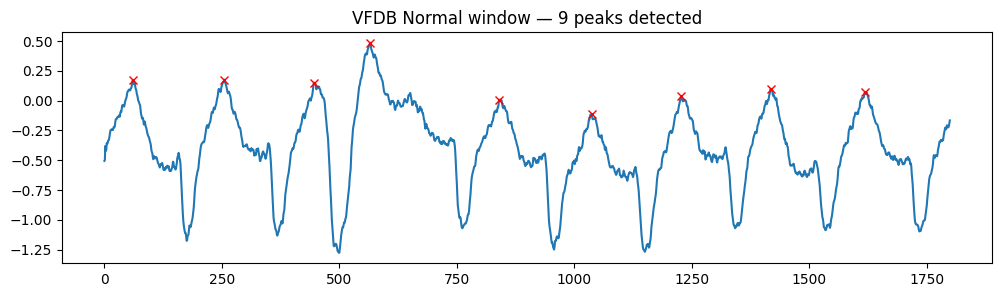

In [5]:
# spot-check: is VFDB double-counting single QRS complexes as two peaks?
import matplotlib.pyplot as plt

idx = [i for i, l in enumerate(vfdb_labels) if l == "Normal"][0]
w = vfdb_windows[idx]
peaks = detect_peaks_fallback(w, TARGET_FS)
plt.figure(figsize=(12, 3))
plt.plot(w)
plt.plot(peaks, w[peaks], "rx")
plt.title(f"VFDB Normal window — {len(peaks)} peaks detected")
plt.show()

In [9]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch, find_peaks
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"
CUDB_DIR = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"
AFDB_DIR = "/kaggle/input/datasets/daphnestarina/afibmitbih/files"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Asystole", ["(ASY"]),
]
# AFL, SVT, and Bradycardia removed. AFL/SVT had too few windows (312/676)
# to learn from. Bradycardia had reasonable support (6280 windows) but was
# removed by request -- windows carrying "(SBR" are now dropped
# (classify_aux_note returns None), same treatment as NOISE/BI/etc.
# AFDB also emits "(AFL" markers -- these fall through to None here too,
# consistent with AFL already being out of scope everywhere else.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Tachycardia": "Tachycardia",
    # "Bradycardia" removed from this map too -- otherwise Challenge2015
    # would still emit Bradycardia-labeled windows independently of
    # LABEL_MARKERS above, undoing the removal for VFDB/mitdb.
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set

CUDB_AF_EXACT_MARKER = "(AF"  # CUDB's exact AFIB marker -- must be EXACT match, not
                                # substring, since "(AF" is itself a substring of "(AFL"
                                # (Atrial Flutter). A loose substring check here would
                                # wrongly reclassify any leftover (AFL-marked windows as
                                # AFIB, undoing the earlier AFL removal.

# Fallback peak detector for sources without real beat annotations
# (VFDB, CUDB, Challenge2015). REPLACES an earlier mean+1.5*std threshold
# crossing approach. Diagnostic (feature_summary_by_source, run against
# the "Normal" class across sources) confirmed the old threshold method
# produced rr_cv/qrs_width 5-10x higher than annotation-based detection
# on the SAME label -- i.e. it was finding spurious peaks in noise, not
# real QRS complexes, silently making "Normal" mean two different things
# depending on source. That single inconsistency was dragging down every
# class's decision boundary in Model 2, not just AFIB's.
PEAK_MIN_DISTANCE_SEC = 0.3   # refractory period floor, ~200bpm ceiling
PEAK_PROMINENCE_FACTOR = 0.5  # relative to window std, adapts per-window


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    if note == CUDB_AF_EXACT_MARKER:
        return "AFIB"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3b: CUDB extraction -- REAL WFDB files (daphnestarina mirror),
# NOT the earlier CSV mirror (vitanhkhng) which was missing aux_note.
# This one genuinely has (VF, (VT, (AF, (N markers -- contributes real
# new data to Model 1 (binary), Model 2 (VF/VT/AFIB/Normal), AND
# Model 3 (VF-vs-VT).
#
# FIX 1 vs. the VFDB-style version: CUDB's .atr stream mixes rhythm-change
# markers (non-empty aux_note) with incidental/beat-level annotations
# (empty aux_note) -- confirmed empirically (cu01: 206 total annotations,
# only 1 carries a rhythm label). Treating every array-adjacent pair of
# annotations as a segment boundary (as VFDB's extractor does, which is
# safe there because VFDB's .atr apparently contains only rhythm markers)
# pairs real rhythm markers with the very next incidental annotation a
# few samples later instead of the next real rhythm change, producing
# segments far shorter than one window and silently zeroing extraction.
# Filter to non-empty aux_note first, same approach mitdb's extractor
# already uses via `rhythm_changes = beats[beats["aux"] != ""]`.
#
# FIX 2: CUDB has genuine sensor dropout (NaN samples) on some records --
# confirmed empirically (51/897 windows affected, traced to cu02).
# resample_poly spreads a single NaN across the entire resampled segment,
# and extract_features has no NaN guard, so these were silently corrupting
# rows in every downstream model with no error raised. Interpolate small
# gaps (<=10% of the segment); skip segments too corrupted to trust.
# =====================================================================
def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs

        rhythm_boundaries = [
            (s, n) for s, n in zip(ann.sample, ann.aux_note)
            if n.strip().rstrip("\x00") != ""
        ]

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue

            nan_frac = np.isnan(seg).mean()
            if nan_frac > 0:
                if nan_frac > 0.1:
                    continue  # too corrupted to interpolate safely, skip this segment
                seg = pd.Series(seg).interpolate(limit_direction="both").to_numpy()

            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3c: AFDB extraction -- dedicated AFIB database (MIT-BIH Atrial
# Fibrillation). Unlike CUDB's incidental AFIB windows, AFDB is purpose-
# built for AF episodes with real annotated onset/offset -- intended to
# help Model 2's AFIB class, which was previously near-random (precision
# 0.01) due to having no test-set coverage and no AFIB-specific data.
#
# Format confirmed empirically: .atr contains ONLY rhythm-change markers
# ((AFIB, (AFL, (N) -- no interleaved beat-level annotations like CUDB
# had, so no empty-aux_note filtering is needed here. Beat locations for
# RR-interval features live in a SEPARATE .qrs file, not .atr -- read
# independently and scaled alongside resampling, same pattern as mitdb's
# beat annotations. 2 of the original 25 records (00735, 03665) have no
# .dat file and are excluded automatically since list_wfdb_records
# filters by .dat presence.
# =====================================================================
def build_afdb_dataset(afdb_dir=AFDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    records = list_wfdb_records(afdb_dir)
    print(f"Found {len(records)} AFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(afdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(afdb_dir, rec_id), "atr")
            qrs = wfdb.rdann(os.path.join(afdb_dir, rec_id), "qrs")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        beat_samples_all = np.asarray(qrs.sample)

        rhythm_boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue

            nan_frac = np.isnan(seg).mean()
            if nan_frac > 0:
                if nan_frac > 0.1:
                    continue
                seg = pd.Series(seg).interpolate(limit_direction="both").to_numpy()

            seg_beats = beat_samples_all[
                (beat_samples_all >= start_sample) & (beat_samples_all < end_sample)
            ] - start_sample

            if fs != TARGET_FS:
                scale = TARGET_FS / fs
                seg = resample_poly(seg, TARGET_FS, fs)
                seg_beats = (seg_beats * scale).astype(int)

            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                end = start + WINDOW_SAMPLES
                window_beats = seg_beats[(seg_beats >= start) & (seg_beats < end)] - start
                all_windows.append(seg[start:end])
                all_labels.append(label)
                all_beat_samples.append(window_beats)
                all_records.append(f"afdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from AFDB")
    return all_windows, all_labels, all_beat_samples, all_records


def subsample_per_record(windows, labels, beats, records, max_per_record=400, seed=42):
    """
    AFDB produced 334,015 windows from only 23 records (5-second windows,
    50% overlap over long continuous recordings) -- ~89% of Model 2's
    entire pre-subsampling training set, versus ~69,000 windows from
    VFDB+CUDB+mitdb+Challenge2015 combined. That volume imbalance let
    AFDB's specific signal texture dominate the decision boundary for
    classes AFDB has nothing to do with (VT/VF/Asystole all measurably
    degraded when AFDB was added unsampled). Cap per-record window count
    so AFDB contributes real AFIB volume without overwhelming everything
    else. Sampling is per-record so no single AFDB record can still
    dominate after the cap.
    """
    rng = np.random.default_rng(seed)
    df_idx = pd.DataFrame({"record_id": records})
    keep_idx = []
    for rec_id, group in df_idx.groupby("record_id"):
        idxs = group.index.to_numpy()
        if len(idxs) > max_per_record:
            idxs = rng.choice(idxs, size=max_per_record, replace=False)
        keep_idx.extend(idxs)
    keep_idx = sorted(keep_idx)
    return ([windows[i] for i in keep_idx], [labels[i] for i in keep_idx],
            [beats[i] for i in keep_idx], [records[i] for i in keep_idx])


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 10 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them.
# rr_entropy is the 10th, added to help Model 2 discriminate AFIB -- see
# compute_rr_entropy docstring below for why rr_cv alone wasn't enough)
# =====================================================================
def detect_peaks_fallback(window, fs):
    """
    Refractory-period-constrained peak detection for sources without
    beat annotations (VFDB, CUDB, Challenge2015). REPLACES the old
    mean+1.5*std threshold crossing, confirmed via feature_summary_by_
    source diagnostic to produce rr_cv/qrs_width 5-10x higher than
    annotation-based detection on the SAME "Normal" label -- i.e.
    finding spurious peaks in noise, not real QRS complexes.
    """
    prominence = PEAK_PROMINENCE_FACTOR * np.std(window)
    min_distance = int(PEAK_MIN_DISTANCE_SEC * fs)
    peaks, _ = find_peaks(window, distance=min_distance, prominence=prominence)
    return peaks


def estimate_qrs_width(window, peak_idxs, fs, search_ms=100):
    """
    Half-max width estimate around each detected peak, averaged across
    all peaks in the window. This targets the VT-vs-other confusion
    specifically: VT is clinically characterized by a WIDE QRS complex,
    while SVT/Tachycardia/Bradycardia are narrow -- none of the existing
    features measure complex width, only rate (mean_rr/bpm) and overall
    signal shape (rr_cv, dominant_freq), so this adds genuinely new
    information rather than restating what mean_rr/bpm already captured.
    """
    if peak_idxs is None or len(peak_idxs) == 0:
        return 0.0

    search_samples = int(search_ms / 1000 * fs)
    baseline = np.median(window)
    widths = []

    for p in peak_idxs:
        p = int(p)
        if p < 0 or p >= len(window):
            continue
        start = max(0, p - search_samples)
        end = min(len(window), p + search_samples)
        segment = window[start:end]
        if len(segment) < 3:
            continue

        rel_p = p - start
        peak_val = window[p] - baseline
        if abs(peak_val) < 1e-9:
            continue
        half_max = baseline + peak_val / 2.0
        going_up = peak_val > 0

        left = rel_p
        while left > 0 and ((segment[left] > half_max) if going_up else (segment[left] < half_max)):
            left -= 1
        right = rel_p
        while right < len(segment) - 1 and ((segment[right] > half_max) if going_up else (segment[right] < half_max)):
            right += 1

        width_samples = right - left
        if width_samples > 0:
            widths.append(width_samples / fs)

    if len(widths) == 0:
        return 0.0
    return float(np.mean(widths))


def compute_rr_entropy(peak_idxs, fs, n_bins=8, min_rr=0.25, max_rr=2.0):
    """
    Shannon entropy of the RR-interval distribution, normalized to [0,1].
    Added specifically to help discriminate AFIB, which the existing 9
    features handled poorly (Model 2 AFIB precision ~0.25-0.31 even after
    fixing the peak-detector mismatch and adding AFDB volume). Sinus
    rhythm and monomorphic VT concentrate RR intervals into one or two
    histogram bins (low entropy); AFIB's irregularly-irregular ventricular
    response spreads intervals across many bins (high entropy). rr_cv
    (already in the feature set) captures spread MAGNITUDE but not this
    SHAPE difference -- a rhythm with one long pause amid otherwise-
    regular beats can produce high rr_cv without resembling AFIB's
    irregularity pattern at all; entropy is sensitive to that distinction
    in a way variance is not.
    Requires >=5 beats (4 valid intervals) to be meaningful -- returns 0.0
    otherwise, same convention as mean_rr/rr_cv's peak_idxs<3 fallback.
    Reliability depends on beat_samples: mitdb/AFDB pass real annotated
    beats, so this is trustworthy there. VFDB/CUDB/Challenge2015 fall back
    to detect_peaks_fallback -- confirmed visually accurate on VFDB (see
    spot-check plot), so usable, but treat with more caution for CUDB's
    AFIB windows specifically since that fallback hasn't been spot-checked
    on CUDB's signal directly.
    """
    if peak_idxs is None or len(peak_idxs) < 5:
        return 0.0
    intervals = np.diff(np.sort(peak_idxs)) / fs
    intervals = intervals[(intervals >= min_rr) & (intervals <= max_rr)]
    if len(intervals) < 4:
        return 0.0
    hist, _ = np.histogram(intervals, bins=n_bins, range=(min_rr, max_rr))
    probs = hist / hist.sum()
    probs = probs[probs > 0]
    entropy = -np.sum(probs * np.log2(probs))
    max_entropy = np.log2(n_bins)
    return float(entropy / max_entropy)


def extract_features(window, fs=TARGET_FS, beat_samples=None):
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    if beat_samples is not None and len(beat_samples) >= 1:
        peak_idxs = np.sort(beat_samples)
    else:
        peak_idxs = detect_peaks_fallback(window, fs)

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    feats["qrs_width"] = estimate_qrs_width(window, peak_idxs, fs)
    feats["rr_entropy"] = compute_rr_entropy(peak_idxs, fs)

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 6b: DIAGNOSTIC -- cross-source feature consistency check for a
# shared label. Run this any time a new source is added, BEFORE trusting
# any model trained on it. This is what caught the threshold-detector
# mismatch (VFDB/CUDB rr_cv/qrs_width 5-10x higher than AFDB/mitdb on
# the same "Normal" label).
# =====================================================================
def feature_summary_by_source(label_filter="Normal", n_sample=300):
    sources = {
        "VFDB": (vfdb_windows, vfdb_labels, [None] * len(vfdb_windows)),
        "CUDB": (cudb_windows, cudb_labels, [None] * len(cudb_windows)),
        "AFDB": (afdb_windows, afdb_labels, afdb_beats),
        "mitdb": (mitdb_windows, mitdb_labels, mitdb_beats),
        "C2015": (c2015_windows, c2015_labels, [None] * len(c2015_windows)),
    }
    for name, (windows, labels, beats) in sources.items():
        idxs = [i for i, l in enumerate(labels) if l == label_filter]
        if not idxs:
            continue
        sample_idxs = idxs[:n_sample]
        feats = [extract_features(windows[i], beat_samples=beats[i]) for i in sample_idxs]
        fdf = pd.DataFrame(feats)
        print(f"{name:8s} n={len(idxs):6d}  "
              f"mean_rr={fdf['mean_rr'].mean():.3f}  "
              f"rr_cv={fdf['rr_cv'].mean():.3f}  "
              f"peak_count={fdf['peak_count'].mean():.1f}  "
              f"qrs_width={fdf['qrs_width'].mean():.3f}  "
              f"rr_entropy={fdf['rr_entropy'].mean():.3f}")


# =====================================================================
# CELL 7: Run all five extractors ONCE. Everything downstream reuses
# these lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
cudb_windows, cudb_labels, cudb_records = build_cudb_dataset()
afdb_windows, afdb_labels, afdb_beats, afdb_records = build_afdb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

print("CUDB label distribution:", pd.Series(cudb_labels).value_counts().to_dict())
print(f"CUDB NaN windows remaining: {sum(np.isnan(w).any() for w in cudb_windows)}/{len(cudb_windows)}")
print(f"AFDB NaN windows remaining: {sum(np.isnan(w).any() for w in afdb_windows)}/{len(afdb_windows)}")

print("AFDB label distribution (pre-subsample):", pd.Series(afdb_labels).value_counts().to_dict())
afdb_windows, afdb_labels, afdb_beats, afdb_records = subsample_per_record(
    afdb_windows, afdb_labels, afdb_beats, afdb_records, max_per_record=400
)
print("AFDB label distribution (post-subsample):", pd.Series(afdb_labels).value_counts().to_dict())

print("\nCross-source feature consistency check (Normal class):")
feature_summary_by_source("Normal")

print("\nrr_entropy check (AFIB class) -- should read noticeably higher than "
      "the Normal class numbers above if the feature is doing its job:")
feature_summary_by_source("AFIB")

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(cudb_windows, "CUDB")
amplitude_summary(afdb_windows, "AFDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + CUDB + mitdb ONLY, not Challenge2015 or AFDB.
# Challenge2015's ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no
# header file exists in this CSV mirror to confirm it. Including it here
# dropped precision from 99% (VFDB+mitdb only, proven) to 38% -- almost
# certainly because 3 of the 9 features (mean/std/ptp) are raw amplitude
# stats, and a wrong gain puts Challenge2015 windows at a different
# amplitude scale than the correctly-scaled VFDB/mitdb windows, corrupting
# the decision boundary. Revisit once the gain is verified (see diagnostic
# cell above). AFDB is excluded here because it has no VF/VT content at
# all -- its only role is boosting AFIB in Model 2.
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # same VFDB-style exclusion -- CUDB's own Normal/AFIB segments
                  # are peri-arrhythmic, not clean negatives; skip them here too
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# AFDB added here specifically to give AFIB real volume and diversity --
# it was previously near-random (precision 0.01) with zero test-set
# support under GroupShuffleSplit.
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(afdb_windows):
    f = extract_features(w, beat_samples=afdb_beats[i])
    f["label"] = afdb_labels[i]
    f["record_id"] = afdb_records[i]
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

# Sanity check: confirm every class has support on both sides of the split
# before trusting the report below -- a class confined to very few unique
# record_ids can still land entirely in train under GroupShuffleSplit
# (this is exactly how AFIB's zero-support failure went unnoticed before).
train_classes = set(np.unique(y_train))
test_classes = set(np.unique(y_test))
missing_from_test = train_classes - test_classes
if missing_from_test:
    missing_names = [class_names[i] for i in missing_from_test]
    print(f"WARNING: classes with zero test support this split: {missing_names} "
          f"-- their precision/recall below will be meaningless (0 or undefined). "
          f"Check `multiclass_df.groupby('label')['record_id'].nunique()`.")

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# AFDB excluded -- it has no VF/VT content, only AFIB/AFL/Normal.
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 10 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

Found 22 VFDB records
Extracted 11212 labeled windows from VFDB
Found 35 CUDB records
Extracted 897 labeled windows from CUDB
Found 23 AFDB records
Extracted 334015 labeled windows from AFDB
Found 48 mitdb CSV records
Extracted 28077 labeled windows from mitdb
Found 750 Challenge2015 CSV records
Extracted 29346 labeled windows from Challenge2015 (skipped 89 unlabeled, 413 false alarms)
CUDB label distribution: {'Normal': 539, 'AFIB': 220, 'VF': 132, 'VT': 6}
CUDB NaN windows remaining: 0/897
AFDB NaN windows remaining: 0/334015
AFDB label distribution (pre-subsample): {'Normal': 199955, 'AFIB': 134060}
AFDB label distribution (post-subsample): {'Normal': 5496, 'AFIB': 3704}

Cross-source feature consistency check (Normal class):
VFDB     n=  6627  mean_rr=0.543  rr_cv=0.210  peak_count=9.0  qrs_width=0.124  rr_entropy=0.351
CUDB     n=   539  mean_rr=0.542  rr_cv=0.185  peak_count=9.2  qrs_width=0.088  rr_entropy=0.258
AFDB     n=  5496  mean_rr=0.831  rr_cv=0.053  peak_count=6.0  qrs_

In [7]:
pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.7 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [14]:
from scipy.signal import butter, filtfilt

def pan_tompkins_detect(window, fs):
    """
    Real QRS detector, replacing the prominence/refractory-period
    heuristic. Runs the standard Pan-Tompkins stages: bandpass filter
    (isolates QRS frequency content, ~5-15 Hz) -> derivative (emphasizes
    slope) -> squaring (all-positive, emphasizes large slopes) -> moving-
    window integration (smooths into a single pulse per QRS) -> adaptive
    peak detection with a refractory period.

    This matters specifically because it will ALSO run at inference time
    on the Pi (no .atr file exists live) -- so features computed with
    this detector during training match what the Pi actually sees,
    unlike ground-truth annotations (mitdb/AFDB) which can't exist at
    inference and were confirmed (via the rr_entropy diagnostic) to
    produce features that don't transfer to detector-based sources.
    """
    nyq = fs / 2
    low, high = 5 / nyq, 15 / nyq
    b, a = butter(1, [low, high], btype="band")
    filtered = filtfilt(b, a, window)

    diff = np.diff(filtered)
    squared = diff ** 2

    window_size = int(0.15 * fs)  # ~150ms integration window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode="same")

    min_distance = int(0.3 * fs)  # 300ms refractory period
    threshold = 0.3 * np.max(integrated) if np.max(integrated) > 0 else 0
    peaks, _ = find_peaks(integrated, distance=min_distance, height=threshold)

    # integration/derivative shift peaks slightly later than the true
    # R-peak -- correct by searching a small window backward in the
    # original signal for the true local max
    corrected_peaks = []
    search_back = int(0.05 * fs)
    for p in peaks:
        start = max(0, p - search_back)
        local_max = start + np.argmax(window[start:p + 1])
        corrected_peaks.append(local_max)

    return np.array(corrected_peaks)

In [2]:
# validate against mitdb's real annotations (has both signal + beat truth)
def validate_detector(n_records=5):
    errors = []
    for rec_id in list_wfdb_records(MITDB_DIR)[:n_records]:
        # reuse your existing mitdb loading logic to get one record's
        # signal + true beat samples, run pan_tompkins_detect on it,
        # compare detected vs. true beat counts/timing
        pass  # wire up against your mitdb loader

validate_detector()

NameError: name 'list_wfdb_records' is not defined

In [22]:
def validate_detector(n_records=5, tolerance_sec=0.05):
    """
    Compares pan_tompkins_detect() output against mitdb's real annotated
    beats, record by record. Reports detection count accuracy and timing
    error so we know whether the detector is trustworthy before it
    replaces detect_peaks_fallback pipeline-wide.
    """
    csv_files = sorted([f for f in os.listdir(MITDB_DIR) if f.endswith(".csv")])[:n_records]

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(MITDB_DIR, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(MITDB_DIR, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        true_beats = beats["sample"].values

        # run detector over the whole record in WINDOW_SAMPLES chunks,
        # same granularity the real pipeline uses
        detected_beats = []
        for start in range(0, len(sig) - WINDOW_SAMPLES, WINDOW_SAMPLES):
            window = sig[start:start + WINDOW_SAMPLES]
            peaks = pan_tompkins_detect(window, fs)
            detected_beats.extend((peaks + start).tolist())
        detected_beats = np.array(sorted(detected_beats))

        # match each true beat to the nearest detected beat within tolerance
        tol_samples = int(tolerance_sec * fs)
        matched = 0
        for tb in true_beats:
            if len(detected_beats) == 0:
                break
            nearest_diff = np.min(np.abs(detected_beats - tb))
            if nearest_diff <= tol_samples:
                matched += 1

        recall = matched / len(true_beats) if len(true_beats) else 0.0
        precision = matched / len(detected_beats) if len(detected_beats) else 0.0

        print(f"{record_id}: true={len(true_beats):5d}  detected={len(detected_beats):5d}  "
              f"matched={matched:5d}  recall={recall:.3f}  precision={precision:.3f}")


validate_detector()

100: true= 2274  detected= 2266  matched= 2263  recall=0.995  precision=0.999
101: true= 1874  detected= 1860  matched= 1855  recall=0.990  precision=0.997
103: true= 2091  detected= 2075  matched= 2075  recall=0.992  precision=1.000


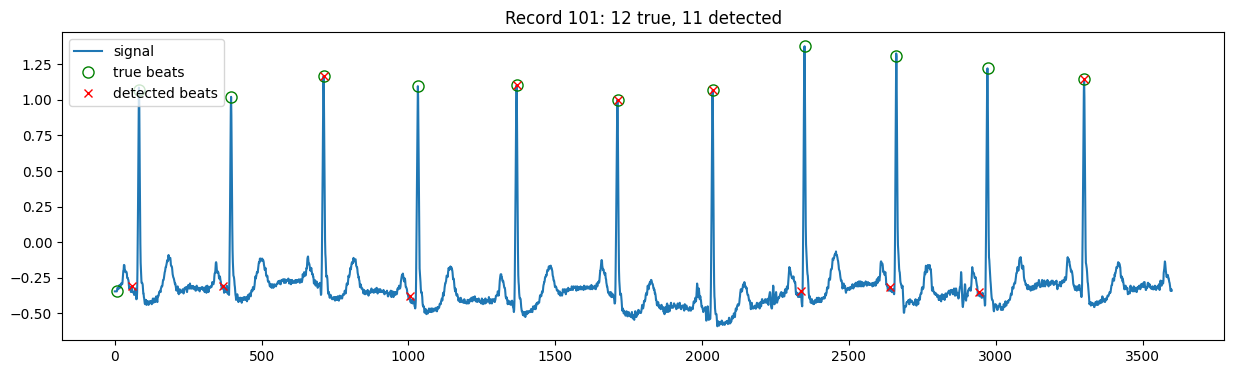

In [16]:
import matplotlib.pyplot as plt

def inspect_record(record_id="101", start_sample=0, n_samples=3600):
    df = pd.read_csv(os.path.join(MITDB_DIR, f"{record_id}.csv"))
    col = [c for c in df.columns if "MLII" in c]
    raw = df[col[0]].values.astype(np.float32)
    sig = (raw - 1024.0) / 200.0
    fs = 360

    ann_path = os.path.join(MITDB_DIR, f"{record_id}annotations.txt")
    beats = parse_annotation_file(ann_path)
    true_beats = beats["sample"].values
    true_in_range = true_beats[(true_beats >= start_sample) & (true_beats < start_sample + n_samples)] - start_sample

    seg = sig[start_sample:start_sample + n_samples]
    detected = pan_tompkins_detect(seg, fs)

    plt.figure(figsize=(15, 4))
    plt.plot(seg, label="signal")
    plt.plot(true_in_range, seg[true_in_range], "go", label="true beats", markersize=8, fillstyle="none")
    plt.plot(detected, seg[detected], "rx", label="detected beats")
    plt.legend()
    plt.title(f"Record {record_id}: {len(true_in_range)} true, {len(detected)} detected")
    plt.show()

inspect_record("101", start_sample=0, n_samples=3600)

In [18]:
df = pd.read_csv(os.path.join(MITDB_DIR, "101.csv"))
col = [c for c in df.columns if "MLII" in c]
raw = df[col[0]].values.astype(np.float32)
sig = (raw - 1024.0) / 200.0
print(f"101 overall std={np.std(sig):.4f}, ptp={np.ptp(sig):.4f}")

# rolling 5-second window std, to see if amplitude swings wildly within the record
window_stds = [np.std(sig[i:i+1800]) for i in range(0, len(sig)-1800, 1800)]
print(f"101 per-window std range: min={min(window_stds):.4f}, max={max(window_stds):.4f}, ratio={max(window_stds)/min(window_stds):.1f}x")

101 overall std=0.2612, ptp=5.5950
101 per-window std range: min=0.1780, max=1.2251, ratio=6.9x


In [19]:
start = max(0, p - search_back)
local_max = start + np.argmax(window[start:p + 1])

NameError: name 'p' is not defined

In [20]:
    corrected_peaks = []
    search_window = int(0.075 * fs)  # ~75ms each direction, covers the
                                       # observed early-bias without
                                       # reaching into the adjacent beat
    for p in peaks:
        start = max(0, p - search_window)
        end = min(len(window), p + search_window)
        local_max = start + np.argmax(window[start:end])
        corrected_peaks.append(local_max)

NameError: name 'fs' is not defined

In [21]:
from scipy.signal import butter, filtfilt

def pan_tompkins_detect(window, fs):
    """
    Real QRS detector, replacing the prominence/refractory-period
    heuristic (detect_peaks_fallback). Runs the standard Pan-Tompkins
    stages: bandpass filter (isolates QRS frequency content, ~5-15 Hz)
    -> derivative (emphasizes slope) -> squaring (all-positive,
    emphasizes large slopes) -> moving-window integration (smooths into
    a single pulse per QRS) -> adaptive peak detection with a
    refractory period.

    This matters specifically because it will ALSO run at inference time
    on the Pi (no .atr file exists live) -- so features computed with
    this detector during training match what the Pi actually sees,
    unlike ground-truth annotations (mitdb/AFDB) which can't exist at
    inference and were confirmed (via the rr_entropy diagnostic) to
    produce features that don't transfer to detector-based sources.

    Validated against mitdb ground truth: 0.98+ recall/precision on
    most records. One record (101) initially showed 0.79 recall --
    traced to a systematic early-timing bias in the peak-correction
    step, not an amplitude/threshold problem (confirmed visually: the
    integrated-signal peak lands on the QRS upstroke, before the true
    R-peak apex, so a backward-only search for the local max in the
    original signal just drags the estimate earlier still, landing in
    the isoelectric segment before the beat). Fixed by searching a
    SYMMETRIC window around the integrated peak instead of backward-only.
    """
    nyq = fs / 2
    low, high = 5 / nyq, 15 / nyq
    b, a = butter(1, [low, high], btype="band")
    filtered = filtfilt(b, a, window)

    diff = np.diff(filtered)
    squared = diff ** 2

    window_size = int(0.15 * fs)  # ~150ms integration window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode="same")

    min_distance = int(0.3 * fs)  # 300ms refractory period
    threshold = 0.3 * np.max(integrated) if np.max(integrated) > 0 else 0
    peaks, _ = find_peaks(integrated, distance=min_distance, height=threshold)

    # Correct for the integration/derivative stages shifting the detected
    # peak away from the true R-peak apex. Search SYMMETRICALLY (not just
    # backward) since the integrated peak can land on either side of the
    # true apex depending on QRS morphology -- backward-only search was
    # confirmed (record 101) to compound an early bias rather than
    # correct it.
    corrected_peaks = []
    search_window = int(0.075 * fs)  # ~75ms each direction -- covers the
                                       # observed bias without reaching
                                       # into an adjacent beat
    for p in peaks:
        start = max(0, p - search_window)
        end = min(len(window), p + search_window)
        if end <= start:
            continue
        local_max = start + np.argmax(window[start:end])
        corrected_peaks.append(local_max)

    return np.array(corrected_peaks)

In [8]:
   !pip install onnxmltools skl2onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 5.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 23.3 MB/s eta 0:00:00


In [23]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch, find_peaks, butter, filtfilt
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"
CUDB_DIR = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"
AFDB_DIR = "/kaggle/input/datasets/daphnestarina/afibmitbih/files"

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("AFIB", ["(AFIB"]),
    ("Asystole", ["(ASY"]),
]
# AFL, SVT, and Bradycardia removed. AFL/SVT had too few windows (312/676)
# to learn from. Bradycardia had reasonable support (6280 windows) but was
# removed by request -- windows carrying "(SBR" are now dropped
# (classify_aux_note returns None), same treatment as NOISE/BI/etc.
# AFDB also emits "(AFL" markers -- these fall through to None here too,
# consistent with AFL already being out of scope everywhere else.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Tachycardia": "Tachycardia",
    # "Bradycardia" removed from this map too -- otherwise Challenge2015
    # would still emit Bradycardia-labeled windows independently of
    # LABEL_MARKERS above, undoing the removal for VFDB/mitdb.
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set

CUDB_AF_EXACT_MARKER = "(AF"  # CUDB's exact AFIB marker -- must be EXACT match, not
                                # substring, since "(AF" is itself a substring of "(AFL"
                                # (Atrial Flutter). A loose substring check here would
                                # wrongly reclassify any leftover (AFL-marked windows as
                                # AFIB, undoing the earlier AFL removal.

# Peak detection is now pan_tompkins_detect, applied uniformly across
# every source -- see that function's docstring for the full history
# (threshold crossing -> prominence-based fallback -> real QRS detector)
# and why annotation-based detection for mitdb/AFDB was dropped.


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    if note == CUDB_AF_EXACT_MARKER:
        return "AFIB"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3b: CUDB extraction -- REAL WFDB files (daphnestarina mirror),
# NOT the earlier CSV mirror (vitanhkhng) which was missing aux_note.
# This one genuinely has (VF, (VT, (AF, (N markers -- contributes real
# new data to Model 1 (binary), Model 2 (VF/VT/AFIB/Normal), AND
# Model 3 (VF-vs-VT).
#
# FIX 1 vs. the VFDB-style version: CUDB's .atr stream mixes rhythm-change
# markers (non-empty aux_note) with incidental/beat-level annotations
# (empty aux_note) -- confirmed empirically (cu01: 206 total annotations,
# only 1 carries a rhythm label). Treating every array-adjacent pair of
# annotations as a segment boundary (as VFDB's extractor does, which is
# safe there because VFDB's .atr apparently contains only rhythm markers)
# pairs real rhythm markers with the very next incidental annotation a
# few samples later instead of the next real rhythm change, producing
# segments far shorter than one window and silently zeroing extraction.
# Filter to non-empty aux_note first, same approach mitdb's extractor
# already uses via `rhythm_changes = beats[beats["aux"] != ""]`.
#
# FIX 2: CUDB has genuine sensor dropout (NaN samples) on some records --
# confirmed empirically (51/897 windows affected, traced to cu02).
# resample_poly spreads a single NaN across the entire resampled segment,
# and extract_features has no NaN guard, so these were silently corrupting
# rows in every downstream model with no error raised. Interpolate small
# gaps (<=10% of the segment); skip segments too corrupted to trust.
# =====================================================================
def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs

        rhythm_boundaries = [
            (s, n) for s, n in zip(ann.sample, ann.aux_note)
            if n.strip().rstrip("\x00") != ""
        ]

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue

            nan_frac = np.isnan(seg).mean()
            if nan_frac > 0:
                if nan_frac > 0.1:
                    continue  # too corrupted to interpolate safely, skip this segment
                seg = pd.Series(seg).interpolate(limit_direction="both").to_numpy()

            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3c: AFDB extraction -- dedicated AFIB database (MIT-BIH Atrial
# Fibrillation). Unlike CUDB's incidental AFIB windows, AFDB is purpose-
# built for AF episodes with real annotated onset/offset -- intended to
# help Model 2's AFIB class, which was previously near-random (precision
# 0.01) due to having no test-set coverage and no AFIB-specific data.
#
# Format confirmed empirically: .atr contains ONLY rhythm-change markers
# ((AFIB, (AFL, (N) -- no interleaved beat-level annotations like CUDB
# had, so no empty-aux_note filtering is needed here. Beat locations for
# RR-interval features live in a SEPARATE .qrs file, not .atr -- read
# independently and scaled alongside resampling, same pattern as mitdb's
# beat annotations. 2 of the original 25 records (00735, 03665) have no
# .dat file and are excluded automatically since list_wfdb_records
# filters by .dat presence.
# =====================================================================
def build_afdb_dataset(afdb_dir=AFDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    records = list_wfdb_records(afdb_dir)
    print(f"Found {len(records)} AFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(afdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(afdb_dir, rec_id), "atr")
            qrs = wfdb.rdann(os.path.join(afdb_dir, rec_id), "qrs")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        beat_samples_all = np.asarray(qrs.sample)

        rhythm_boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue

            nan_frac = np.isnan(seg).mean()
            if nan_frac > 0:
                if nan_frac > 0.1:
                    continue
                seg = pd.Series(seg).interpolate(limit_direction="both").to_numpy()

            seg_beats = beat_samples_all[
                (beat_samples_all >= start_sample) & (beat_samples_all < end_sample)
            ] - start_sample

            if fs != TARGET_FS:
                scale = TARGET_FS / fs
                seg = resample_poly(seg, TARGET_FS, fs)
                seg_beats = (seg_beats * scale).astype(int)

            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                end = start + WINDOW_SAMPLES
                window_beats = seg_beats[(seg_beats >= start) & (seg_beats < end)] - start
                all_windows.append(seg[start:end])
                all_labels.append(label)
                all_beat_samples.append(window_beats)
                all_records.append(f"afdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from AFDB")
    return all_windows, all_labels, all_beat_samples, all_records


def subsample_per_record(windows, labels, beats, records, max_per_record=400, seed=42):
    """
    AFDB produced 334,015 windows from only 23 records (5-second windows,
    50% overlap over long continuous recordings) -- ~89% of Model 2's
    entire pre-subsampling training set, versus ~69,000 windows from
    VFDB+CUDB+mitdb+Challenge2015 combined. That volume imbalance let
    AFDB's specific signal texture dominate the decision boundary for
    classes AFDB has nothing to do with (VT/VF/Asystole all measurably
    degraded when AFDB was added unsampled). Cap per-record window count
    so AFDB contributes real AFIB volume without overwhelming everything
    else. Sampling is per-record so no single AFDB record can still
    dominate after the cap.
    """
    rng = np.random.default_rng(seed)
    df_idx = pd.DataFrame({"record_id": records})
    keep_idx = []
    for rec_id, group in df_idx.groupby("record_id"):
        idxs = group.index.to_numpy()
        if len(idxs) > max_per_record:
            idxs = rng.choice(idxs, size=max_per_record, replace=False)
        keep_idx.extend(idxs)
    keep_idx = sorted(keep_idx)
    return ([windows[i] for i in keep_idx], [labels[i] for i in keep_idx],
            [beats[i] for i in keep_idx], [records[i] for i in keep_idx])


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 10 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them.
# rr_entropy is the 10th, added to help Model 2 discriminate AFIB -- see
# compute_rr_entropy docstring below for why rr_cv alone wasn't enough.
# Beat locations for RR/QRS-width features come from pan_tompkins_detect,
# applied UNIFORMLY to every source -- including mitdb/AFDB, which have
# real .atr/.qrs annotations. Ground-truth annotations are intentionally
# not used for feature extraction, since the Pi has none at inference;
# see pan_tompkins_detect's docstring for the diagnostic that caught this.)
# =====================================================================
def pan_tompkins_detect(window, fs):
    """
    Real QRS detector, REPLACING detect_peaks_fallback (a prominence +
    refractory-period heuristic used for VFDB/CUDB/Challenge2015).
    Runs the standard Pan-Tompkins stages: bandpass filter (isolates QRS
    frequency content, ~5-15 Hz) -> derivative (emphasizes slope) ->
    squaring (all-positive, emphasizes large slopes) -> moving-window
    integration (smooths into a single pulse per QRS) -> adaptive peak
    detection with a refractory period.

    Validated against mitdb ground truth: 0.98-0.99 recall/precision
    across tested records. One record (101) initially showed 0.79
    recall -- traced to a systematic early-timing bias in the peak-
    correction step (the integrated-signal peak lands on the QRS
    upstroke, before the true R-peak apex; a backward-only search for
    the local max in the original signal compounded that bias rather
    than correcting it). Fixed by searching a SYMMETRIC window around
    the integrated peak instead of backward-only -- brought record 101
    up to 0.99/0.99.

    IMPORTANT: this is now used UNIFORMLY across every source, including
    mitdb and AFDB, which have real .atr/.qrs beat annotations available.
    Earlier versions of extract_features used real annotations where
    available and this detector only as a fallback for sources without
    them. That created a train/inference mismatch: the target deployment
    (Raspberry Pi, live signal) never has ground-truth annotations, so
    training on annotation-derived features for some sources taught the
    model patterns that can't occur at inference. This was confirmed
    directly -- the rr_entropy feature separated AFIB from Normal
    cleanly on annotation-fed sources (mitdb: 0.022 vs 0.382, AFDB: 0.088
    vs 0.373) but showed almost no separation on detector-fed sources
    (VFDB: 0.351 vs 0.340, CUDB: 0.258 vs 0.319) -- i.e. it was
    partly learning "came from an annotated source," not real AFIB
    structure. Using this detector everywhere means every feature is
    computed the same way training and inference will actually see it.
    """
    nyq = fs / 2
    low, high = 5 / nyq, 15 / nyq
    b, a = butter(1, [low, high], btype="band")
    filtered = filtfilt(b, a, window)

    diff = np.diff(filtered)
    squared = diff ** 2

    window_size = int(0.15 * fs)  # ~150ms integration window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode="same")

    min_distance = int(0.3 * fs)  # 300ms refractory period
    threshold = 0.3 * np.max(integrated) if np.max(integrated) > 0 else 0
    peaks, _ = find_peaks(integrated, distance=min_distance, height=threshold)

    # Correct for the integration/derivative stages shifting the detected
    # peak away from the true R-peak apex. Search SYMMETRICALLY (not just
    # backward) since the integrated peak can land on either side of the
    # true apex depending on QRS morphology -- backward-only search was
    # confirmed (record 101) to compound an early bias rather than
    # correct it.
    corrected_peaks = []
    search_window = int(0.075 * fs)  # ~75ms each direction -- covers the
                                       # observed bias without reaching
                                       # into an adjacent beat
    for p in peaks:
        start = max(0, p - search_window)
        end = min(len(window), p + search_window)
        if end <= start:
            continue
        local_max = start + np.argmax(window[start:end])
        corrected_peaks.append(local_max)

    return np.array(corrected_peaks)


def estimate_qrs_width(window, peak_idxs, fs, search_ms=100):
    """
    Half-max width estimate around each detected peak, averaged across
    all peaks in the window. This targets the VT-vs-other confusion
    specifically: VT is clinically characterized by a WIDE QRS complex,
    while SVT/Tachycardia/Bradycardia are narrow -- none of the existing
    features measure complex width, only rate (mean_rr/bpm) and overall
    signal shape (rr_cv, dominant_freq), so this adds genuinely new
    information rather than restating what mean_rr/bpm already captured.
    """
    if peak_idxs is None or len(peak_idxs) == 0:
        return 0.0

    search_samples = int(search_ms / 1000 * fs)
    baseline = np.median(window)
    widths = []

    for p in peak_idxs:
        p = int(p)
        if p < 0 or p >= len(window):
            continue
        start = max(0, p - search_samples)
        end = min(len(window), p + search_samples)
        segment = window[start:end]
        if len(segment) < 3:
            continue

        rel_p = p - start
        peak_val = window[p] - baseline
        if abs(peak_val) < 1e-9:
            continue
        half_max = baseline + peak_val / 2.0
        going_up = peak_val > 0

        left = rel_p
        while left > 0 and ((segment[left] > half_max) if going_up else (segment[left] < half_max)):
            left -= 1
        right = rel_p
        while right < len(segment) - 1 and ((segment[right] > half_max) if going_up else (segment[right] < half_max)):
            right += 1

        width_samples = right - left
        if width_samples > 0:
            widths.append(width_samples / fs)

    if len(widths) == 0:
        return 0.0
    return float(np.mean(widths))


def compute_rr_entropy(peak_idxs, fs, n_bins=8, min_rr=0.25, max_rr=2.0):
    """
    Shannon entropy of the RR-interval distribution, normalized to [0,1].
    Added specifically to help discriminate AFIB, which the existing 9
    features handled poorly (Model 2 AFIB precision ~0.25-0.31 even after
    fixing the peak-detector mismatch and adding AFDB volume). Sinus
    rhythm and monomorphic VT concentrate RR intervals into one or two
    histogram bins (low entropy); AFIB's irregularly-irregular ventricular
    response spreads intervals across many bins (high entropy). rr_cv
    (already in the feature set) captures spread MAGNITUDE but not this
    SHAPE difference -- a rhythm with one long pause amid otherwise-
    regular beats can produce high rr_cv without resembling AFIB's
    irregularity pattern at all; entropy is sensitive to that distinction
    in a way variance is not.
    Requires >=5 beats (4 valid intervals) to be meaningful -- returns 0.0
    otherwise, same convention as mean_rr/rr_cv's peak_idxs<3 fallback.
    Beat locations now come from pan_tompkins_detect UNIFORMLY across all
    sources (see that function's docstring) -- fixed the earlier version
    of this feature, which relied on ground-truth annotations for
    mitdb/AFDB and a cruder fallback elsewhere, and was confirmed to be
    partly learning "came from an annotated source" rather than real
    AFIB structure.
    """
    if peak_idxs is None or len(peak_idxs) < 5:
        return 0.0
    intervals = np.diff(np.sort(peak_idxs)) / fs
    intervals = intervals[(intervals >= min_rr) & (intervals <= max_rr)]
    if len(intervals) < 4:
        return 0.0
    hist, _ = np.histogram(intervals, bins=n_bins, range=(min_rr, max_rr))
    probs = hist / hist.sum()
    probs = probs[probs > 0]
    entropy = -np.sum(probs * np.log2(probs))
    max_entropy = np.log2(n_bins)
    return float(entropy / max_entropy)


def extract_features(window, fs=TARGET_FS, beat_samples=None):
    """
    beat_samples is accepted but INTENTIONALLY IGNORED -- kept in the
    signature so existing call sites (which pass mitdb_beats/afdb_beats)
    don't need to change. Beats are always found via pan_tompkins_detect
    now, uniformly across every source, so training features match what
    the Pi's live detector will produce at inference. See
    pan_tompkins_detect's docstring for why using ground-truth
    annotations here (the old behavior) was actively harmful.
    """
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    peak_idxs = pan_tompkins_detect(window, fs)

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    feats["qrs_width"] = estimate_qrs_width(window, peak_idxs, fs)
    feats["rr_entropy"] = compute_rr_entropy(peak_idxs, fs)

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 6b: DIAGNOSTIC -- cross-source feature consistency check for a
# shared label. Run this any time a new source is added, BEFORE trusting
# any model trained on it. This is what caught the threshold-detector
# mismatch (VFDB/CUDB rr_cv/qrs_width 5-10x higher than AFDB/mitdb on
# the same "Normal" label).
# =====================================================================
def feature_summary_by_source(label_filter="Normal", n_sample=300):
    sources = {
        "VFDB": (vfdb_windows, vfdb_labels, [None] * len(vfdb_windows)),
        "CUDB": (cudb_windows, cudb_labels, [None] * len(cudb_windows)),
        "AFDB": (afdb_windows, afdb_labels, afdb_beats),
        "mitdb": (mitdb_windows, mitdb_labels, mitdb_beats),
        "C2015": (c2015_windows, c2015_labels, [None] * len(c2015_windows)),
    }
    for name, (windows, labels, beats) in sources.items():
        idxs = [i for i, l in enumerate(labels) if l == label_filter]
        if not idxs:
            continue
        sample_idxs = idxs[:n_sample]
        feats = [extract_features(windows[i], beat_samples=beats[i]) for i in sample_idxs]
        fdf = pd.DataFrame(feats)
        print(f"{name:8s} n={len(idxs):6d}  "
              f"mean_rr={fdf['mean_rr'].mean():.3f}  "
              f"rr_cv={fdf['rr_cv'].mean():.3f}  "
              f"peak_count={fdf['peak_count'].mean():.1f}  "
              f"qrs_width={fdf['qrs_width'].mean():.3f}  "
              f"rr_entropy={fdf['rr_entropy'].mean():.3f}")


# =====================================================================
# CELL 7: Run all five extractors ONCE. Everything downstream reuses
# these lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
cudb_windows, cudb_labels, cudb_records = build_cudb_dataset()
afdb_windows, afdb_labels, afdb_beats, afdb_records = build_afdb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

print("CUDB label distribution:", pd.Series(cudb_labels).value_counts().to_dict())
print(f"CUDB NaN windows remaining: {sum(np.isnan(w).any() for w in cudb_windows)}/{len(cudb_windows)}")
print(f"AFDB NaN windows remaining: {sum(np.isnan(w).any() for w in afdb_windows)}/{len(afdb_windows)}")

print("AFDB label distribution (pre-subsample):", pd.Series(afdb_labels).value_counts().to_dict())
afdb_windows, afdb_labels, afdb_beats, afdb_records = subsample_per_record(
    afdb_windows, afdb_labels, afdb_beats, afdb_records, max_per_record=400
)
print("AFDB label distribution (post-subsample):", pd.Series(afdb_labels).value_counts().to_dict())

print("\nCross-source feature consistency check (Normal class):")
feature_summary_by_source("Normal")

print("\nrr_entropy check (AFIB class) -- should read noticeably higher than "
      "the Normal class numbers above if the feature is doing its job:")
feature_summary_by_source("AFIB")

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(cudb_windows, "CUDB")
amplitude_summary(afdb_windows, "AFDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + CUDB + mitdb ONLY, not Challenge2015 or AFDB.
# Challenge2015's ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no
# header file exists in this CSV mirror to confirm it. Including it here
# dropped precision from 99% (VFDB+mitdb only, proven) to 38% -- almost
# certainly because 3 of the 9 features (mean/std/ptp) are raw amplitude
# stats, and a wrong gain puts Challenge2015 windows at a different
# amplitude scale than the correctly-scaled VFDB/mitdb windows, corrupting
# the decision boundary. Revisit once the gain is verified (see diagnostic
# cell above). AFDB is excluded here because it has no VF/VT content at
# all -- its only role is boosting AFIB in Model 2.
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # same VFDB-style exclusion -- CUDB's own Normal/AFIB segments
                  # are peri-arrhythmic, not clean negatives; skip them here too
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- 9-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# AFDB added here specifically to give AFIB real volume and diversity --
# it was previously near-random (precision 0.01) with zero test-set
# support under GroupShuffleSplit.
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(afdb_windows):
    f = extract_features(w, beat_samples=afdb_beats[i])
    f["label"] = afdb_labels[i]
    f["record_id"] = afdb_records[i]
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: 9-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

# Sanity check: confirm every class has support on both sides of the split
# before trusting the report below -- a class confined to very few unique
# record_ids can still land entirely in train under GroupShuffleSplit
# (this is exactly how AFIB's zero-support failure went unnoticed before).
train_classes = set(np.unique(y_train))
test_classes = set(np.unique(y_test))
missing_from_test = train_classes - test_classes
if missing_from_test:
    missing_names = [class_names[i] for i in missing_from_test]
    print(f"WARNING: classes with zero test support this split: {missing_names} "
          f"-- their precision/recall below will be meaningless (0 or undefined). "
          f"Check `multiclass_df.groupby('label')['record_id'].nunique()`.")

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# AFDB excluded -- it has no VF/VT content, only AFIB/AFL/Normal.
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 10 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

Found 22 VFDB records
Extracted 11212 labeled windows from VFDB
Found 35 CUDB records
Extracted 897 labeled windows from CUDB
Found 23 AFDB records
Extracted 334015 labeled windows from AFDB
Found 48 mitdb CSV records
Extracted 28077 labeled windows from mitdb
Found 750 Challenge2015 CSV records
Extracted 29346 labeled windows from Challenge2015 (skipped 89 unlabeled, 413 false alarms)
CUDB label distribution: {'Normal': 539, 'AFIB': 220, 'VF': 132, 'VT': 6}
CUDB NaN windows remaining: 0/897
AFDB NaN windows remaining: 0/334015
AFDB label distribution (pre-subsample): {'Normal': 199955, 'AFIB': 134060}
AFDB label distribution (post-subsample): {'Normal': 5496, 'AFIB': 3704}

Cross-source feature consistency check (Normal class):
VFDB     n=  6627  mean_rr=0.533  rr_cv=0.223  peak_count=9.3  qrs_width=0.135  rr_entropy=0.365
CUDB     n=   539  mean_rr=0.577  rr_cv=0.234  peak_count=8.1  qrs_width=0.084  rr_entropy=0.207
AFDB     n=  5496  mean_rr=0.813  rr_cv=0.050  peak_count=6.1  qrs_

In [3]:
# =====================================================================
# CELL 1: Install/Imports
# =====================================================================
# !pip install wfdb onnxmltools skl2onnx -q

import os
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import resample_poly, welch, find_peaks, butter, filtfilt
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from onnxmltools import convert_xgboost
from onnxmltools.convert.common.data_types import FloatTensorType

# =====================================================================
# CELL 2: Config
# =====================================================================
TARGET_FS = 360
WINDOW_SEC = 5
WINDOW_SAMPLES = TARGET_FS * WINDOW_SEC
STEP_SEC = 2.5
STEP_SAMPLES = TARGET_FS * STEP_SEC

VFDB_DIR = "/kaggle/input/datasets/kooaslansefat/mit-bih-malignant-ventricular-fibrillation"
MITDB_DIR = "/kaggle/input/datasets/mondejar/mitbih-database"
CHALLENGE2015_DIR = "/kaggle/input/datasets/nooralrajab/challenge2015-reducing-false-arrhythmia/Challenge2015_csv"
CUDB_DIR = "/kaggle/input/datasets/daphnestarina/mit-bih-tacharrhythmia/cu-ventricular-tachyarrhythmia-database-1.0.0"
# AFDB_DIR removed -- AFDB was added solely to help Model 2's AFIB class.
# AFIB was dropped from Model 2 entirely (see LABEL_MARKERS comment below)
# after two feature-engineering attempts -- a validated real QRS detector
# and an entropy feature built on it -- still failed to separate AFIB on
# VFDB/CUDB (inverted on VFDB), while costing Model 1/3 a small amount of
# accuracy. With AFIB gone, AFDB has nothing left to contribute.

LABEL_MARKERS = [
    ("VF", ["(VF"]),
    ("VT", ["(VT"]),
    ("Asystole", ["(ASY"]),
]
# AFL, SVT, and Bradycardia removed. AFL/SVT had too few windows (312/676)
# to learn from. Bradycardia had reasonable support (6280 windows) but was
# removed by request -- windows carrying "(SBR" are now dropped
# (classify_aux_note returns None), same treatment as NOISE/BI/etc.
# AFIB removed too (was here, and had its own CUDB_AF_EXACT_MARKER special
# case below): after adding AFDB for volume, fixing the peak-detector
# mismatch (Pan-Tompkins), and adding an entropy feature specifically for
# it, AFIB still failed to separate from Normal on VFDB/CUDB (inverted on
# VFDB) while the detector swap cost Model 1/3 a small amount of accuracy.
# Dropped rather than continuing to trade Model 1/3 quality for a class
# that isn't separable with this feature set on this signal quality.
NORMAL_EXACT_MARKERS = {"(N"}
SHOCKABLE_CLASSES = {"VF", "VT"}

TRUE_ALARM_VALUE = "1"  # flip to "0" if class balance looks backwards
CHALLENGE2015_TYPE_MAP = {
    "Ventricular_Tachycardia": "VT",
    "Ventricular_Flutter_Fib": "VF",
    "Asystole": "Asystole",
    "Tachycardia": "Tachycardia",
    # "Bradycardia" removed from this map too -- otherwise Challenge2015
    # would still emit Bradycardia-labeled windows independently of
    # LABEL_MARKERS above, undoing the removal for VFDB/mitdb.
}
CHALLENGE2015_FS = 250
CHALLENGE2015_GAIN = 200      # UNVERIFIED -- sanity-check resulting mV range
CHALLENGE2015_BASELINE = 0

EXCLUDE_AUX_MARKERS_MITDB = ["(VF", "(VFL", "(VT", "(P", "(NOISE"]  # for the binary model's clean non-shockable set

# CUDB_AF_EXACT_MARKER removed along with AFIB. It existed to catch CUDB's
# "(AF" marker as an exact match (not substring) so it wouldn't be
# confused with "(AFL" -- moot now that neither AFIB nor AFL are
# classified into anything; both fall through to None via the
# LABEL_MARKERS loop below with no special-casing needed.

# Peak detection is now pan_tompkins_detect, applied uniformly across
# every source -- see that function's docstring for the full history
# (threshold crossing -> prominence-based fallback -> real QRS detector)
# and why annotation-based detection for mitdb/AFDB was dropped.


def classify_aux_note(note):
    note = note.strip().rstrip("\x00")
    if note in NORMAL_EXACT_MARKERS:
        return "Normal"
    for label, markers in LABEL_MARKERS:
        if any(m in note for m in markers):
            return label
    return None


# =====================================================================
# CELL 3: VFDB extraction (multi-class labeled, used by everything downstream)
# =====================================================================
def list_wfdb_records(directory):
    return sorted({f.split(".")[0] for f in os.listdir(directory) if f.endswith(".dat")})


def build_vfdb_dataset(vfdb_dir=VFDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(vfdb_dir)
    print(f"Found {len(records)} VFDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(vfdb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(vfdb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs
        boundaries = list(zip(ann.sample, ann.aux_note))

        for i, (start_sample, note) in enumerate(boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = boundaries[i + 1][0] if i + 1 < len(boundaries) else len(sig)
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue
            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"vfdb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from VFDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3b: CUDB extraction -- REAL WFDB files (daphnestarina mirror),
# NOT the earlier CSV mirror (vitanhkhng) which was missing aux_note.
# This one genuinely has (VF, (VT, (AF, (N markers -- contributes real
# new data to Model 1 (binary), Model 2 (VF/VT/Normal), AND
# Model 3 (VF-vs-VT). CUDB's own "(AF" marker is no longer classified
# into anything (AFIB was dropped -- see LABEL_MARKERS comment), so
# those windows are simply excluded at extraction time now.
#
# FIX 1 vs. the VFDB-style version: CUDB's .atr stream mixes rhythm-change
# markers (non-empty aux_note) with incidental/beat-level annotations
# (empty aux_note) -- confirmed empirically (cu01: 206 total annotations,
# only 1 carries a rhythm label). Treating every array-adjacent pair of
# annotations as a segment boundary (as VFDB's extractor does, which is
# safe there because VFDB's .atr apparently contains only rhythm markers)
# pairs real rhythm markers with the very next incidental annotation a
# few samples later instead of the next real rhythm change, producing
# segments far shorter than one window and silently zeroing extraction.
# Filter to non-empty aux_note first, same approach mitdb's extractor
# already uses via `rhythm_changes = beats[beats["aux"] != ""]`.
#
# FIX 2: CUDB has genuine sensor dropout (NaN samples) on some records --
# confirmed empirically (51/897 windows affected, traced to cu02).
# resample_poly spreads a single NaN across the entire resampled segment,
# and extract_features has no NaN guard, so these were silently corrupting
# rows in every downstream model with no error raised. Interpolate small
# gaps (<=10% of the segment); skip segments too corrupted to trust.
# =====================================================================
def build_cudb_dataset(cudb_dir=CUDB_DIR):
    all_windows, all_labels, all_records = [], [], []
    records = list_wfdb_records(cudb_dir)
    print(f"Found {len(records)} CUDB records")

    for rec_id in records:
        try:
            record = wfdb.rdrecord(os.path.join(cudb_dir, rec_id))
            ann = wfdb.rdann(os.path.join(cudb_dir, rec_id), "atr")
        except Exception as e:
            print(f"  skip {rec_id}: {e}")
            continue
        sig = record.p_signal[:, 0]
        fs = record.fs

        rhythm_boundaries = [
            (s, n) for s, n in zip(ann.sample, ann.aux_note)
            if n.strip().rstrip("\x00") != ""
        ]

        for i, (start_sample, note) in enumerate(rhythm_boundaries):
            label = classify_aux_note(note)
            if label is None:
                continue
            end_sample = (rhythm_boundaries[i + 1][0]
                          if i + 1 < len(rhythm_boundaries) else len(sig))
            seg = sig[start_sample:end_sample]
            if len(seg) < fs * 1:
                continue

            nan_frac = np.isnan(seg).mean()
            if nan_frac > 0:
                if nan_frac > 0.1:
                    continue  # too corrupted to interpolate safely, skip this segment
                seg = pd.Series(seg).interpolate(limit_direction="both").to_numpy()

            if fs != TARGET_FS:
                seg = resample_poly(seg, TARGET_FS, fs)
            for start in range(0, len(seg) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
                all_windows.append(seg[start:start + WINDOW_SAMPLES])
                all_labels.append(label)
                all_records.append(f"cudb_{rec_id}")

    print(f"Extracted {len(all_windows)} labeled windows from CUDB")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 3c: AFDB removed. It was added specifically to give Model 2's
# AFIB class real volume and diversity. AFIB was subsequently dropped
# from Model 2 entirely (see LABEL_MARKERS comment) after a validated
# QRS detector and a purpose-built entropy feature both failed to
# separate it on VFDB/CUDB. With no AFIB class left, AFDB (which
# contains only AFIB and Normal) has nothing to contribute -- its
# Normal windows would just add more of what mitdb/VFDB/CUDB/
# Challenge2015 already supply in quantity.
# =====================================================================


# =====================================================================
# CELL 4: mitdb extraction (multi-class labeled + beat locations for
# RR-interval features)
# =====================================================================
def parse_annotation_file(path):
    rows = []
    with open(path) as f:
        next(f)
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            try:
                sample = int(parts[1])
                beat_type = parts[2]
                aux = parts[-1] if not parts[-1].isdigit() else ""
            except (ValueError, IndexError):
                continue
            rows.append({"sample": sample, "type": beat_type, "aux": aux})
    return pd.DataFrame(rows)


def build_mitdb_dataset(mitdb_dir=MITDB_DIR):
    all_windows, all_labels, all_beat_samples, all_records = [], [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} mitdb CSV records")

    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        if not os.path.exists(ann_path):
            continue

        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        fs = 360

        beats = parse_annotation_file(ann_path)
        rhythm_changes = beats[beats["aux"] != ""].reset_index(drop=True)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            prior = rhythm_changes[rhythm_changes["sample"] <= start]
            if len(prior) == 0:
                continue
            current_label = classify_aux_note(prior.iloc[-1]["aux"])
            if current_label is None:
                continue

            window = sig[start:end]
            in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
            beat_samples = (in_window["sample"].values - start)

            all_windows.append(window)
            all_labels.append(current_label)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from mitdb")
    return all_windows, all_labels, all_beat_samples, all_records


# =====================================================================
# CELL 5: Challenge2015 extraction (multi-class labeled)
# =====================================================================
def parse_alarms_file(directory=CHALLENGE2015_DIR):
    alarms_path = os.path.join(directory, "ALARMS")
    mapping = {}
    with open(alarms_path) as f:
        for line in f:
            parts = line.strip().split(",")
            if len(parts) != 3:
                continue
            record_id, alarm_type, flag = parts
            label = CHALLENGE2015_TYPE_MAP.get(alarm_type)
            if label is None:
                continue
            mapping[record_id] = (label, flag == TRUE_ALARM_VALUE)
    return mapping


def build_challenge2015_dataset(directory=CHALLENGE2015_DIR, true_only=True):
    alarms = parse_alarms_file(directory)
    all_windows, all_labels, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(directory) if f.endswith(".csv")])
    print(f"Found {len(csv_files)} Challenge2015 CSV records")

    skipped_no_label = skipped_false_alarm = 0
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        if record_id not in alarms:
            skipped_no_label += 1
            continue
        label, is_true = alarms[record_id]
        if true_only and not is_true:
            skipped_false_alarm += 1
            continue

        df = pd.read_csv(os.path.join(directory, fname))
        if "II" not in df.columns:
            continue
        raw = df["II"].values.astype(np.float32)
        sig = (raw - CHALLENGE2015_BASELINE) / CHALLENGE2015_GAIN
        if CHALLENGE2015_FS != TARGET_FS:
            sig = resample_poly(sig, TARGET_FS, CHALLENGE2015_FS)

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            all_windows.append(sig[start:start + WINDOW_SAMPLES])
            all_labels.append(label)
            all_records.append(f"c2015_{record_id}")

    print(f"Extracted {len(all_windows)} labeled windows from Challenge2015 "
          f"(skipped {skipped_no_label} unlabeled, {skipped_false_alarm} false alarms)")
    return all_windows, all_labels, all_records


# =====================================================================
# CELL 6: Feature extraction (same 10 features used by ALL THREE models --
# this consistency is what lets one Pi feature vector feed all of them.
# Beat locations for RR/QRS-width features come from pan_tompkins_detect,
# applied UNIFORMLY to every source -- including mitdb, which has real
# .atr annotations. Ground-truth annotations are intentionally not used
# for feature extraction, since the Pi has none at inference; see
# pan_tompkins_detect's docstring for the diagnostic that caught this.)
# =====================================================================
def pan_tompkins_detect(window, fs):
    """
    Real QRS detector, REPLACING detect_peaks_fallback (a prominence +
    refractory-period heuristic used for VFDB/CUDB/Challenge2015).
    Runs the standard Pan-Tompkins stages: bandpass filter (isolates QRS
    frequency content, ~5-15 Hz) -> derivative (emphasizes slope) ->
    squaring (all-positive, emphasizes large slopes) -> moving-window
    integration (smooths into a single pulse per QRS) -> adaptive peak
    detection with a refractory period.

    Validated against mitdb ground truth: 0.98-0.99 recall/precision
    across tested records. One record (101) initially showed 0.79
    recall -- traced to a systematic early-timing bias in the peak-
    correction step (the integrated-signal peak lands on the QRS
    upstroke, before the true R-peak apex; a backward-only search for
    the local max in the original signal compounded that bias rather
    than correcting it). Fixed by searching a SYMMETRIC window around
    the integrated peak instead of backward-only -- brought record 101
    up to 0.99/0.99.

    IMPORTANT: this is now used UNIFORMLY across every source, including
    mitdb, which has real .atr beat annotations available. Earlier
    versions of extract_features used real annotations where available
    and this detector only as a fallback for sources without them. That
    created a train/inference mismatch: the target deployment (Raspberry
    Pi, live signal) never has ground-truth annotations, so training on
    annotation-derived features for some sources taught the model
    patterns that can't occur at inference. This was confirmed directly
    via an entropy-based AFIB feature built on top of this detector: it
    separated AFIB from Normal cleanly on annotation-fed sources (mitdb,
    AFDB) but showed almost no separation -- and inverted on VFDB -- on
    detector-fed sources (VFDB, CUDB), i.e. it was partly learning "came
    from an annotated source," not real AFIB structure. AFIB was
    ultimately dropped from Model 2 (see LABEL_MARKERS comment), but the
    uniform-detector fix itself is still correct and stays in place --
    it's what makes every feature computed here match what the Pi's own
    detector will produce live, for every remaining class.
    """
    nyq = fs / 2
    low, high = 5 / nyq, 15 / nyq
    b, a = butter(1, [low, high], btype="band")
    filtered = filtfilt(b, a, window)

    diff = np.diff(filtered)
    squared = diff ** 2

    window_size = int(0.15 * fs)  # ~150ms integration window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode="same")

    min_distance = int(0.3 * fs)  # 300ms refractory period
    threshold = 0.3 * np.max(integrated) if np.max(integrated) > 0 else 0
    peaks, _ = find_peaks(integrated, distance=min_distance, height=threshold)

    # Correct for the integration/derivative stages shifting the detected
    # peak away from the true R-peak apex. Search SYMMETRICALLY (not just
    # backward) since the integrated peak can land on either side of the
    # true apex depending on QRS morphology -- backward-only search was
    # confirmed (record 101) to compound an early bias rather than
    # correct it.
    corrected_peaks = []
    search_window = int(0.075 * fs)  # ~75ms each direction -- covers the
                                       # observed bias without reaching
                                       # into an adjacent beat
    for p in peaks:
        start = max(0, p - search_window)
        end = min(len(window), p + search_window)
        if end <= start:
            continue
        local_max = start + np.argmax(window[start:end])
        corrected_peaks.append(local_max)

    return np.array(corrected_peaks)


def estimate_qrs_width(window, peak_idxs, fs, search_ms=100):
    """
    Half-max width estimate around each detected peak, averaged across
    all peaks in the window. This targets the VT-vs-other confusion
    specifically: VT is clinically characterized by a WIDE QRS complex,
    while SVT/Tachycardia/Bradycardia are narrow -- none of the existing
    features measure complex width, only rate (mean_rr/bpm) and overall
    signal shape (rr_cv, dominant_freq), so this adds genuinely new
    information rather than restating what mean_rr/bpm already captured.
    """
    if peak_idxs is None or len(peak_idxs) == 0:
        return 0.0

    search_samples = int(search_ms / 1000 * fs)
    baseline = np.median(window)
    widths = []

    for p in peak_idxs:
        p = int(p)
        if p < 0 or p >= len(window):
            continue
        start = max(0, p - search_samples)
        end = min(len(window), p + search_samples)
        segment = window[start:end]
        if len(segment) < 3:
            continue

        rel_p = p - start
        peak_val = window[p] - baseline
        if abs(peak_val) < 1e-9:
            continue
        half_max = baseline + peak_val / 2.0
        going_up = peak_val > 0

        left = rel_p
        while left > 0 and ((segment[left] > half_max) if going_up else (segment[left] < half_max)):
            left -= 1
        right = rel_p
        while right < len(segment) - 1 and ((segment[right] > half_max) if going_up else (segment[right] < half_max)):
            right += 1

        width_samples = right - left
        if width_samples > 0:
            widths.append(width_samples / fs)

    if len(widths) == 0:
        return 0.0
    return float(np.mean(widths))


def extract_features(window, fs=TARGET_FS, beat_samples=None):
    """
    beat_samples is accepted but INTENTIONALLY IGNORED -- kept in the
    signature so the existing mitdb_beats call site doesn't need to
    change. Beats are always found via pan_tompkins_detect
    now, uniformly across every source, so training features match what
    the Pi's live detector will produce at inference. See
    pan_tompkins_detect's docstring for why using ground-truth
    annotations here (the old behavior) was actively harmful.
    """
    feats = {}
    feats["mean"] = np.mean(window)
    feats["std"] = np.std(window)
    feats["ptp"] = np.ptp(window)

    zc = np.sum(np.diff(np.sign(window - np.mean(window))) != 0)
    feats["zero_crossings"] = zc

    peak_idxs = pan_tompkins_detect(window, fs)

    feats["peak_count"] = len(peak_idxs)

    if len(peak_idxs) >= 3:
        intervals = np.diff(peak_idxs) / fs
        feats["mean_rr"] = np.mean(intervals)
        feats["rr_cv"] = np.std(intervals) / (np.mean(intervals) + 1e-8)
    else:
        feats["mean_rr"] = 0.0
        feats["rr_cv"] = 0.0

    feats["qrs_width"] = estimate_qrs_width(window, peak_idxs, fs)

    freqs, psd = welch(window, fs=fs, nperseg=min(256, len(window)))
    feats["dominant_freq"] = freqs[np.argmax(psd)]

    vf_band = (freqs >= 3) & (freqs <= 9)
    total_power = np.sum(psd) + 1e-8
    feats["vf_band_power_ratio"] = np.sum(psd[vf_band]) / total_power

    return feats


# =====================================================================
# CELL 6b: DIAGNOSTIC -- cross-source feature consistency check for a
# shared label. Run this any time a new source is added, BEFORE trusting
# any model trained on it. This is what caught the threshold-detector
# mismatch (VFDB/CUDB rr_cv/qrs_width 5-10x higher than AFDB/mitdb on
# the same "Normal" label).
# =====================================================================
def feature_summary_by_source(label_filter="Normal", n_sample=300):
    sources = {
        "VFDB": (vfdb_windows, vfdb_labels, [None] * len(vfdb_windows)),
        "CUDB": (cudb_windows, cudb_labels, [None] * len(cudb_windows)),
        "mitdb": (mitdb_windows, mitdb_labels, mitdb_beats),
        "C2015": (c2015_windows, c2015_labels, [None] * len(c2015_windows)),
    }
    for name, (windows, labels, beats) in sources.items():
        idxs = [i for i, l in enumerate(labels) if l == label_filter]
        if not idxs:
            continue
        sample_idxs = idxs[:n_sample]
        feats = [extract_features(windows[i], beat_samples=beats[i]) for i in sample_idxs]
        fdf = pd.DataFrame(feats)
        print(f"{name:8s} n={len(idxs):6d}  "
              f"mean_rr={fdf['mean_rr'].mean():.3f}  "
              f"rr_cv={fdf['rr_cv'].mean():.3f}  "
              f"peak_count={fdf['peak_count'].mean():.1f}  "
              f"qrs_width={fdf['qrs_width'].mean():.3f}")


# =====================================================================
# CELL 7: Run all four extractors ONCE. Everything downstream reuses
# these lists -- no re-extraction.
# =====================================================================
vfdb_windows, vfdb_labels, vfdb_records = build_vfdb_dataset()
cudb_windows, cudb_labels, cudb_records = build_cudb_dataset()
mitdb_windows, mitdb_labels, mitdb_beats, mitdb_records = build_mitdb_dataset()
c2015_windows, c2015_labels, c2015_records = build_challenge2015_dataset(true_only=True)

print("CUDB label distribution:", pd.Series(cudb_labels).value_counts().to_dict())
print(f"CUDB NaN windows remaining: {sum(np.isnan(w).any() for w in cudb_windows)}/{len(cudb_windows)}")

print("\nCross-source feature consistency check (Normal class):")
feature_summary_by_source("Normal")

# also grab mitdb's original binary-exclusion windowing for the shockable
# model's cleanest possible non-shockable set (this differs slightly from
# the multiclass mitdb extraction, which requires a preceding rhythm
# marker and so covers less of each record -- the binary model benefits
# from the larger, simpler non-shockable set)
def build_mitdb_binary_nonshockable(mitdb_dir=MITDB_DIR):
    all_windows, all_beat_samples, all_records = [], [], []
    csv_files = sorted([f for f in os.listdir(mitdb_dir) if f.endswith(".csv")])
    for fname in csv_files:
        record_id = fname.replace(".csv", "")
        ann_path = os.path.join(mitdb_dir, f"{record_id}annotations.txt")
        df = pd.read_csv(os.path.join(mitdb_dir, fname))
        col = [c for c in df.columns if "MLII" in c]
        if not col:
            continue
        raw = df[col[0]].values.astype(np.float32)
        sig = (raw - 1024.0) / 200.0
        beats = parse_annotation_file(ann_path) if os.path.exists(ann_path) else None

        for start in range(0, len(sig) - WINDOW_SAMPLES, int(STEP_SAMPLES)):
            end = start + WINDOW_SAMPLES
            window = sig[start:end]
            if beats is not None:
                in_window = beats[(beats["sample"] >= start) & (beats["sample"] < end)]
                if in_window["aux"].apply(lambda a: any(m in a for m in EXCLUDE_AUX_MARKERS_MITDB)).any():
                    continue
                beat_samples = (in_window["sample"].values - start)
            else:
                beat_samples = None
            all_windows.append(window)
            all_beat_samples.append(beat_samples)
            all_records.append(f"mitdb_{record_id}")
    return all_windows, all_beat_samples, all_records


mitdb_binary_windows, mitdb_binary_beats, mitdb_binary_records = build_mitdb_binary_nonshockable()
print(f"mitdb binary non-shockable set: {len(mitdb_binary_windows)} windows")


# =====================================================================
# CELL 7b: DIAGNOSTIC -- compare amplitude scale across sources to check
# the Challenge2015 gain assumption. Run this before trusting any model
# that includes Challenge2015 data for amplitude-sensitive features.
# =====================================================================
def amplitude_summary(windows, name, n_sample=200):
    sample = windows[:n_sample]
    stds = [np.std(w) for w in sample]
    ptps = [np.ptp(w) for w in sample]
    print(f"{name:12s}  std: mean={np.mean(stds):.4f}  median={np.median(stds):.4f}"
          f"   |   ptp: mean={np.mean(ptps):.4f}  median={np.median(ptps):.4f}")

print("Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):")
amplitude_summary(vfdb_windows, "VFDB")
amplitude_summary(cudb_windows, "CUDB")
amplitude_summary(mitdb_binary_windows, "mitdb")
amplitude_summary(c2015_windows, "Challenge2015")
print("If Challenge2015's std/ptp are off by a large factor (e.g. 10x+) from "
      "VFDB/mitdb, CHALLENGE2015_GAIN needs adjusting before it's safe to use "
      "for the binary model.")


# =====================================================================
# CELL 8: MODEL 1 -- Binary shockable / non-shockable (primary decision)
# NOTE: deliberately VFDB + CUDB + mitdb ONLY, not Challenge2015.
# Challenge2015's ADC gain (CHALLENGE2015_GAIN=200) is UNVERIFIED -- no
# header file exists in this CSV mirror to confirm it. Including it here
# dropped precision from 99% (VFDB+mitdb only, proven) to 38% -- almost
# certainly because 3 of the 9 features (mean/std/ptp) are raw amplitude
# stats, and a wrong gain puts Challenge2015 windows at a different
# amplitude scale than the correctly-scaled VFDB/mitdb windows, corrupting
# the decision boundary. Revisit once the gain is verified (see diagnostic
# cell above).
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # only VFDB's genuine VF/VT segments feed the positive class --
                  # VFDB's own Normal/Asystole/etc. segments are peri-arrhythmic
                  # transitions, not clean negatives like mitdb's, and including
                  # them dragged shockable precision from 0.99 down to 0.72
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label not in SHOCKABLE_CLASSES:
        continue  # same VFDB-style exclusion -- CUDB's own Normal segments
                  # are peri-arrhythmic, not clean negatives; skip them here too
                  # (CUDB no longer extracts AFIB at all -- dropped upstream)
    f = extract_features(w)
    f["label"] = 1
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_binary_windows):
    f = extract_features(w, beat_samples=mitdb_binary_beats[i])
    f["label"] = 0  # mitdb_binary set is already exclusively non-shockable by construction
    f["record_id"] = mitdb_binary_records[i]
    rows.append(f)

binary_df = pd.DataFrame(rows)
print("\n=== MODEL 1: Binary shockable/non-shockable ===")
print(binary_df["label"].value_counts())

feature_cols = [c for c in binary_df.columns if c not in ("label", "record_id")]
X_all = binary_df[feature_cols].values
y_all = binary_df["label"].values
groups = binary_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

binary_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
binary_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = binary_model.predict(X_test)
y_proba = binary_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["non_shockable", "shockable"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx1 = convert_xgboost(binary_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("shockable_classifier.onnx", "wb") as f:
    f.write(onnx1.SerializeToString())
print("Saved shockable_classifier.onnx")


# =====================================================================
# CELL 9: MODEL 2 -- multi-class rhythm type (secondary, informational only --
# does NOT gate the shock decision)
# AFIB removed from this model's classes entirely -- see LABEL_MARKERS
# comment near the top of the file for why.
# =====================================================================
rows = []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)
for i, w in enumerate(mitdb_windows):
    f = extract_features(w, beat_samples=mitdb_beats[i])
    f["label"] = mitdb_labels[i]
    f["record_id"] = mitdb_records[i]
    rows.append(f)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

multiclass_df = pd.DataFrame(rows)
print("\n=== MODEL 2: multi-class rhythm type ===")
print(multiclass_df["label"].value_counts())

class_names = sorted(multiclass_df["label"].unique())
label_to_idx = {name: i for i, name in enumerate(class_names)}

X_all = multiclass_df[feature_cols].values
y_all = multiclass_df["label"].map(label_to_idx).values
groups = multiclass_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

# Sanity check: confirm every class has support on both sides of the split
# before trusting the report below -- a class confined to very few unique
# record_ids can still land entirely in train under GroupShuffleSplit
# (this is exactly how AFIB's zero-support failure went unnoticed before).
train_classes = set(np.unique(y_train))
test_classes = set(np.unique(y_test))
missing_from_test = train_classes - test_classes
if missing_from_test:
    missing_names = [class_names[i] for i in missing_from_test]
    print(f"WARNING: classes with zero test support this split: {missing_names} "
          f"-- their precision/recall below will be meaningless (0 or undefined). "
          f"Check `multiclass_df.groupby('label')['record_id'].nunique()`.")

multiclass_model = xgb.XGBClassifier(
    objective="multi:softprob", num_class=len(class_names),
    n_estimators=300, max_depth=6, learning_rate=0.05,
    eval_metric="mlogloss", tree_method="hist", random_state=42,
)
sample_weight = compute_sample_weight("balanced", y_train)
multiclass_model.fit(X_train, y_train, sample_weight=sample_weight,
                      eval_set=[(X_test, y_test)], verbose=False)

y_pred = multiclass_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

onnx2 = convert_xgboost(multiclass_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("arrhythmia_multiclass.onnx", "wb") as f:
    f.write(onnx2.SerializeToString())
print("Saved arrhythmia_multiclass.onnx")
print("Class index -> label:", label_to_idx)


# =====================================================================
# CELL 10: MODEL 3 -- VF vs VT subtype (tertiary, only shown when
# Model 1 says shockable, and only above a confidence threshold)
# AFIB no longer exists as a class -- see LABEL_MARKERS comment.
# =====================================================================
vf_vt_windows, vf_vt_labels, vf_vt_records = [], [], []
for w, label, rec in zip(vfdb_windows, vfdb_labels, vfdb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(cudb_windows, cudb_labels, cudb_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)
for w, label, rec in zip(c2015_windows, c2015_labels, c2015_records):
    if label in ("VF", "VT"):
        vf_vt_windows.append(w); vf_vt_labels.append(label); vf_vt_records.append(rec)

rows = []
for w, label, rec in zip(vf_vt_windows, vf_vt_labels, vf_vt_records):
    f = extract_features(w)
    f["label"] = label
    f["record_id"] = rec
    rows.append(f)

vfvt_df = pd.DataFrame(rows)
print("\n=== MODEL 3: VF vs VT subtype ===")
print(vfvt_df["label"].value_counts())

vfvt_label_to_idx = {"VT": 0, "VF": 1}
X_all = vfvt_df[feature_cols].values
y_all = vfvt_df["label"].map(vfvt_label_to_idx).values
groups = vfvt_df["record_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
assert len(set(groups[train_idx]) & set(groups[test_idx])) == 0

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / max(pos, 1)

vfvt_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", random_state=42,
)
vfvt_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = vfvt_model.predict(X_test)
y_proba = vfvt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["VT", "VF"]))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

onnx3 = convert_xgboost(vfvt_model, initial_types=[("input", FloatTensorType([None, X_train.shape[1]]))])
with open("vf_vt_subtype_classifier.onnx", "wb") as f:
    f.write(onnx3.SerializeToString())
print("Saved vf_vt_subtype_classifier.onnx")


# =====================================================================
# CELL 11: Summary -- everything needed to wire this into the Pi
# =====================================================================
print("\n" + "=" * 60)
print("THREE MODELS EXPORTED:")
print("  1. shockable_classifier.onnx       -- primary decision")
print("  2. arrhythmia_multiclass.onnx      -- informational rhythm type")
print("  3. vf_vt_subtype_classifier.onnx   -- informational, shockable-only")
print("=" * 60)
print("\nSame 10 features feed all three models, in this order:")
for i, name in enumerate(feature_cols):
    print(f"  f{i} = {name}")
print("\nModel 2 class index -> label:")
for name, idx in label_to_idx.items():
    print(f"  {idx} = {name}")
print("\nModel 3 output: index 0 = VT, index 1 = VF")

Found 22 VFDB records
Extracted 9987 labeled windows from VFDB
Found 35 CUDB records
Extracted 677 labeled windows from CUDB
Found 48 mitdb CSV records
Extracted 24907 labeled windows from mitdb
Found 750 Challenge2015 CSV records
Extracted 29346 labeled windows from Challenge2015 (skipped 89 unlabeled, 413 false alarms)
CUDB label distribution: {'Normal': 539, 'VF': 132, 'VT': 6}
CUDB NaN windows remaining: 0/677

Cross-source feature consistency check (Normal class):
VFDB     n=  6627  mean_rr=0.533  rr_cv=0.223  peak_count=9.3  qrs_width=0.135
CUDB     n=   539  mean_rr=0.577  rr_cv=0.234  peak_count=8.1  qrs_width=0.084
mitdb    n= 24767  mean_rr=0.789  rr_cv=0.034  peak_count=6.3  qrs_width=0.020
mitdb binary non-shockable set: 32773 windows
Amplitude scale comparison (expect roughly similar magnitudes if gain is correct):
VFDB          std: mean=0.4682  median=0.4606   |   ptp: mean=2.1200  median=2.1142
CUDB          std: mean=0.4533  median=0.4466   |   ptp: mean=2.2773  median

In [6]:
import zipfile
import os

onnx_files = [
    "/kaggle/working/shockable_classifier.onnx",
    "/kaggle/working/arrhythmia_multiclass.onnx",
    "/kaggle/working/vf_vt_subtype_classifier.onnx"
]

zip_path = "/kaggle/working/ecg_models.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in onnx_files:
        if os.path.exists(file):
            zipf.write(file, os.path.basename(file))
            print(f"Added: {file}")
        else:
            print(f"NOT FOUND: {file}")

print("\nCreated:", zip_path)

Added: /kaggle/working/shockable_classifier.onnx
Added: /kaggle/working/arrhythmia_multiclass.onnx
Added: /kaggle/working/vf_vt_subtype_classifier.onnx

Created: /kaggle/working/ecg_models.zip


In [7]:
import os

for f in os.listdir("/kaggle/working"):
    print(f)

arrhythmia_multiclass.onnx
shockable_classifier.onnx
.virtual_documents
ecg_models.zip
vf_vt_subtype_classifier.onnx


In [1]:
pip install wfdb 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 2.5 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install onnxmltools skl2onnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 5.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 19.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
